# CELL 1: INSTALL GAMSPy AND BARON


In [1]:
%pip install -q gamspy
!gamspy install solver baron
print("Setup commands finished.")

  Using cached gamspy_baron-54.5.0-py3-none-manylinux_2_28_x86_64.whl.metadata (57 bytes)
Using cached gamspy_baron-54.5.0-py3-none-manylinux_2_28_x86_64.whl (11.6 MB)
  Attempting uninstall: gamspy-baron
    Found existing installation: gamspy_baron 54.5.0
    Uninstalling gamspy_baron-54.5.0:
      Successfully uninstalled gamspy_baron-54.5.0
Setup commands finished.


In [2]:
# ACTIVATE GAMSPY LICENSE
!gamspy install license 48df22d2-7cf1-4031-9a4b-7e5966c9b269


# CELL 2: VERIFY GAMSPy AND BARON

In [3]:
import gamspy as gp
from gamspy.utils import getInstalledSolvers

with gp.Container() as check_container:
    installed_solvers = getInstalledSolvers(check_container.system_directory)

print("GAMSPy version:", gp.__version__)
print("BARON installed:", "BARON" in installed_solvers)

GAMSPy version: 1.28.0
BARON installed: True


# Food Waste Valorization Superstructure

In [4]:
import gamspy as gp
from gamspy import (
    Container,
    Set,
    Parameter,
    Variable,
    Equation,
    Model,
    Sum,
    Sense,
    Options,
    ModelStatus,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
m = Container()
print("GAMSPy version:", gp.__version__)
print("Model container created successfully.")

GAMSPy version: 1.28.0
Model container created successfully.


# Technology, stream, and component sets

In [5]:
# Technologies
i = gp.Set(
    m,
    name="i",
    description="Technology set",
    records=[
        "SHR", "MCR",
        "AER", "ENZ",
        "HTL", "AND", "SLF", "CMP", "WWT", "INC",
        "CEN", "FLT", "ABS", "PSA", "STB",
    ],
)
# Streams
j = gp.Set(
    m,
    name="j",
    description="Stream set",
    records=[str(x) for x in range(1, 62)],
)
# All stream components
k = gp.Set(
    m,
    name="k",
    description="Component set",
    records=[
        "CBH", "PRT", "FAT", "OTH",
        "WATER", "FC", "ASH",
        "BIOCRUDE", "CHAR", "AQ", "GAS",
        "COMPOST", "BIOSOLIDS", "ELECTRICITY",
        "CO2", "CH4", "N2O", "SO2",
        "N2", "O2", "NH3", "H2S",
        "ENZYME",
    ],
)
# Components present in the food waste feed
k_feed = gp.Set(
    m,
    name="k_feed",
    domain=k,
    description="Components present in the food waste feed",
    records=["WATER", "CBH", "PRT", "FAT", "OTH", "ASH"],
)
# Mechanical pretreatment
iMech = gp.Set(
    m,
    name="iMech",
    domain=i,
    records=["SHR", "MCR"],
)
# Biological pretreatment
iBio = gp.Set(
    m,
    name="iBio",
    domain=i,
    records=["AER", "ENZ"],
)

# Conversion
iConv = gp.Set(
    m,
    name="iConv",
    domain=i,
    records=["HTL", "AND", "SLF", "CMP", "WWT", "INC"],
)

# HTL product recovery
iRec = gp.Set(
    m,
    name="iRec",
    domain=i,
    records=["CEN", "FLT"],
)

# Biogas upgrading
iUpg = gp.Set(
    m,
    name="iUpg",
    domain=i,
    records=["ABS", "PSA"],
)

# Saleable products
kp = gp.Set(
    m,
    name="kp",
    domain=k,
    records=[
        "CH4", "BIOCRUDE", "COMPOST",
        "ELECTRICITY", "BIOSOLIDS",
    ],
)

print(f"Technologies: {len(i.records)}")
print(f"Streams: {len(j.records)}")
print(f"Components: {len(k.records)}")
print(f"Feed components: {len(k_feed.records)}")

Technologies: 15
Streams: 61
Components: 23
Feed components: 6


## Base feed characterization

In [6]:
# CELL 3 — BASE FEED CHARACTERIZATION

# Base feed = FV50M50 (phi = 0.5) = FW3
# Moisture           = % wet basis
# VM / Ash / FC      = % dry basis
# CBH / PRT / Lipid  = % dry basis
# C / H / N / O / S  = % ash-free basis
# HHV                = MJ/kg dry basis

BASE_FEED={
    "Moisture (%)":75.95,
    "Volatile matter (%)":80.23,
    "Ash (%)":5.17,
    "Fixed carbon (%)":14.60,
    "Carbohydrate (%)":6.95,
    "Protein (%)":44.82,
    "Lipid (%)":19.28,
    "C (%)":43.27,
    "H (%)":6.05,
    "N (%)":7.17,
    "O (%)":42.89,
    "S (%)":0.62,
    "HHV (MJ/kg)":15.67
}

# Base plant feed rate (kg wet food waste/h)
BASE_QF=1000.0

print("Base feed characterization created successfully.")
print("Base feed rate:",BASE_QF,"kg/h")
print(BASE_FEED)

Base feed characterization created successfully.
Base feed rate: 1000.0 kg/h
{'Moisture (%)': 75.95, 'Volatile matter (%)': 80.23, 'Ash (%)': 5.17, 'Fixed carbon (%)': 14.6, 'Carbohydrate (%)': 6.95, 'Protein (%)': 44.82, 'Lipid (%)': 19.28, 'C (%)': 43.27, 'H (%)': 6.05, 'N (%)': 7.17, 'O (%)': 42.89, 'S (%)': 0.62, 'HHV (MJ/kg)': 15.67}


## FEED PARAMETERS

In [7]:
Qf=gp.Parameter(
    m,
    name="Qf",
    description="Wet food waste feed rate (kg/h)"
)
X=gp.Parameter(
    m,
    name="X",
    domain=k,
    description="Feed component mass fraction, wet basis"
)
TS_feed=gp.Parameter(
    m,
    name="TS_feed",
    description="Raw-feed total solids, kg dry matter/kg wet feed"
)
F_feed_k=gp.Parameter(
    m,
    name="F_feed_k",
    domain=k_feed,
    description="Feed component mass flow (kg/h)"
)
# Set base feed rate
Qf.setRecords(BASE_QF)
print(f"Base feed rate: {Qf.toValue():.2f} kg/h")
print("Feed parameters declared successfully.")

Base feed rate: 1000.00 kg/h
Feed parameters declared successfully.


## GLOBAL ECONOMIC AND PHYSICAL PARAMETERS

In [8]:
def sc(name,val,desc=""):
    if name in m:
        m[name].setRecords(val)
        return m[name]
    return gp.Parameter(m,name=name,description=desc,records=val)

# Economic parameters
T_amb=sc("T_amb",25.0,"Ambient temperature (degC)")
CAP_SMOOTH = sc(    "CAP_SMOOTH",    0.01,    "Dimensionless smoothing parameter for equipment cost scaling",)
C_NG=sc("C_NG",0.25,"Natural gas cost ($/kg)")
r_fac=sc("r_fac",0.06,"Facility-dependent annual cost factor")

nc=sc("nc",0.67,"Cost scaling exponent")
BMC_mult=sc("BMC_mult",5.4,"Bare-module cost multiplier")
CRF=sc("CRF",0.11,"Capital recovery factor (1/yr)")
Tann=sc("Tann",7920.0,"Annual operating hours (h/yr)")
C_elec=sc("C_elec",0.10,"Electricity cost ($/kWh)")
C_stm=sc("C_stm",0.012,"Steam cost ($/kg)")
C_pwt=sc("C_pwt",0.00005,"Cooling water cost ($/kg)")
C_water=sc("C_water",0.0053,"Process water cost ($/kg)")
C_lbr=sc("C_lbr",30.0,"Labor cost ($/h)")
C_tip=sc("C_tip",0.055,"Tipping fee received ($/kg feed)")
r_wc=sc("r_wc",0.15,"Working capital fraction of FCI")
r_ins=sc("r_ins",0.01,"Insurance fraction of FCI per year")

# Physical constants
rho_s=sc("rho_s",1290.0,"Food-waste solids density (kg/m3)")
rho_w=sc("rho_w",1000.0,"Water density (kg/m3)")
Cp_water=sc("Cp_water",4.2,"Water heat capacity (kJ/kg/K)")
Cp_eff=sc("Cp_eff",4.2,"Slurry heat capacity (kJ/kg/K)")
dh_steam=sc("dh_steam",2046.5,"Steam latent heat (kJ/kg)")
Vm_STP=sc("Vm_STP",22.414,"Molar volume at STP (m3/kmol)")
MW_CH4=sc("MW_CH4",16.04,"Methane molecular weight (kg/kmol)")
MW_CO2_AND=sc("MW_CO2_AND",44.01,"CO2 molecular weight (kg/kmol)")
yO2_air=sc("yO2_air",0.232,"O2 mass fraction of air")
yN2_air=sc("yN2_air",0.768,"N2 mass fraction of air")
Tcw_in=sc("Tcw_in",20.0,"Cooling water inlet temperature (degC)")
Tcw_out=sc("Tcw_out",40.0,"Cooling water outlet temperature (degC)")

print("Global economic and physical parameters created successfully.")

Global economic and physical parameters created successfully.


In [9]:
# CELL 6 — BASE INDEXED DATA

BASE_C0={
    "SHR":111000,
    "MCR":111000,
    "AER":882000,
    "ENZ":882000,
    "WWT":8000000,
    "INC":4700000,
    "HTL":645000,
    "CMP":786000,
    "AND":594000,
    "SLF":450000,
    "CEN":470000,
    "FLT":470000,
    "ABS":30000,
    "PSA":80000,
    "STB":45000
}

BASE_Q0={
    "SHR":10000,
    "MCR":60000,
    "AER":15000,
    "ENZ":15000,
    "WWT":15000,
    "INC":8000,
    "HTL":5.32,
    "CMP":350,
    "AND":1000,
    "SLF":0.15,
    "CEN":18.79,
    "FLT":18.79,
    "ABS":32,
    "PSA":50,
    "STB":30000
}

BASE_WSP={
    "SHR":0.01,
    "MCR":0.0123,
    "AER":0.04,
    "ENZ":0.04,
    "WWT":0.04,
    "INC":0.062,
    "HTL":44.7,
    "CMP":0.02,
    "AND":0.0052,
    "SLF":0.5,
    "CEN":4.0,
    "FLT":0.1,
    "ABS":0.1,
    "PSA":0.4,
    "STB":0.02
}

BASE_NLBR={
    "SHR":0.1,
    "MCR":0.1,
    "AER":0.5,
    "ENZ":0.5,
    "WWT":0.5,
    "INC":1.0,
    "HTL":2.0,
    "CMP":0.5,
    "AND":0.02,
    "SLF":1.0,
    "CEN":1.0,
    "FLT":0.5,
    "ABS":0.01,
    "PSA":0.01,
    "STB":0.05
}

BASE_RFLT={
    "BIOCRUDE":0.04,
    "CHAR":0.98,
    "AQ":1.00
}

BASE_RWW={
    "CBH":0.55,
    "PRT":0.55,
    "FAT":0.55,
    "OTH":0.55,
    "WATER":0.02,
    "ASH":1.00,
    "FC":1.00
}

BASE_DEN={
    "BIOCRUDE":1200,
    "CHAR":1500,
    "AQ":1000
}

BASE_PRICE_PROD={
    "CH4":0.55,
    "BIOCRUDE":0.48,
    "COMPOST":0.068,
    "ELECTRICITY":0.10,
    "BIOSOLIDS":0.05
}

print("Base indexed data created successfully.")

Base indexed data created successfully.


#  FEED-DERIVED PARAMETERS AND FUNCTIONS

In [10]:

# Feed-derived parameters
x_MC=gp.Parameter( m,    name="x_MC",    description="Feed moisture, mass fraction")
HHV_feed=gp.Parameter(    m, name="HHV_feed", description="Feed dry higher heating value, MJ/kg")

# Ultimate analysis — ash-free basis
C_frac=gp.Parameter(    m, name="C_frac",description="Carbon, mass fraction ash-free")
H_frac=gp.Parameter(   m,    name="H_frac",    description="Hydrogen, mass fraction ash-free")
O_frac=gp.Parameter(  m,  name="O_frac", description="Oxygen, mass fraction ash-free")
N_frac=gp.Parameter(  m,   name="N_frac", description="Nitrogen, mass fraction ash-free")
S_frac=gp.Parameter(    m,    name="S_frac",    description="Sulphur, mass fraction ash-free")

# Anaerobic digestion Buswell yields
CH4_yield_AND=gp.Parameter(   m,    name="CH4_yield_AND",    description="kg CH4/kg VS destroyed")
CO2_yield_AND=gp.Parameter(  m,  name="CO2_yield_AND", description="kg CO2/kg VS destroyed")
NH3_yield_AND=gp.Parameter(  m,    name="NH3_yield_AND",  description="kg NH3/kg VS destroyed")
H2S_yield_AND=gp.Parameter(   m, name="H2S_yield_AND",  description="kg H2S/kg VS destroyed")
H2O_yield_AND=gp.Parameter(    m,   name="H2O_yield_AND", description="kg H2O consumed/kg VS destroyed")

# Aerobic oxidation yields
Y_O2_AER=gp.Parameter(    m,    name="Y_O2_AER",    description="kg O2 consumed/kg VS degraded")
Y_CO2_AER=gp.Parameter(    m,    name="Y_CO2_AER",    description="kg CO2/kg VS degraded")
Y_H2O_AER=gp.Parameter(    m,    name="Y_H2O_AER",    description="kg H2O/kg VS degraded")
Y_NH3_AER=gp.Parameter(    m,    name="Y_NH3_AER",    description="kg NH3/kg VS degraded")

# HTL product yields
yHTL_p=gp.Parameter(    m,    name="yHTL_p",    domain=k,    description="HTL product mass yield, kg/kg organics")

# =====================================================
# MOLECULAR WEIGHTS
# =====================================================

MW_C=12.011
MW_H=1.008
MW_O=16.00
MW_N=14.01
MW_S=32.06

_M_CH4=MW_C+4*MW_H
_M_CO2=MW_C+2*MW_O
_M_NH3=MW_N+3*MW_H
_M_H2S=MW_S+2*MW_H
_M_H2O=2*MW_H+MW_O


# =====================================================
# BUSWELL YIELDS
# =====================================================

def buswell_yields(C_f,H_f,O_f,N_f,S_f):
    """Yields in kg per kg VS destroyed. H2O is consumed."""

    nC=C_f/MW_C
    h=(H_f/MW_H)/nC
    o=(O_f/MW_O)/nC
    n=(N_f/MW_N)/nC
    ss=(S_f/MW_S)/nC

    U=MW_C+MW_H*h+MW_O*o+MW_N*n+MW_S*ss

    return {
        "CH4":max(
            0.5+h/8-o/4-3*n/8-ss/4,
            0.0
        )*_M_CH4/U,

        "CO2":max(
            0.5-h/8+o/4+3*n/8+ss/4,
            0.0
        )*_M_CO2/U,

        "NH3":n*_M_NH3/U,

        "H2S":ss*_M_H2S/U,

        "H2O_consumed":max(
            1-h/4-o/2+3*n/4+ss/2,
            0.0
        )*_M_H2O/U
    }


# =====================================================
# AEROBIC YIELDS
# =====================================================

def aerobic_yields(C_f,H_f,O_f,N_f,S_f):
    """Aerobic oxidation yields in kg/kg VS degraded."""

    nC=C_f/MW_C
    nH=H_f/MW_H
    nO=O_f/MW_O
    nN=N_f/MW_N

    U=C_f+H_f+O_f+N_f+S_f

    _M_O2=2*MW_O

    return {
        "O2":(
            nC+nH/4-nO/2-3*nN/4
        )*_M_O2/U,

        "CO2":nC*_M_CO2/U,

        "H2O":(
            nH-3*nN
        )/2*_M_H2O/U,

        "NH3":nN*_M_NH3/U
    }


# =====================================================
# HTL YIELDS
# =====================================================

def htl_yields(fat_dry,prt_dry):
    """HTL product yields, kg/kg dry ash-free organics."""

    y_bio=0.395
    y_char=0.045
    y_gas=0.165
    y_aq=1.0-y_bio-y_char-y_gas

    return y_bio,y_char,y_aq,y_gas


# =====================================================
# HHV SANITY-CHECK CORRELATION
# =====================================================

def channiwala_parikh(C_,H_,S_,O_,N_,Ash_):
    """HHV from ultimate analysis, MJ/kg dry basis."""

    return (
        0.3491*C_
        +1.1783*H_
        +0.1005*S_
        -0.1034*O_
        -0.0151*N_
        -0.0211*Ash_
    )


# =====================================================
# FEED UPDATE FUNCTION
# =====================================================

def populate_feed(feed_dict,label=None):

    f=feed_dict
    required=list(BASE_FEED)

    # -----------------------------
    # Input checks
    # -----------------------------

    if any(name not in f for name in required):
        raise ValueError(
            "Feed dictionary is missing required measured properties."
        )

    if not all(
        np.isfinite(float(f[name]))
        for name in required
    ):
        raise ValueError(
            "Feed properties must be finite."
        )

    if not 0<=f["Moisture (%)"]<100:
        raise ValueError(
            "Moisture must be in [0,100)."
        )

    if min(f[name] for name in required)<0:
        raise ValueError(
            "Negative feed properties are invalid."
        )

    if f["C (%)"]<=0:
        raise ValueError(
            "Carbon fraction must be positive."
        )

    # -----------------------------
    # Proximate analysis check
    # VM + FC + Ash = 100% dry basis
    # -----------------------------

    proximate_total=(
        f["Volatile matter (%)"]
        +f["Fixed carbon (%)"]
        +f["Ash (%)"]
    )

    if abs(proximate_total-100)>0.05:
        raise ValueError(
            "Dry proximate composition must sum to 100%."
        )

    # -----------------------------
    # Ultimate analysis check
    # C + H + O + N + S = 100%
    # ash-free basis
    # -----------------------------

    ultimate_total=sum(
        f[name]
        for name in [
            "C (%)",
            "H (%)",
            "O (%)",
            "N (%)",
            "S (%)"
        ]
    )

    if abs(ultimate_total-100)>0.05:
        raise ValueError(
            "Ash-free ultimate composition must sum to 100%."
        )

    # -----------------------------
    # Model dry-feed composition
    #
    # FC remains a proximate-analysis
    # property and is NOT added as a
    # separate k_feed component.
    #
    # OTH closes the dry-feed component
    # balance to 100%.
    # -----------------------------

    dry={
        "CBH":f["Carbohydrate (%)"],
        "PRT":f["Protein (%)"],
        "FAT":f["Lipid (%)"],
        "ASH":f["Ash (%)"]
    }

    dry["OTH"]=(
        100.0
        -dry["CBH"]
        -dry["PRT"]
        -dry["FAT"]
        -dry["ASH"]
    )

    if dry["OTH"]<0:
        raise ValueError(
            "OTH cannot be negative."
        )

    # Verify model dry-feed components close
    dry_total=sum(dry.values())

    if not np.isclose(dry_total,100.0):
        raise ValueError(
            f"Dry feed components do not sum to 100%. Got {dry_total:.6f}%."
        )

    # -----------------------------
    # Convert to wet-basis fractions
    # -----------------------------

    x_MC_val=f["Moisture (%)"]/100.0
    ts_feed_val=1.0-x_MC_val

    sol={
        component:
        percent/100.0*ts_feed_val
        for component,percent in dry.items()
    }

    _frac_records=dict(sol)
    _frac_records["WATER"]=x_MC_val

    # Check wet-basis closure
    _frac_total=sum(_frac_records.values())

    if not np.isclose(_frac_total,1.0):
        raise ValueError(
            f"Wet feed fractions do not sum to 1. Got {_frac_total:.8f}."
        )

    # -----------------------------
    # Ultimate-analysis fractions
    # -----------------------------

    C_frac_val=f["C (%)"]/100.0
    H_frac_val=f["H (%)"]/100.0
    O_frac_val=f["O (%)"]/100.0
    N_frac_val=f["N (%)"]/100.0
    S_frac_val=f["S (%)"]/100.0

    # -----------------------------
    # AD yields
    # -----------------------------

    _buswell=buswell_yields(
        f["C (%)"],
        f["H (%)"],
        f["O (%)"],
        f["N (%)"],
        f["S (%)"]
    )

    # -----------------------------
    # Aerobic yields
    # -----------------------------

    _aer=aerobic_yields(
        f["C (%)"],
        f["H (%)"],
        f["O (%)"],
        f["N (%)"],
        f["S (%)"]
    )

    # -----------------------------
    # HTL yields
    # -----------------------------

    y_bio,y_char,y_aq,y_gas=htl_yields(
        f["Lipid (%)"]/100.0,
        f["Protein (%)"]/100.0
    )

    # -----------------------------
    # Populate GAMSPy parameters
    # -----------------------------

    X.setRecords(
        list(_frac_records.items())
    )

    x_MC.setRecords(
        x_MC_val
    )

    TS_feed.setRecords(
        ts_feed_val
    )

    HHV_feed.setRecords(
        f["HHV (MJ/kg)"]
    )

    C_frac.setRecords(C_frac_val)
    H_frac.setRecords(H_frac_val)
    O_frac.setRecords(O_frac_val)
    N_frac.setRecords(N_frac_val)
    S_frac.setRecords(S_frac_val)

    CH4_yield_AND.setRecords(
        _buswell["CH4"]
    )

    CO2_yield_AND.setRecords(
        _buswell["CO2"]
    )

    NH3_yield_AND.setRecords(
        _buswell["NH3"]
    )

    H2S_yield_AND.setRecords(
        _buswell["H2S"]
    )

    H2O_yield_AND.setRecords(
        _buswell["H2O_consumed"]
    )

    Y_O2_AER.setRecords(
        _aer["O2"]
    )

    Y_CO2_AER.setRecords(
        _aer["CO2"]
    )

    Y_H2O_AER.setRecords(
        _aer["H2O"]
    )

    Y_NH3_AER.setRecords(
        _aer["NH3"]
    )

    yHTL_p.setRecords([
        ("BIOCRUDE",y_bio),
        ("CHAR",y_char),
        ("AQ",y_aq),
        ("GAS",y_gas)
    ])

    # -----------------------------
    # Display checks
    # -----------------------------

    if label:

        print(
            f"[{label}] Moisture="
            f"{100*x_MC_val:.2f}% | "
            f"total solids="
            f"{100*ts_feed_val:.2f}%"
        )

        print(
            f"[{label}] Proximate total = "
            f"{proximate_total:.2f}%"
        )

        print(
            f"[{label}] Ultimate total = "
            f"{ultimate_total:.2f}%"
        )

        print(
            f"[{label}] Model dry components = "
            f"{dry_total:.2f}%"
        )

        print(
            f"[{label}] OTH = "
            f"{dry['OTH']:.2f}% dry basis"
        )

        print(
            f"[{label}] X closes to "
            f"{_frac_total:.6f}"
        )

        print(
            f"[{label}] Buswell AD yields:",
            {
                key:round(value,4)
                for key,value
                in _buswell.items()
            }
        )

        print(
            f"[{label}] HTL yields: "
            f"bio={y_bio:.4f}, "
            f"char={y_char:.4f}, "
            f"aq={y_aq:.4f}, "
            f"gas={y_gas:.4f}"
        )

    return {
        "y_bio":y_bio,
        "y_char":y_char,
        "y_aq":y_aq,
        "y_gas":y_gas,
        "buswell":_buswell
    }


# =====================================================
# POPULATE BASE CASE
# =====================================================

populate_feed(
    BASE_FEED,
    label="BASE"
)

print("Feed characterization complete.")

[BASE] Moisture=75.95% | total solids=24.05%
[BASE] Proximate total = 100.00%
[BASE] Ultimate total = 100.00%
[BASE] Model dry components = 100.00%
[BASE] OTH = 23.78% dry basis
[BASE] X closes to 1.000000
[BASE] Buswell AD yields: {'CH4': 0.2703, 'CO2': 0.8441, 'NH3': 0.0872, 'H2S': 0.0066, 'H2O_consumed': 0.2081}
[BASE] HTL yields: bio=0.3950, char=0.0450, aq=0.3950, gas=0.1650
Feed characterization complete.


In [11]:
# CELL 8 — FEED COMPONENT MASS FLOWS

F_feed_k[k_feed]=Qf*X[k_feed]

print("Feed component mass flows (kg/h):")
print(F_feed_k.records)

print(
    "Total feed component flow:",
    F_feed_k.records["value"].sum(),
    "kg/h"
)

Feed component mass flows (kg/h):
  k_feed      value
0    CBH   16.71475
1    PRT  107.79210
2    FAT   46.36840
3    OTH   57.19090
4  WATER  759.50000
5    ASH   12.43385
Total feed component flow: 1000.0000000000001 kg/h


# STAGE I: PRETREATMENT TECHNOLOGY PARAMETERS

In [12]:
# CELL 9 — STAGE I: PRETREATMENT TECHNOLOGY PARAMETERS

# =====================================================
# SHR — SHREDDING
# =====================================================

eta_SHR=sc(
    "eta_SHR",
    0.98,
    "Shredder mass recovery fraction")

# =====================================================
# MCR — MECHANICAL PRETREATMENT
# =====================================================

TS_MCR=sc(
    "TS_MCR",
    0.20,
    "Target total solids after MCR"
)

# =====================================================
# AER — AEROBIC PRETREATMENT
# =====================================================

theta_AER=sc(
    "theta_AER",
    48.0,
    "AER residence time (h)"
)

f_deg_AER=sc(
    "f_deg_AER",
    0.026,
    "Fraction of VS degraded in AER"
)

eps_AER=sc(
    "eps_AER",
    0.80,
    "AER working-volume fraction"
)

EAR_AER=sc(
    "EAR_AER",
    2.0,
    "AER excess-air ratio"
)

# =====================================================
# ENZ — ENZYMATIC PRETREATMENT
# =====================================================

r_enz=sc(
    "r_enz",
    0.02,
    "Enzyme dosage"
)

HRT_ENZ=sc(
    "HRT_ENZ",
    6.0,
    "ENZ hydraulic residence time (h)"
)

C_enzyme=sc(
    "C_enzyme",
    2.00,
    "Enzyme cost ($/kg)"
)

delta_ENZ=sc(
    "delta_ENZ",
    0.0,
    "Increase in downstream degradability from ENZ"
)

eps_ENZ=sc(
    "eps_ENZ",
    0.80,
    "ENZ working-volume fraction"
)

T_ENZ=sc(
    "T_ENZ",
    55.0,
    "ENZ operating temperature (degC)"
)

print("Stage I pretreatment parameters created successfully.")

Stage I pretreatment parameters created successfully.


# STAGE II: CONVERSION TECHNOLOGY PARAMETERS

In [13]:
# CELL 10 — STAGE II: CONVERSION TECHNOLOGY PARAMETERS

# =====================================================
# HTL — HYDROTHERMAL LIQUEFACTION
# =====================================================

TS_HTL=sc("TS_HTL",0.20,"HTL feed total-solids fraction")
rho_HTL = sc(    "rho_HTL",  639.2223549466681,  "Hot water density at 340 degC and 20.5 MPa (kg/m3)",)
T_HTL=sc("T_HTL",340.0,"HTL operating temperature (degC)")
etaHX_HTL=sc("etaHX_HTL",0.77,"HTL heat-recovery efficiency")
theta_HTL=sc("theta_HTL",0.5,"HTL residence time (h)")
eps_HTL=sc("eps_HTL",1.0,"HTL working-volume fraction")
dh_w_HTL=sc("dh_w_HTL",1446.0,"HTL water heating enthalpy (kJ/kg)")
LHV_NG=sc("LHV_NG",50.0,"Natural gas lower heating value (MJ/kg)")
eta_fh=sc("eta_fh",0.825,"Fired-heater efficiency")
HHV_HTLgas=sc("HHV_HTLgas",4.2,"HTL gas heating value (MJ/kg)")

# =====================================================
# AND — ANAEROBIC DIGESTION
# =====================================================

theta_AND=sc("theta_AND",720.0,"AND residence time (h)")
epsilon_AND=sc("epsilon_AND",0.85,"AND working-volume fraction")
TS_AND=sc("TS_AND",0.10,"AND feed total-solids fraction")
eta_AND=sc("eta_AND",0.80,"AND volatile-solids destruction fraction")
eta_OTH_AND=sc("eta_OTH_AND",0.30,"AND OTH degradability")
eta_cap_AND=sc("eta_cap_AND",0.954,"AND biogas capture efficiency")
T_AND=sc("T_AND",35.0,"AND operating temperature (degC)")

# =====================================================
# SLF — SANITARY LANDFILL
# =====================================================

DOC_value=sc("DOC_value",0.38,"Degradable organic carbon fraction")
DOC_f_value=sc("DOC_f_value",0.70,"Fraction of DOC that decomposes")
MCF_value=sc("MCF_value",1.0,"Methane correction factor")
F_value=sc("F_value",0.50,"Methane fraction in landfill gas")
ratio_CH4_to_C=sc("ratio_CH4_to_C",1.3333,"CH4-to-carbon mass ratio")
density_CH4=sc("density_CH4",0.717,"Methane density (kg/m3)")
Depth_SLF=sc("Depth_SLF",10.0,"Landfill depth (m)")
ACRE=sc("ACRE",4046.86,"Area conversion factor (m2/acre)")
OX=sc("OX",0.10,"Landfill methane oxidation factor")
CAP_SLF=sc("CAP_SLF",0.75,"Landfill methane capture efficiency")
rho_SLF=sc("rho_SLF",1302.0,"Landfilled waste density (kg/m3)")
C_disp_land=sc("C_disp_land",0.05,"Landfill disposal cost ($/kg)")

# =====================================================
# CMP — COMPOSTING
# =====================================================

fdeg_CMP=sc("fdeg_CMP",0.50,"Fraction degraded in composting")
EF_CH4_CMP_wet=sc("EF_CH4_CMP_wet",0.004,"Composting CH4 emission factor")
EF_N2O_CMP_wet=sc("EF_N2O_CMP_wet",0.00024,"Composting N2O emission factor")
theta_CMP=sc("theta_CMP",252.0,"Composting residence time (h)")
epsilon_CMP=sc("epsilon_CMP",0.70,"Composting working-volume fraction")
eta_OTH_CMP=sc("eta_OTH_CMP",0.60,"OTH degradability in composting")
EAR_CMP=sc("EAR_CMP",2.5,"Composting excess-air ratio")

# =====================================================
# WWT — WASTEWATER TREATMENT
# =====================================================

rho_ww=sc("rho_ww",1000.0,"Wastewater density (kg/m3)")
f_ox_WWT=sc("f_ox_WWT",0.069,"WWT oxidation fraction")
FM_day=sc("FM_day",4.0,"WWT food-to-microorganism ratio basis")
X_MLSS=sc("X_MLSS",5.0,"Mixed liquor suspended solids concentration")

# =====================================================
# INC — INCINERATION
# =====================================================

lambda_inc=sc("lambda_inc",1.9,"Incinerator excess-air ratio")
EF_CH4_INC_wet=sc("EF_CH4_INC_wet",2e-7,"Incineration CH4 emission factor")
EF_N2O_INC_wet=sc("EF_N2O_INC_wet",5e-5,"Incineration N2O emission factor")
LHV_selfsust=sc("LHV_selfsust",6.0,"Minimum LHV for self-sustaining combustion (MJ/kg)")
hfg_water=sc("hfg_water",2.44,"Water vaporization energy (MJ/kg)")
MW_NG=sc("MW_NG",16.043,"Natural gas molecular weight (kg/kmol)")
EF_NG_fossil=sc("EF_NG_fossil",2.743,"Fossil natural gas CO2 emission factor")

print("Stage II conversion parameters created successfully.")

Stage II conversion parameters created successfully.


# STAGE III: RECOVERY & UPGRADING TECHNOLOGY PARAMETERS

In [14]:
# CELL 11 — STAGE III: RECOVERY & UPGRADING TECHNOLOGY PARAMETERS

# =====================================================
# CEN / FLT — HTL PRODUCT RECOVERY
# =====================================================

Eff_CNT=sc(
    "Eff_CNT",
    1.0,
    "HTL product recovery efficiency"
)

# =====================================================
# ABS — BIOGAS ABSORPTION
# =====================================================

Pur_CH4=sc(
    "Pur_CH4",
    0.96,
    "Target biomethane CH4 purity"
)

slipCH4_ABS=sc(
    "slipCH4_ABS",
    0.015,
    "CH4 slip fraction in ABS"
)

etaCO2_ABS=sc(
    "etaCO2_ABS",
    0.985,
    "CO2 removal efficiency in ABS"
)

e_el_ABS=sc(
    "e_el_ABS",
    0.25,
    "ABS electricity demand"
)

w_ABS=sc(
    "w_ABS",
    0.05,
    "ABS water demand"
)

# =====================================================
# PSA — PRESSURE SWING ADSORPTION
# =====================================================

slipCH4_PSA=sc(
    "slipCH4_PSA",
    0.018,
    "CH4 slip fraction in PSA"
)

etaCO2_PSA=sc(
    "etaCO2_PSA",
    0.985,
    "CO2 removal efficiency in PSA"
)

e_el_PSA=sc(
    "e_el_PSA",
    0.25,
    "PSA electricity demand"
)

# =====================================================
# STB — STEAM TURBINE / BOILER
# =====================================================

T_g_in=sc(
    "T_g_in",
    850.0,
    "Flue-gas inlet temperature (degC)"
)

T_g_out=sc(
    "T_g_out",
    200.0,
    "Flue-gas outlet temperature (degC)"
)

CP_g=sc(
    "CP_g",
    1.15,
    "Flue-gas heat capacity (kJ/kg/K)"
)

h_stm_STB=sc(
    "h_stm_STB",
    3214.4,
    "Steam enthalpy (kJ/kg)"
)

h_fw_STB=sc(
    "h_fw_STB",
    191.8,
    "Feedwater enthalpy (kJ/kg)"
)

h_2s_STB=sc(
    "h_2s_STB",
    2144.5,
    "Isentropic turbine outlet enthalpy (kJ/kg)"
)

eta_turbine=sc(
    "eta_turbine",
    0.85,
    "Steam turbine efficiency"
)

eta_generator=sc(
    "eta_generator",
    0.95,
    "Generator efficiency"
)

print("Stage III recovery and upgrading parameters created successfully.")

Stage III recovery and upgrading parameters created successfully.


In [15]:
# CELL 12 — INDEXED TECHNOLOGY PARAMETERS

# =====================================================
# CAPITAL COST AND REFERENCE CAPACITY
# =====================================================

C0=gp.Parameter(
    m,
    name="C0",
    domain=i,
    description="Reference equipment capital cost ($)"
)
C0.setRecords(list(BASE_C0.items()))

Q0=gp.Parameter(
    m,
    name="Q0",
    domain=i,
    description="Reference equipment capacity"
)
Q0.setRecords(list(BASE_Q0.items()))

# =====================================================
# ELECTRICITY AND LABOR REQUIREMENTS
# =====================================================

Wsp=gp.Parameter(
    m,
    name="Wsp",
    domain=i,
    description="Specific electricity requirement"
)
Wsp.setRecords(list(BASE_WSP.items()))

NLBR=gp.Parameter(
    m,
    name="NLBR",
    domain=i,
    description="Technology labor requirement"
)
NLBR.setRecords(list(BASE_NLBR.items()))

# =====================================================
# HTL PRODUCT RECOVERY
# =====================================================

rFLT=gp.Parameter(
    m,
    name="rFLT",
    domain=k,
    description="HTL filtration product recovery fraction"
)
rFLT.setRecords(list(BASE_RFLT.items()))

# =====================================================
# WWT COMPONENT DISTRIBUTION
# =====================================================

rWW=gp.Parameter(
    m,
    name="rWW",
    domain=k,
    description="Fraction of component reporting to WWT waste sludge"
)
rWW.setRecords(list(BASE_RWW.items()))

# =====================================================
# PRODUCT DENSITIES
# =====================================================

DEN=gp.Parameter(
    m,
    name="DEN",
    domain=k,
    description="Product density (kg/m3)"
)
DEN.setRecords(list(BASE_DEN.items()))

# =====================================================
# PRODUCT PRICES
# =====================================================

Price_prod = gp.Parameter(
    m,
    name="Price_prod",
    domain=kp,
    description="Product price ($/kg; electricity $/kWh)",
)

Price_prod.setRecords(list(BASE_PRICE_PROD.items()))

print("Indexed technology parameters created successfully.")
print("C0 technologies:",len(C0.records))
print("Q0 technologies:",len(Q0.records))
print("Wsp technologies:",len(Wsp.records))
print("NLBR technologies:",len(NLBR.records))

Indexed technology parameters created successfully.
C0 technologies: 15
Q0 technologies: 15
Wsp technologies: 15
NLBR technologies: 15


# DISPOSAL COSTS & ENVIRONMENTAL PARAMETERS

In [16]:
# CELL 13 — DISPOSAL COSTS & ENVIRONMENTAL PARAMETERS

# =====================================================
# DISPOSAL COSTS
# =====================================================

C_disp_reject=sc("C_disp_reject",0.05,"Reject disposal cost ($/kg)")
C_disp_aq=sc("C_disp_aq",0.030,"Aqueous-phase disposal cost ($/kg)")
C_sewer=sc("C_sewer",0.030,"Sewer disposal cost ($/kg)")
C_disp_char=sc("C_disp_char",0.05,"Char disposal cost ($/kg)")

# =====================================================
# GLOBAL WARMING POTENTIAL
# =====================================================

GWP_CH4=sc("GWP_CH4",34.0,"CH4 global warming potential (kg CO2-eq/kg CH4)")
GWP_N2O=sc("GWP_N2O",298.0,"N2O global warming potential (kg CO2-eq/kg N2O)")

# =====================================================
# ELECTRICITY
# =====================================================

EF_elec=sc("EF_elec",0.676,"Electricity GHG emission factor")
EP_elec=sc("EP_elec",4.69e-5,"Electricity eutrophication factor")

# =====================================================
# STEAM
# =====================================================

EF_stm=sc("EF_stm",0.2103,"Steam GHG emission factor")
EP_stm=sc("EP_stm",1.478e-6,"Steam eutrophication factor")

# =====================================================
# NATURAL GAS SUPPLY
# =====================================================

EF_NG_sup=sc("EF_NG_sup",0.7225,"Natural gas supply GHG emission factor")
EP_NG_sup=sc("EP_NG_sup",1.202e-5,"Natural gas supply eutrophication factor")

# =====================================================
# ENZYME
# =====================================================

EF_enz=sc("EF_enz",7.18,"Enzyme GHG emission factor")
EP_enz=sc("EP_enz",8.06e-3,"Enzyme eutrophication factor")

# =====================================================
# PROCESS WATER
# =====================================================

EF_water=sc("EF_water",5.63e-4,"Process water GHG emission factor")
EP_water=sc("EP_water",2.27e-8,"Process water eutrophication factor")

# =====================================================
# WWT EMISSIONS
# =====================================================

B0_WWT=sc("B0_WWT",0.25,"WWT maximum methane-producing capacity")
MCF_WWT=sc("MCF_WWT",0.034,"WWT methane correction factor")
EF_N2O_WWT=sc("EF_N2O_WWT",0.016,"WWT N2O emission factor")

# =====================================================
# HTL GAS
# =====================================================

EF_HTLgas=sc("EF_HTLgas",0.0,"HTL gas direct emission factor")

# =====================================================
# NUTRIENT / LEACHING PARAMETERS
# =====================================================

leach_frac_AND=sc("leach_frac_AND",0.194,"Nitrogen leaching fraction for AND")
leach_frac_CMP=sc("leach_frac_CMP",0.0065,"Nitrogen leaching fraction for CMP")
leach_frac_SLF=sc("leach_frac_SLF",0.01,"Nitrogen leaching fraction for SLF")

# =====================================================
# INCINERATION NOx
# =====================================================

EF_NOx_INC_wet=sc("EF_NOx_INC_wet",0.00183,"Incineration NOx emission factor")
CF_NOx_marine_EF=sc("CF_NOx_marine_EF",0.0902,"Marine eutrophication characterization factor for NOx")
CF_N_water=sc("CF_N_water",0.297,"Waterborne nitrogen characterization factor")

# =====================================================
# HTL GAS VENTING
# =====================================================

HTL_gas_vent_frac=sc("HTL_gas_vent_frac",0.10,"Fraction of HTL gas vented")
HTL_gas_CH4_frac=sc("HTL_gas_CH4_frac",0.08,"CH4 fraction of HTL gas")

print("Disposal and environmental parameters created successfully.")

Disposal and environmental parameters created successfully.


# displacement credits and remaining environmental parameters

In [17]:
# CELL 14 — DISPLACEMENT CREDITS AND REMAINING ENVIRONMENTAL PARAMETERS

# =====================================================
# DISPLACEMENT CREDITS
# =====================================================

# Biomethane replaces pipeline natural gas
EF_CH4_disp=sc("EF_CH4_disp",3.466)
EP_CH4_disp=sc("EP_CH4_disp",1.202e-5)

# Raw biocrude replaces heavy fuel oil
f_HV_bio=sc("f_HV_bio",0.885)
EF_BIOCRUDE_disp=sc("EF_BIOCRUDE_disp",3.203)
EP_BIOCRUDE_disp=sc("EP_BIOCRUDE_disp",5.76e-5)

# Electricity displacement
EF_ELEC_disp=sc("EF_ELEC_disp",0.676)
EP_ELEC_disp=sc("EP_ELEC_disp",4.69e-5)

# =====================================================
# FERTILISER CREDITS
# =====================================================

EF_Nfert=sc("EF_Nfert",10.6)
EP_Nfert=sc("EP_Nfert",1.59e-4)

MFE_CMP=sc("MFE_CMP",0.20)
MFE_AND=sc("MFE_AND",0.50)
MFE_WWT=sc("MFE_WWT",0.40)

# =====================================================
# DISPOSAL BURDENS
# =====================================================

EF_AQ_disp=sc("EF_AQ_disp",5.78e-4)
EF_CHAR_disp=sc("EF_CHAR_disp",5.34e-3)
EP_CHAR_disp=sc("EP_CHAR_disp",4.52e-8)

# =====================================================
# AQUATIC NITROGEN
# =====================================================

# Assumption: 65% of incoming HTL nitrogen enters
# the aqueous phase. Not experimentally validated
# for the BASE feed; evaluate in sensitivity analysis.
HTL_N_to_AQ=sc("HTL_N_to_AQ",0.65)

# =====================================================
# ADDITIONAL MODEL ASSUMPTIONS
# =====================================================

# Incineration energy-balance assumptions
MAX_NG_PER_WET_FEED=sc("MAX_NG_PER_WET_FEED",1.0)
ETA_BOILER_INC=sc("ETA_BOILER_INC",0.825)

# HTL aqueous-phase treatment assumptions
HTL_AQ_N_removal=sc("HTL_AQ_N_removal",0.0)
HTL_AQ_N2O_N_frac=sc("HTL_AQ_N2O_N_frac",0.0)

# Biocrude nitrogen proxy
HTL_bio_N_fraction=sc("HTL_bio_N_fraction",0.04)

# Aeration assumption
AE_O2=sc("AE_O2",1.2)

# HTL solids heat capacity
Cp_solids_HTL=sc("Cp_solids_HTL",1.5)

print("Environmental credits and remaining assumptions created successfully.")

Environmental credits and remaining assumptions created successfully.


# Model Variables

In [18]:
# CELL 15 — MODEL VARIABLES

# TECHNOLOGY SELECTION AND SPLIT VARIABLES
y = Variable(m, name="y", domain=i, type="binary")
yBYP1 = Variable(m, name="yBYP1", type="binary")
yBYP2 = Variable(m, name="yBYP2", type="binary")
yBYP3 = Variable(m, name="yBYP3", type="binary")

fConv = Variable(m, name="fConv", domain=iConv, type="positive")
fRec = Variable(m, name="fRec", domain=iRec, type="positive")
fUpg = Variable(m, name="fUpg", domain=iUpg, type="positive")
fSTB = Variable(m, name="fSTB", type="positive")

# ROUTING FRACTION UPPER BOUNDS
fConv.up[iConv] = 1.0
fRec.up[iRec] = 1.0
fUpg.up[iUpg] = 1.0
fSTB.up[...] = 1.0

# FIX UNUSED TECHNOLOGY-SELECTION BINARIES
for tech in ["HTL", "AND", "SLF", "CMP", "WWT", "INC", "CEN", "FLT", "ABS", "PSA", "STB"]:
    y.fx[tech] = 0.0

# MASS FLOWS
M_var = Variable(m, name="M_var", domain=[j, k], type="positive")

# EQUIPMENT SIZING
Qc = Variable(m, name="Qc", domain=i, type="positive")
PurchaseCost = Variable(m, name="PurchaseCost", domain=i, type="positive")
Nlabr_new = Variable(m, name="Nlabr_new", domain=i, type="positive")

# OPERATING STATE
Qc_s = Variable(m, name="Qc_s", domain=i, type="positive")
PW_op = Variable(m, name="PW_op", domain=i, type="positive")
Mstm = Variable(m, name="Mstm", domain=i, type="positive")
Mcw = Variable(m, name="Mcw", domain=i, type="positive")
Mprod = Variable(m, name="Mprod", domain=[i, kp], type="positive")
eta_AND_eff = Variable(m, name="eta_AND_eff", type="positive")

print("Selection, flow, sizing and operating variables declared.")

Selection, flow, sizing and operating variables declared.


In [19]:
# CELL 16 — UNIT-MODEL VARIABLES

# AER — AEROBIC PRETREATMENT
VS_AER_deg = Variable(m, name="VS_AER_deg", type="positive")
V_w_AER = Variable(m, name="V_w_AER", type="positive")
V_vessel_AER = Variable(m, name="V_vessel_AER", type="positive")
O2_AER = Variable(m, name="O2_AER", type="positive")

# ENZ — ENZYMATIC PRETREATMENT
V_ENZ = Variable(m, name="V_ENZ", type="positive")
V_w_ENZ = Variable(m, name="V_w_ENZ", type="positive")
ENZ_DS_in = Variable(m, name="ENZ_DS_in", type="positive")

# HTL — HYDROTHERMAL LIQUEFACTION
M_daf_HTL = Variable(m, name="M_daf_HTL", type="positive")
Mslurry22 = Variable(m, name="Mslurry22", type="positive")
m_HTL = Variable(m, name="m_HTL", type="positive")
V_w_HTL = Variable(m, name="V_w_HTL", type="positive")
V_HTL = Variable(m, name="V_HTL", type="positive")
H_net_HTL = Variable(m, name="H_net_HTL", type="positive")
H_gas_HTL = Variable(m, name="H_gas_HTL", type="positive")
M_NG_HTL = Variable(m, name="M_NG_HTL", type="positive")
N_aq_HTL = Variable(m, name="N_aq_HTL", type="positive")

# AND — ANAEROBIC DIGESTION
VSANDin = Variable(m, name="VSANDin", type="positive")
VSdestroyed = Variable(m, name="VSdestroyed", type="positive")
CH4gen = Variable(m, name="CH4gen", type="positive")
CO2gen = Variable(m, name="CO2gen", type="positive")
NH3gen = Variable(m, name="NH3gen", type="positive")
H2Sgen = Variable(m, name="H2Sgen", type="positive")
H2Oconsumed = Variable(m, name="H2Oconsumed", type="positive")
V_w_AND = Variable(m, name="V_w_AND", type="positive")
V_vessel_AND = Variable(m, name="V_vessel_AND", type="positive")

# SLF — SANITARY LANDFILL
CH4_mass_SLF = Variable(m, name="CH4_mass_SLF", type="positive")
CO2_mass_SLF = Variable(m, name="CO2_mass_SLF", type="positive")
CH4_volume_SLF = Variable(m, name="CH4_volume_SLF", type="positive")
CH4_ox_SLF = Variable(m, name="CH4_ox_SLF", type="positive")
m_wasteleft_SLF = Variable(m, name="m_wasteleft_SLF", type="positive")
vol_FW_SLF = Variable(m, name="vol_FW_SLF", type="positive")

# CMP — COMPOSTING
VSCMP_in = Variable(m, name="VSCMP_in", type="positive")
VSCMP_deg = Variable(m, name="VSCMP_deg", type="positive")
O2req_CMP = Variable(m, name="O2req_CMP", type="positive")
AirCMP = Variable(m, name="AirCMP", type="positive")
V_work_CMP = Variable(m, name="V_work_CMP", type="positive")
V_vessel_CMP = Variable(m, name="V_vessel_CMP", type="positive")

# WWT — WASTEWATER TREATMENT
Qww_m3ph = Variable(m, name="Qww_m3ph", type="positive")
mVS_in = Variable(m, name="mVS_in", type="positive")
mVS_deg_WWT = Variable(m, name="mVS_deg_WWT", type="positive")
Px = Variable(m, name="Px", type="positive")
m_wasteleft_WWT = Variable(m, name="m_wasteleft_WWT", type="positive")
N_eff_WWT = Variable(m, name="N_eff_WWT", type="positive")

# INC — INCINERATION
mdry_inc = Variable(m, name="mdry_inc", type="positive")
mdaf_inc = Variable(m, name="mdaf_inc", type="positive")
nC_inc = Variable(m, name="nC_inc", type="positive")
nH_inc = Variable(m, name="nH_inc", type="positive")
nO_inc = Variable(m, name="nO_inc", type="positive")
nN_inc = Variable(m, name="nN_inc", type="positive")
nS_inc = Variable(m, name="nS_inc", type="positive")
nO2_sto = Variable(m, name="nO2_sto", type="positive")
nO2_in = Variable(m, name="nO2_in", type="positive")
nN2_air = Variable(m, name="nN2_air", type="positive")
nCO2_inc = Variable(m, name="nCO2_inc", type="positive")
nH2O_inc = Variable(m, name="nH2O_inc", type="positive")
nSO2_inc = Variable(m, name="nSO2_inc", type="positive")
nO2_out = Variable(m, name="nO2_out", type="positive")
nN2_out = Variable(m, name="nN2_out", type="positive")
mflue_inc = Variable(m, name="mflue_inc", type="positive")
m_ash_INC = Variable(m, name="m_ash_INC", type="positive")
NG_aux_INC = Variable(m, name="NG_aux_INC", type="positive")
nNG_inc = Variable(m, name="nNG_inc", type="positive")
CO2_fossil_INC = Variable(m, name="CO2_fossil_INC", type="positive")
NOx_INC_kgph = Variable(m, name="NOx_INC_kgph", type="positive")

# STB — STEAM TURBINE
P_turbine = Variable(m, name="P_turbine", type="positive")

print("Unit-model variables declared.")

Unit-model variables declared.


In [20]:
# CELL 17 — COST, ENVIRONMENTAL AND OBJECTIVE VARIABLES

# ANNUAL COSTS AND REVENUES — M$/yr
CCAC = Variable(m, name="CCAC", type="positive")  # Annualized capital cost
CCLB = Variable(m, name="CCLB", type="positive")  # Labour cost
CCUC = Variable(m, name="CCUC", type="positive")  # Utility cost
CCOC = Variable(m, name="CCOC", type="positive")  # Other operating cost
CCRM = Variable(m, name="CCRM", type="positive")  # Raw-material cost
CDISP = Variable(m, name="CDISP", type="positive")  # Disposal cost
CTIP = Variable(m, name="CTIP", type="positive")  # Tipping-fee revenue
CCWC = Variable(m, name="CCWC", type="positive")  # Annual working-capital charge
CCINS = Variable(m, name="CCINS", type="positive")  # Insurance cost
CCTC = Variable(m, name="CCTC", type="positive")  # Total annual cost
REV = Variable(m, name="REV", type="positive")  # Product revenue

# INDIRECT GREENHOUSE GAS EMISSIONS
GHG_ind_kgph = Variable(m, name="GHG_ind_kgph", type="positive")  # kg CO2-eq/h
GHG_ind_kgyr = Variable(m, name="GHG_ind_kgyr", type="positive")  # kg CO2-eq/yr
GHG_ind_tpy = Variable(m, name="GHG_ind_tpy", type="positive")  # t CO2-eq/yr

# OTHER GREENHOUSE GAS ACCOUNTING — t CO2-eq/yr
GHG_dir_total = Variable(m, name="GHG_dir_total", type="positive")
GHG_disp = Variable(m, name="GHG_disp", type="free")
GHG_aq = Variable(m, name="GHG_aq", type="free")
GHG_digestate = Variable(m, name="GHG_digestate", type="free")

# OBJECTIVES
NAC = Variable(m, name="NAC", type="free")  # Net annual cost, M$/yr
GHG_total_tpy = Variable(m, name="GHG_total_tpy", type="free")  # Net GHG, t CO2-eq/yr
EP_marine_tpy = Variable(m, name="EP_marine_tpy", type="free")  # Marine eutrophication, t N-eq/yr

print("Cost, environmental and objective variables declared.")

Cost, environmental and objective variables declared.


# BIG-M CONSTANt

In [21]:
# BIG-M CONSTANT
M_big = 100000.0

# FEED AND SPLITTER 1 EQUATIONS:

In [22]:
# CELL 19 — FEED AND SPLITTER 1 EQUATIONS
# Stream 1: raw food waste feed
eq_feed = Equation(m, name="eq_feed", domain=k)
eq_feed[k] = M_var["1", k] == Qf * X[k]

# Splitter 1: feed goes to BYP1, SHR, MCR or BYP2
Spl1_bal = Equation(m, name="Spl1_bal", domain=k)
Spl1_bal[k] = M_var["1", k] == M_var["2", k] + M_var["3", k] + M_var["6", k] + M_var["58", k]

# Activate only the selected path
Spl1_byp1_cap = Equation(m, name="Spl1_byp1_cap", domain=k)
Spl1_byp1_cap[k] = M_var["2", k] <= Qf * X[k] * yBYP1

Spl1_SHR_cap = Equation(m, name="Spl1_SHR_cap", domain=k)
Spl1_SHR_cap[k] = M_var["3", k] <= Qf * X[k] * y["SHR"]

Spl1_MCR_cap = Equation(m, name="Spl1_MCR_cap", domain=k)
Spl1_MCR_cap[k] = M_var["6", k] <= Qf * X[k] * y["MCR"]

Spl1_byp2_cap = Equation(m, name="Spl1_byp2_cap", domain=k)
Spl1_byp2_cap[k] = M_var["58", k] <= Qf * X[k] * yBYP2

# Exactly one mechanical-stage path
Mech_choose = Equation(m, name="Mech_choose")
Mech_choose[...] = y["SHR"] + y["MCR"] + yBYP1 + yBYP2 == 1

print("Feed and Splitter 1 equations created.")

Feed and Splitter 1 equations created.


# SHR: SHREDDER EQUATIONS:

In [23]:
# CELL 20 — SHR: SHREDDER EQUATIONS

# Stream 3: inlet; stream 4: product; stream 5: reject
eq_SHR_out = Equation(m, name="eq_SHR_out", domain=k)
eq_SHR_out[k] = M_var["4", k] == eta_SHR * M_var["3", k]

eq_SHR_rej = Equation(m, name="eq_SHR_rej", domain=k)
eq_SHR_rej[k] = M_var["5", k] == (1.0 - eta_SHR) * M_var["3", k]

# Required and installed throughput, kg/h
eq_SHR_Qc = Equation(m, name="eq_SHR_Qc")
eq_SHR_Qc[...] = Qc_s["SHR"] == Sum(k, M_var["3", k])

SHR_installed_capacity = Equation(m, name="SHR_installed_capacity")
SHR_installed_capacity[...] = Qc["SHR"] == Qc_s["SHR"]

# Power demand, kW
eq_SHR_PW = Equation(m, name="eq_SHR_PW")
eq_SHR_PW[...] = PW_op["SHR"] == Wsp["SHR"] * Qc_s["SHR"]

# No steam, cooling water or saleable product
Mstm_SHR_zero = Equation(m, name="Mstm_SHR_zero")
Mstm_SHR_zero[...] = Mstm["SHR"] == 0.0

Mcw_SHR_zero = Equation(m, name="Mcw_SHR_zero")
Mcw_SHR_zero[...] = Mcw["SHR"] == 0.0

Mprod_SHR_zero = Equation(m, name="Mprod_SHR_zero", domain=kp)
Mprod_SHR_zero[kp] = Mprod["SHR", kp] == 0.0

print("SHR equations created.")

SHR equations created.


# MCR

In [24]:
# CELL 21 — MCR: MACERATOR AND DILUTION EQUATIONS

# Stream 6: inlet; stream 7: added water; stream 8: slurry
MCR_dry_in = Sum(k.where[~k.sameAs("WATER")], M_var["6", k])
MCR_water_deficit = (1.0 / TS_MCR - 1.0) * MCR_dry_in - M_var["6", "WATER"]

# Added-water stream contains water only
MCR_water_only = Equation(m, name="MCR_water_only", domain=k)
MCR_water_only[k].where[~k.sameAs("WATER")] = M_var["7", k] == 0.0

# Add exactly the water needed to reach the target solids fraction
MCR_water_needed = Variable(m, name="MCR_water_needed", type="binary")

MCR_water_lower = Equation(m, name="MCR_water_lower")
MCR_water_lower[...] = M_var["7", "WATER"] >= MCR_water_deficit

MCR_water_upper = Equation(m, name="MCR_water_upper")
MCR_water_upper[...] = M_var["7", "WATER"] <= MCR_water_deficit + Qf * X["WATER"] * (1.0 - MCR_water_needed)

MCR_water_switch = Equation(m, name="MCR_water_switch")
MCR_water_switch[...] = M_var["7", "WATER"] <= Qf * TS_feed * (1.0 / TS_MCR - 1.0) * MCR_water_needed

MCR_water_selection = Equation(m, name="MCR_water_selection")
MCR_water_selection[...] = MCR_water_needed <= y["MCR"]

# Component mass balance
MCR_out = Equation(m, name="MCR_out", domain=k)
MCR_out[k] = M_var["8", k] == M_var["6", k] + M_var["7", k]

# Grinder capacity: wet inlet before dilution, kg/h
eq_MCR_Qc = Equation(m, name="eq_MCR_Qc")
eq_MCR_Qc[...] = Qc_s["MCR"] == Sum(k, M_var["6", k])

MCR_installed_capacity = Equation(m, name="MCR_installed_capacity")
MCR_installed_capacity[...] = Qc["MCR"] == Qc_s["MCR"]

# Power demand, kW
eq_MCR_PW = Equation(m, name="eq_MCR_PW")
eq_MCR_PW[...] = PW_op["MCR"] == Wsp["MCR"] * Qc_s["MCR"]

# No steam, cooling water or saleable product
Mstm_MCR_zero = Equation(m, name="Mstm_MCR_zero")
Mstm_MCR_zero[...] = Mstm["MCR"] == 0.0

Mcw_MCR_zero = Equation(m, name="Mcw_MCR_zero")
Mcw_MCR_zero[...] = Mcw["MCR"] == 0.0

Mprod_MCR_zero = Equation(m, name="Mprod_MCR_zero", domain=kp)
Mprod_MCR_zero[kp] = Mprod["MCR", kp] == 0.0

print("MCR equations created.")

MCR equations created.


# MIXER 1 AND BIOLOGICAL ROUTING

In [25]:
# CELL 22 — MIXER 1 AND BIOLOGICAL ROUTING

# Mixer 1: SHR product (4) + MCR slurry (8) -> stream 9
Mxr1_bal = Equation(m, name="Mxr1_bal", domain=k)
Mxr1_bal[k] = M_var["9", k] == M_var["4", k] + M_var["8", k]

# Splitter 2: stream 9 + mechanical bypass (2)
# Outlets: AER (10), ENZ (14), biological bypass (61)
Spl2_bal = Equation(m, name="Spl2_bal", domain=k)
Spl2_bal[k] = M_var["9", k] + M_var["2", k] == M_var["10", k] + M_var["14", k] + M_var["61", k]

# Activate only the selected biological path
Spl2_AER_cap = Equation(m, name="Spl2_AER_cap", domain=k)
Spl2_AER_cap[k] = M_var["10", k] <= M_big * y["AER"]

Spl2_ENZ_cap = Equation(m, name="Spl2_ENZ_cap", domain=k)
Spl2_ENZ_cap[k] = M_var["14", k] <= M_big * y["ENZ"]

Spl2_BYP3_cap = Equation(m, name="Spl2_BYP3_cap", domain=k)
Spl2_BYP3_cap[k] = M_var["61", k] <= M_big * yBYP3

# Select one biological path unless BYP2 skips both stages
Bio_choose = Equation(m, name="Bio_choose")
Bio_choose[...] = y["AER"] + y["ENZ"] + yBYP3 == 1.0 - yBYP2

print("Mixer 1 and biological routing equations created.")

Mixer 1 and biological routing equations created.


# AER: AEROBIC PRETREATMENT EQUATIONS:

In [26]:
# CELL 23 — AER: AEROBIC PRETREATMENT EQUATIONS

# Stream 10: feed; stream 13: air; stream 11: offgas; stream 12: product

# Model assumption: degradation applies only to the volatile share of OTH
OTH_dry_percent = 100.0 - BASE_FEED["Carbohydrate (%)"] - BASE_FEED["Protein (%)"] - BASE_FEED["Lipid (%)"] - BASE_FEED["Ash (%)"]
OTH_volatile_percent = BASE_FEED["Volatile matter (%)"] - BASE_FEED["Carbohydrate (%)"] - BASE_FEED["Protein (%)"] - BASE_FEED["Lipid (%)"]
assert 0.0 <= OTH_volatile_percent <= OTH_dry_percent
AER_OTH_VS_fraction = sc("AER_OTH_VS_fraction", OTH_volatile_percent / OTH_dry_percent if OTH_dry_percent > 0.0 else 0.0)

# Volatile solids degraded, kg/h
eq_AER_VSdeg = Equation(m, name="eq_AER_VSdeg")
eq_AER_VSdeg[...] = VS_AER_deg == f_deg_AER * (M_var["10", "CBH"] + M_var["10", "PRT"] + M_var["10", "FAT"] + AER_OTH_VS_fraction * M_var["10", "OTH"])

# Oxygen demand, kg/h
eq_AER_O2 = Equation(m, name="eq_AER_O2")
eq_AER_O2[...] = O2_AER == Y_O2_AER * VS_AER_deg

# Air supply
eq_AER_air_O2 = Equation(m, name="eq_AER_air_O2")
eq_AER_air_O2[...] = M_var["13", "O2"] == EAR_AER * O2_AER

eq_AER_air_N2 = Equation(m, name="eq_AER_air_N2")
eq_AER_air_N2[...] = M_var["13", "N2"] == (yN2_air / yO2_air) * M_var["13", "O2"]

eq_AER_air_zero = Equation(m, name="eq_AER_air_zero", domain=k)
eq_AER_air_zero[k].where[~k.sameAs("O2") & ~k.sameAs("N2")] = M_var["13", k] == 0.0

# Undegraded carbohydrate, protein and fat
eq_AER_out = Equation(m, name="eq_AER_out", domain=k)
eq_AER_out[k].where[k.sameAs("CBH") | k.sameAs("PRT") | k.sameAs("FAT")] = M_var["12", k] == (1.0 - f_deg_AER) * M_var["10", k]

# OTH retains its nonvolatile share
eq_AER_out_OTH = Equation(m, name="eq_AER_out_OTH")
eq_AER_out_OTH[...] = M_var["12", "OTH"] == (1.0 - f_deg_AER * AER_OTH_VS_fraction) * M_var["10", "OTH"]

# Ash, separately tracked FC and inlet water pass through
eq_AER_pass = Equation(m, name="eq_AER_pass", domain=k)
eq_AER_pass[k].where[k.sameAs("ASH") | k.sameAs("FC") | k.sameAs("WATER")] = M_var["12", k] == M_var["10", k]

# Prevent creation of other product components
eq_AER_out_zero = Equation(m, name="eq_AER_out_zero", domain=k)
eq_AER_out_zero[k].where[~k.sameAs("CBH") & ~k.sameAs("PRT") & ~k.sameAs("FAT") & ~k.sameAs("OTH") & ~k.sameAs("ASH") & ~k.sameAs("FC") & ~k.sameAs("WATER")] = M_var["12", k] == 0.0

# Offgas components
eq_AER_offgas_CO2 = Equation(m, name="eq_AER_offgas_CO2")
eq_AER_offgas_CO2[...] = M_var["11", "CO2"] == Y_CO2_AER * VS_AER_deg

eq_AER_offgas_NH3 = Equation(m, name="eq_AER_offgas_NH3")
eq_AER_offgas_NH3[...] = M_var["11", "NH3"] == Y_NH3_AER * VS_AER_deg

eq_AER_offgas_O2 = Equation(m, name="eq_AER_offgas_O2")
eq_AER_offgas_O2[...] = M_var["11", "O2"] == M_var["13", "O2"] - O2_AER

eq_AER_offgas_N2 = Equation(m, name="eq_AER_offgas_N2")
eq_AER_offgas_N2[...] = M_var["11", "N2"] == M_var["13", "N2"]

# Lumped reaction-water balance closes total mass
eq_AER_offgas_H2O = Equation(m, name="eq_AER_offgas_H2O")
eq_AER_offgas_H2O[...] = M_var["11", "WATER"] == VS_AER_deg + O2_AER - M_var["11", "CO2"] - M_var["11", "NH3"]

eq_AER_offgas_zero = Equation(m, name="eq_AER_offgas_zero", domain=k)
eq_AER_offgas_zero[k].where[~k.sameAs("CO2") & ~k.sameAs("NH3") & ~k.sameAs("O2") & ~k.sameAs("N2") & ~k.sameAs("WATER")] = M_var["11", k] == 0.0

# Working and total vessel volumes, m3
eq_AER_working_vol = Equation(m, name="eq_AER_working_vol")
eq_AER_working_vol[...] = V_w_AER == theta_AER * ((Sum(k, M_var["10", k]) - M_var["10", "WATER"]) / rho_s + M_var["10", "WATER"] / rho_w)

eq_AER_vessel_vol = Equation(m, name="eq_AER_vessel_vol")
eq_AER_vessel_vol[...] = eps_AER * V_vessel_AER == V_w_AER

eq_AER_Qc = Equation(m, name="eq_AER_Qc")
eq_AER_Qc[...] = Qc_s["AER"] == V_vessel_AER

AER_installed_capacity = Equation(m, name="AER_installed_capacity")
AER_installed_capacity[...] = Qc["AER"] == Qc_s["AER"]

# Power demand, kW
eq_AER_PW = Equation(m, name="eq_AER_PW")
eq_AER_PW[...] = PW_op["AER"] == Wsp["AER"] * Qc_s["AER"] + O2_AER / AE_O2

# No steam, cooling water or saleable product
Mstm_AER_zero = Equation(m, name="Mstm_AER_zero")
Mstm_AER_zero[...] = Mstm["AER"] == 0.0

Mcw_AER_zero = Equation(m, name="Mcw_AER_zero")
Mcw_AER_zero[...] = Mcw["AER"] == 0.0

Mprod_AER_zero = Equation(m, name="Mprod_AER_zero", domain=kp)
Mprod_AER_zero[kp] = Mprod["AER", kp] == 0.0

print("AER equations created.")

AER equations created.


# ENZ: ENZYMATIC PRETREATMENT EQUATIONS

In [27]:
# CELL 24 — ENZ: ENZYMATIC PRETREATMENT EQUATIONS

# Stream 14: feed; stream 15: enzyme; stream 16: offgas; stream 17: product

# Inlet dry solids, kg/h
ENZ_DSin_eq = Equation(m, name="ENZ_DSin_eq")
ENZ_DSin_eq[...] = ENZ_DS_in == Sum(k.where[~k.sameAs("WATER")], M_var["14", k])

# Enzyme dose based on actual inlet dry solids
ENZ_Ez = Equation(m, name="ENZ_Ez")
ENZ_Ez[...] = M_var["15", "ENZYME"] == r_enz * ENZ_DS_in

ENZ_Ez_zero = Equation(m, name="ENZ_Ez_zero", domain=k)
ENZ_Ez_zero[k].where[~k.sameAs("ENZYME")] = M_var["15", k] == 0.0

# No offgas in this lumped hydrolysis model
ENZ_offgas_zero = Equation(m, name="ENZ_offgas_zero", domain=k)
ENZ_offgas_zero[k] = M_var["16", k] == 0.0

# Feed components pass through except protein and enzyme
ENZ_out = Equation(m, name="ENZ_out", domain=k)
ENZ_out[k].where[~k.sameAs("PRT") & ~k.sameAs("ENZYME")] = M_var["17", k] == M_var["14", k]

# Model assumption: added enzyme is represented as protein downstream
ENZ_out_prt = Equation(m, name="ENZ_out_prt")
ENZ_out_prt[...] = M_var["17", "PRT"] == M_var["14", "PRT"] + M_var["14", "ENZYME"] + M_var["15", "ENZYME"]

ENZ_out_enz = Equation(m, name="ENZ_out_enz")
ENZ_out_enz[...] = M_var["17", "ENZYME"] == 0.0

# Working volume includes inlet solids, enzyme and upstream water, m3
ENZ_working_vol = Equation(m, name="ENZ_working_vol")
ENZ_working_vol[...] = V_w_ENZ == HRT_ENZ * ((ENZ_DS_in + M_var["15", "ENZYME"]) / rho_s + M_var["14", "WATER"] / rho_w)

ENZ_vessel_vol = Equation(m, name="ENZ_vessel_vol")
ENZ_vessel_vol[...] = eps_ENZ * V_ENZ == V_w_ENZ

ENZ_capacity = Equation(m, name="ENZ_capacity")
ENZ_capacity[...] = Qc_s["ENZ"] == V_ENZ

ENZ_installed_capacity = Equation(m, name="ENZ_installed_capacity")
ENZ_installed_capacity[...] = Qc["ENZ"] == Qc_s["ENZ"]

# Mixing power, kW
ENZ_power = Equation(m, name="ENZ_power")
ENZ_power[...] = PW_op["ENZ"] == Wsp["ENZ"] * Qc_s["ENZ"]

# Steam for heating inlet feed and enzyme, kg/h
Mstm_ENZ_heat = Equation(m, name="Mstm_ENZ_heat")
Mstm_ENZ_heat[...] = Mstm["ENZ"] * dh_steam == Cp_eff * (T_ENZ - T_amb) * (Sum(k, M_var["14", k]) + M_var["15", "ENZYME"])

# No cooling water or saleable product
Mcw_ENZ_zero = Equation(m, name="Mcw_ENZ_zero")
Mcw_ENZ_zero[...] = Mcw["ENZ"] == 0.0

Mprod_ENZ_zero = Equation(m, name="Mprod_ENZ_zero", domain=kp)
Mprod_ENZ_zero[kp] = Mprod["ENZ", kp] == 0.0

print("ENZ equations created.")

ENZ equations created.


# MIXER 2 AND CONVERSION ROUTING

In [28]:
# CELL 25 — MIXER 2 AND CONVERSION ROUTING

# Mixer 2: AER product (12) + ENZ product (17) + biological bypass (61)
Mxr2_bal = Equation(m, name="Mxr2_bal", domain=k)
Mxr2_bal[k] = M_var["18", k] == M_var["12", k] + M_var["17", k] + M_var["61", k]

# Splitter 3: mixed stream (18) + full pretreatment bypass (58)
Spl3_bal = Equation(m, name="Spl3_bal", domain=k)
Spl3_bal[k] = M_var["18", k] + M_var["58", k] == M_var["19", k] + M_var["23", k] + M_var["28", k] + M_var["31", k] + M_var["35", k] + M_var["38", k]

# Proportional routing preserves composition in every branch
Spl3_HTL_split = Equation(m, name="Spl3_HTL_split", domain=k)
Spl3_HTL_split[k] = M_var["19", k] == fConv["HTL"] * (M_var["18", k] + M_var["58", k])

Spl3_AND_split = Equation(m, name="Spl3_AND_split", domain=k)
Spl3_AND_split[k] = M_var["23", k] == fConv["AND"] * (M_var["18", k] + M_var["58", k])

Spl3_SLF_split = Equation(m, name="Spl3_SLF_split", domain=k)
Spl3_SLF_split[k] = M_var["28", k] == fConv["SLF"] * (M_var["18", k] + M_var["58", k])

Spl3_CMP_split = Equation(m, name="Spl3_CMP_split", domain=k)
Spl3_CMP_split[k] = M_var["31", k] == fConv["CMP"] * (M_var["18", k] + M_var["58", k])

Spl3_WWT_split = Equation(m, name="Spl3_WWT_split", domain=k)
Spl3_WWT_split[k] = M_var["35", k] == fConv["WWT"] * (M_var["18", k] + M_var["58", k])

Spl3_INC_split = Equation(m, name="Spl3_INC_split", domain=k)
Spl3_INC_split[k] = M_var["38", k] == fConv["INC"] * (M_var["18", k] + M_var["58", k])

# All conversion fractions sum to one
Conv_choose = Equation(m, name="Conv_choose")
Conv_choose[...] = Sum(iConv, fConv[iConv]) == 1.0

print("Mixer 2 and conversion routing equations created.")

Mixer 2 and conversion routing equations created.


#  HTL: HYDROTHERMAL LIQUEFACTION EQUATIONS

In [29]:
# CELL 26 — HTL: HYDROTHERMAL LIQUEFACTION EQUATIONS

# Stream 19: feed; stream 21: added water; stream 20: gas; stream 22: products
# Stream 19 includes MCR-added water only when MCR is selected.

# Dry solids and dry ash-free organics, kg/h
HTL_dry_in = Sum(k.where[~k.sameAs("WATER")], M_var["19", k])

HTL_org_def = Equation(m, name="HTL_org_def")
HTL_org_def[...] = M_daf_HTL == M_var["19", "CBH"] + M_var["19", "PRT"] + M_var["19", "FAT"] + M_var["19", "OTH"] + M_var["19", "FC"]

# Add only the water missing from the actual HTL inlet
HTL_water_deficit = (1.0 / TS_HTL - 1.0) * HTL_dry_in - M_var["19", "WATER"]
HTL_water_needed = Variable(m, name="HTL_water_needed", type="binary")

HTL_water_lower = Equation(m, name="HTL_water_lower")
HTL_water_lower[...] = M_var["21", "WATER"] >= HTL_water_deficit

HTL_water_upper = Equation(m, name="HTL_water_upper")
HTL_water_upper[...] = M_var["21", "WATER"] <= HTL_water_deficit + M_big * (1.0 - HTL_water_needed)

HTL_water_switch = Equation(m, name="HTL_water_switch")
HTL_water_switch[...] = M_var["21", "WATER"] <= M_big * HTL_water_needed

HTL_water_zero = Equation(m, name="HTL_water_zero", domain=k)
HTL_water_zero[k].where[~k.sameAs("WATER")] = M_var["21", k] == 0.0

# Gas production
HTL_gas = Equation(m, name="HTL_gas")
HTL_gas[...] = M_var["20", "GAS"] == yHTL_p["GAS"] * M_daf_HTL

HTL_gas_zero = Equation(m, name="HTL_gas_zero", domain=k)
HTL_gas_zero[k].where[~k.sameAs("GAS")] = M_var["20", k] == 0.0

# Biocrude, char and aqueous products
HTL_biocrude = Equation(m, name="HTL_biocrude")
HTL_biocrude[...] = M_var["22", "BIOCRUDE"] == yHTL_p["BIOCRUDE"] * M_daf_HTL

HTL_char = Equation(m, name="HTL_char")
HTL_char[...] = M_var["22", "CHAR"] == yHTL_p["CHAR"] * M_daf_HTL + M_var["19", "ASH"]

HTL_aq = Equation(m, name="HTL_aq")
HTL_aq[...] = M_var["22", "AQ"] == yHTL_p["AQ"] * M_daf_HTL + M_var["19", "WATER"] + M_var["21", "WATER"]

HTL_22_zero = Equation(m, name="HTL_22_zero", domain=k)
HTL_22_zero[k].where[~k.sameAs("BIOCRUDE") & ~k.sameAs("CHAR") & ~k.sameAs("AQ")] = M_var["22", k] == 0.0

# Total products sent to recovery, kg/h
Slurry22_def = Equation(m, name="Slurry22_def")
Slurry22_def[...] = Mslurry22 == Sum(k, M_var["22", k])

# Heated slurry mass, kg/h
HTL_mheated_def = Equation(m, name="HTL_mheated_def")
HTL_mheated_def[...] = m_HTL == Sum(k, M_var["19", k]) + M_var["21", "WATER"]

# Reactor volume, m3; theta_HTL = 30/60 h
HTL_working_vol = Equation(m, name="HTL_working_vol")
HTL_working_vol[...] = V_w_HTL == theta_HTL * (HTL_dry_in / rho_s + (M_var["19", "WATER"] + M_var["21", "WATER"]) / rho_HTL)

HTL_vessel_vol = Equation(m, name="HTL_vessel_vol")
HTL_vessel_vol[...] = eps_HTL * V_HTL == V_w_HTL

HTL_capacity = Equation(m, name="HTL_capacity")
HTL_capacity[...] = Qc_s["HTL"] == V_HTL

HTL_installed_capacity = Equation(m, name="HTL_installed_capacity")
HTL_installed_capacity[...] = Qc["HTL"] == Qc_s["HTL"]

# Heat demand after heat recovery, kJ/h
HTL_heat_net = Equation(m, name="HTL_heat_net")
HTL_heat_net[...] = H_net_HTL == (1.0 - etaHX_HTL) * ((M_var["19", "WATER"] + M_var["21", "WATER"]) * dh_w_HTL + HTL_dry_in * Cp_solids_HTL * (T_HTL - T_amb))

# Useful heat from nonvented HTL gas, kJ/h
HTL_gas_heat = Equation(m, name="HTL_gas_heat")
HTL_gas_heat[...] = H_gas_HTL == 1000.0 * HHV_HTLgas * (1.0 - HTL_gas_vent_frac) * eta_fh * M_var["20", "GAS"]

# Exact auxiliary natural-gas demand: max(0, heat deficit)
HTL_fuel_needed = Variable(m, name="HTL_fuel_needed", type="binary")
HTL_fuel_heat = 1000.0 * LHV_NG * eta_fh * M_NG_HTL
HTL_heat_deficit = H_net_HTL - H_gas_HTL

HTL_fuel_lower = Equation(m, name="HTL_fuel_lower")
HTL_fuel_lower[...] = HTL_fuel_heat >= HTL_heat_deficit

HTL_fuel_upper = Equation(m, name="HTL_fuel_upper")
HTL_fuel_upper[...] = HTL_fuel_heat <= HTL_heat_deficit + 1000.0 * HHV_HTLgas * eta_fh * M_big * (1.0 - HTL_fuel_needed)

HTL_fuel_switch = Equation(m, name="HTL_fuel_switch")
HTL_fuel_switch[...] = M_NG_HTL <= M_big * HTL_fuel_needed

# Pump power follows cold inlet flow, independent of operating residence time
# 17/60 h is the retained power coefficient's reference basis, not HTL operating HRT
HTL_power = Equation(m, name="HTL_power")
HTL_power[...] = PW_op["HTL"] == Wsp["HTL"] * (17.0 / 60.0) * (1006.0 / rho_w) * (HTL_dry_in / rho_s + (M_var["19", "WATER"] + M_var["21", "WATER"]) / rho_w)

# No process steam or cooling water
HTL_steam_zero = Equation(m, name="HTL_steam_zero")
HTL_steam_zero[...] = Mstm["HTL"] == 0.0

HTL_Mcw_zero = Equation(m, name="HTL_Mcw_zero")
HTL_Mcw_zero[...] = Mcw["HTL"] == 0.0

# Saleable biocrude is assigned after CEN/FLT recovery
HTL_nonprod_zero = Equation(m, name="HTL_nonprod_zero", domain=kp)
HTL_nonprod_zero[kp].where[~kp.sameAs("BIOCRUDE")] = Mprod["HTL", kp] == 0.0

# Nitrogen accounting, kg N/h
N_HTL_bio = Variable(m, name="N_HTL_bio", type="positive")
N_HTL_char = Variable(m, name="N_HTL_char", type="positive")
N_HTL_removed = Variable(m, name="N_HTL_removed", type="positive")
N_HTL_discharge = Variable(m, name="N_HTL_discharge", type="positive")
N_HTL_N2O = Variable(m, name="N_HTL_N2O", type="positive")

HTL_N_aq_eq = Equation(m, name="HTL_N_aq_eq")
HTL_N_aq_eq[...] = N_aq_HTL == HTL_N_to_AQ * N_frac * M_daf_HTL

HTL_N_bio_eq = Equation(m, name="HTL_N_bio_eq")
HTL_N_bio_eq[...] = N_HTL_bio == HTL_bio_N_fraction * M_var["22", "BIOCRUDE"]

# Assumption: negligible nitrogen in HTL gas
HTL_N_phase_balance = Equation(m, name="HTL_N_phase_balance")
HTL_N_phase_balance[...] = N_frac * M_daf_HTL == N_aq_HTL + N_HTL_bio + N_HTL_char

HTL_N_char_limit = Equation(m, name="HTL_N_char_limit")
HTL_N_char_limit[...] = N_HTL_char <= M_var["22", "CHAR"]

HTL_N_aq_limit = Equation(m, name="HTL_N_aq_limit")
HTL_N_aq_limit[...] = N_aq_HTL <= M_var["22", "AQ"]

HTL_N_discharge_eq = Equation(m, name="HTL_N_discharge_eq")
HTL_N_discharge_eq[...] = N_HTL_discharge == (1.0 - HTL_AQ_N_removal) * N_aq_HTL

HTL_N_removed_eq = Equation(m, name="HTL_N_removed_eq")
HTL_N_removed_eq[...] = N_HTL_removed == HTL_AQ_N_removal * N_aq_HTL

HTL_N2O_eq = Equation(m, name="HTL_N2O_eq")
HTL_N2O_eq[...] = N_HTL_N2O == HTL_AQ_N2O_N_frac * N_HTL_removed

print("HTL equations created.")

HTL equations created.


# AND: ANAEROBIC DIGESTION EQUATIONS

In [30]:
# CELL 27 — AND: ANAEROBIC DIGESTION EQUATIONS

# Stream 23: feed; stream 24: added water
# Stream 25: uncaptured gas; stream 26: digestate; stream 27: captured biogas

# Effective destruction efficiency
eta_AND_eff_link = Equation(m, name="eta_AND_eff_link")
eta_AND_eff_link[...] = eta_AND_eff == eta_AND * (1.0 + delta_ENZ * y["ENZ"])

# Update the volatile share of OTH if AER was selected
AND_OTH_raw_fraction = float(AER_OTH_VS_fraction.toValue())
AND_OTH_after_AER_fraction = AND_OTH_raw_fraction * (1.0 - float(f_deg_AER.toValue())) / (1.0 - float(f_deg_AER.toValue()) * AND_OTH_raw_fraction)
AND_OTH_VS_share = AND_OTH_raw_fraction + (AND_OTH_after_AER_fraction - AND_OTH_raw_fraction) * y["AER"]

# Water addition uses actual inlet solids and water
AND_dry_in = Sum(k.where[~k.sameAs("WATER")], M_var["23", k])
AND_water_deficit = (1.0 / TS_AND - 1.0) * AND_dry_in - M_var["23", "WATER"]
AND_water_needed = Variable(m, name="AND_water_needed", type="binary")

AND_water_lower = Equation(m, name="AND_water_lower")
AND_water_lower[...] = M_var["24", "WATER"] >= AND_water_deficit

AND_water_upper = Equation(m, name="AND_water_upper")
AND_water_upper[...] = M_var["24", "WATER"] <= AND_water_deficit + M_big * (1.0 - AND_water_needed)

AND_water_switch = Equation(m, name="AND_water_switch")
AND_water_switch[...] = M_var["24", "WATER"] <= M_big * AND_water_needed

AND_addW_zero = Equation(m, name="AND_addW_zero", domain=k)
AND_addW_zero[k].where[~k.sameAs("WATER")] = M_var["24", k] == 0.0

# Eligible volatile solids; OTH degradability applies to its volatile share
AND_VS = Equation(m, name="AND_VS")
AND_VS[...] = VSANDin == M_var["23", "CBH"] + M_var["23", "PRT"] + M_var["23", "FAT"] + eta_OTH_AND * AND_OTH_VS_share * M_var["23", "OTH"]

AND_VSdeg = Equation(m, name="AND_VSdeg")
AND_VSdeg[...] = VSdestroyed == eta_AND_eff * VSANDin

# Buswell reaction products, kg/h
AND_CH4gen = Equation(m, name="AND_CH4gen")
AND_CH4gen[...] = CH4gen == CH4_yield_AND * VSdestroyed

AND_CO2gen = Equation(m, name="AND_CO2gen")
AND_CO2gen[...] = CO2gen == CO2_yield_AND * VSdestroyed

AND_NH3gen = Equation(m, name="AND_NH3gen")
AND_NH3gen[...] = NH3gen == NH3_yield_AND * VSdestroyed

AND_H2Sgen = Equation(m, name="AND_H2Sgen")
AND_H2Sgen[...] = H2Sgen == H2S_yield_AND * VSdestroyed

AND_H2Ocons = Equation(m, name="AND_H2Ocons")
AND_H2Ocons[...] = H2Oconsumed == H2O_yield_AND * VSdestroyed

# Captured biogas
AND_biogasCH4 = Equation(m, name="AND_biogasCH4")
AND_biogasCH4[...] = M_var["27", "CH4"] == eta_cap_AND * CH4gen

AND_biogasCO2 = Equation(m, name="AND_biogasCO2")
AND_biogasCO2[...] = M_var["27", "CO2"] == eta_cap_AND * CO2gen

AND_biogas_zero = Equation(m, name="AND_biogas_zero", domain=k)
AND_biogas_zero[k].where[~k.sameAs("CH4") & ~k.sameAs("CO2")] = M_var["27", k] == 0.0

# Uncaptured gas; H2S is assigned here as a model assumption
AND_offgasCH4 = Equation(m, name="AND_offgasCH4")
AND_offgasCH4[...] = M_var["25", "CH4"] == (1.0 - eta_cap_AND) * CH4gen

AND_offgasCO2 = Equation(m, name="AND_offgasCO2")
AND_offgasCO2[...] = M_var["25", "CO2"] == (1.0 - eta_cap_AND) * CO2gen

AND_offgasH2S = Equation(m, name="AND_offgasH2S")
AND_offgasH2S[...] = M_var["25", "H2S"] == H2Sgen

AND_offgas_zero = Equation(m, name="AND_offgas_zero", domain=k)
AND_offgas_zero[k].where[~k.sameAs("CH4") & ~k.sameAs("CO2") & ~k.sameAs("H2S")] = M_var["25", k] == 0.0

# Undegraded digestate components
AND_dig_organics = Equation(m, name="AND_dig_organics", domain=k)
AND_dig_organics[k].where[k.sameAs("CBH") | k.sameAs("PRT") | k.sameAs("FAT")] = M_var["26", k] == (1.0 - eta_AND_eff) * M_var["23", k]

AND_dig_OTH = Equation(m, name="AND_dig_OTH")
AND_dig_OTH[...] = M_var["26", "OTH"] == (1.0 - eta_AND_eff * eta_OTH_AND * AND_OTH_VS_share) * M_var["23", "OTH"]

AND_dig_inert = Equation(m, name="AND_dig_inert", domain=k)
AND_dig_inert[k].where[k.sameAs("ASH") | k.sameAs("FC")] = M_var["26", k] == M_var["23", k]

AND_dig_WAT = Equation(m, name="AND_dig_WAT")
AND_dig_WAT[...] = M_var["26", "WATER"] == M_var["23", "WATER"] + M_var["24", "WATER"] - H2Oconsumed

# NH3 is a lumped label for ammonia retained in digestate
AND_dig_NH3 = Equation(m, name="AND_dig_NH3")
AND_dig_NH3[...] = M_var["26", "NH3"] == NH3gen

AND_dig_zero = Equation(m, name="AND_dig_zero", domain=k)
AND_dig_zero[k].where[~k.sameAs("CBH") & ~k.sameAs("PRT") & ~k.sameAs("FAT") & ~k.sameAs("OTH") & ~k.sameAs("ASH") & ~k.sameAs("FC") & ~k.sameAs("WATER") & ~k.sameAs("NH3")] = M_var["26", k] == 0.0

# Working and total digester volumes, m3
AND_working_vol = Equation(m, name="AND_working_vol")
AND_working_vol[...] = V_w_AND == theta_AND * (AND_dry_in / rho_s + (M_var["23", "WATER"] + M_var["24", "WATER"]) / rho_w)

AND_vessel_vol = Equation(m, name="AND_vessel_vol")
AND_vessel_vol[...] = epsilon_AND * V_vessel_AND == V_w_AND

AND_capacity = Equation(m, name="AND_capacity")
AND_capacity[...] = Qc_s["AND"] == V_vessel_AND

AND_installed_capacity = Equation(m, name="AND_installed_capacity")
AND_installed_capacity[...] = Qc["AND"] == Qc_s["AND"]

# Mixing power, kW
AND_power = Equation(m, name="AND_power")
AND_power[...] = PW_op["AND"] == Wsp["AND"] * Qc_s["AND"]

# Heating assumes all incoming material starts at ambient temperature
Mstm_AND_heat = Equation(m, name="Mstm_AND_heat")
Mstm_AND_heat[...] = Mstm["AND"] * dh_steam == (Sum(k, M_var["23", k]) + M_var["24", "WATER"]) * Cp_eff * (T_AND - T_amb)

# Biogas revenue is counted only after upgrading
Mcw_AND_zero = Equation(m, name="Mcw_AND_zero")
Mcw_AND_zero[...] = Mcw["AND"] == 0.0

Mprod_AND_zero = Equation(m, name="Mprod_AND_zero", domain=kp)
Mprod_AND_zero[kp] = Mprod["AND", kp] == 0.0

print("AND equations created.")

AND equations created.


# SLF: SANITARY LANDFILL EQUATIONS

In [31]:
# CELL 28 — SLF: SANITARY LANDFILL EQUATIONS

# Stream 28: waste inlet; stream 29: uncaptured emissions; stream 30: captured gas
# DOC_value is treated here as kg degradable organic carbon/kg dry waste.

# Methane generation, kg/h
SLF_dry_in = Sum(k.where[~k.sameAs("WATER")], M_var["28", k])

SLF_CH4gen = Equation(m, name="SLF_CH4gen")
SLF_CH4gen[...] = CH4_mass_SLF == SLF_dry_in * DOC_value * DOC_f_value * MCF_value * F_value * ratio_CH4_to_C

# Carbon dioxide generation from the assumed landfill-gas composition
SLF_CO2gen = Equation(m, name="SLF_CO2gen")
SLF_CO2gen[...] = CO2_mass_SLF == CH4_mass_SLF * ((1.0 - F_value) / F_value) * (MW_CO2_AND / MW_CH4)

# Oxidation applies only to uncaptured methane
SLF_oxidation = Equation(m, name="SLF_oxidation")
SLF_oxidation[...] = CH4_ox_SLF == (1.0 - CAP_SLF) * OX * CH4_mass_SLF

# Methane volume for reporting, m3/h
SLF_CH4_vol = Equation(m, name="SLF_CH4_vol")
SLF_CH4_vol[...] = CH4_volume_SLF == CH4_mass_SLF / density_CH4

# Captured landfill gas
SLF_cap_CH4 = Equation(m, name="SLF_cap_CH4")
SLF_cap_CH4[...] = M_var["30", "CH4"] == CAP_SLF * CH4_mass_SLF

SLF_cap_CO2 = Equation(m, name="SLF_cap_CO2")
SLF_cap_CO2[...] = M_var["30", "CO2"] == CAP_SLF * CO2_mass_SLF

SLF_cap_zero = Equation(m, name="SLF_cap_zero", domain=k)
SLF_cap_zero[k].where[~k.sameAs("CH4") & ~k.sameAs("CO2")] = M_var["30", k] == 0.0

# Uncaptured methane after cover oxidation
SLF_off_CH4 = Equation(m, name="SLF_off_CH4")
SLF_off_CH4[...] = M_var["29", "CH4"] == (1.0 - CAP_SLF) * (1.0 - OX) * CH4_mass_SLF

# Uncaptured carbon dioxide plus carbon dioxide from methane oxidation
SLF_off_CO2 = Equation(m, name="SLF_off_CO2")
SLF_off_CO2[...] = M_var["29", "CO2"] == (1.0 - CAP_SLF) * CO2_mass_SLF + (MW_CO2_AND / MW_CH4) * CH4_ox_SLF

# Atmospheric oxygen consumed by cover oxidation, kg/h
SLF_cover_O2 = (64.0 / MW_CH4) * CH4_ox_SLF

# Oxidation water; coefficient closes mass using the retained molecular weights
SLF_off_water = Equation(m, name="SLF_off_water")
SLF_off_water[...] = M_var["29", "WATER"] == (1.0 + 64.0 / MW_CH4 - MW_CO2_AND / MW_CH4) * CH4_ox_SLF

SLF_off_zero = Equation(m, name="SLF_off_zero", domain=k)
SLF_off_zero[k].where[~k.sameAs("CH4") & ~k.sameAs("CO2") & ~k.sameAs("WATER")] = M_var["29", k] == 0.0

# Remaining landfilled mass, including atmospheric oxygen input
SLF_wasteleft = Equation(m, name="SLF_wasteleft")
SLF_wasteleft[...] = m_wasteleft_SLF == Sum(k, M_var["28", k]) + SLF_cover_O2 - Sum(k, M_var["29", k]) - Sum(k, M_var["30", k])

# Annual compacted waste volume, m3/yr
SLF_vol = Equation(m, name="SLF_vol")
SLF_vol[...] = vol_FW_SLF == Sum(k, M_var["28", k]) * Tann / rho_SLF

# Capacity basis: acres of new landfill area per year
SLF_capacity = Equation(m, name="SLF_capacity")
SLF_capacity[...] = Qc_s["SLF"] * Depth_SLF * ACRE == vol_FW_SLF

SLF_installed_capacity = Equation(m, name="SLF_installed_capacity")
SLF_installed_capacity[...] = Qc["SLF"] == Qc_s["SLF"]

# Retained power correlation, kW
SLF_power = Equation(m, name="SLF_power")
SLF_power[...] = PW_op["SLF"] == Wsp["SLF"] * Qc_s["SLF"]

# Gas revenue is counted after upgrading
Mstm_SLF_zero = Equation(m, name="Mstm_SLF_zero")
Mstm_SLF_zero[...] = Mstm["SLF"] == 0.0

Mcw_SLF_zero = Equation(m, name="Mcw_SLF_zero")
Mcw_SLF_zero[...] = Mcw["SLF"] == 0.0

Mprod_SLF_zero = Equation(m, name="Mprod_SLF_zero", domain=kp)
Mprod_SLF_zero[kp] = Mprod["SLF", kp] == 0.0

print("SLF equations created.")

SLF equations created.


# CMP: COMPOSTING EQUATIONS

In [32]:
# CELL 29 — CMP: COMPOSTING EQUATIONS

# Stream 31: feed; stream 33: air; stream 32: offgas; stream 34: compost

# Volatile share of OTH, accounting for upstream AER
CMP_OTH_raw_fraction = float(AER_OTH_VS_fraction.toValue())
CMP_OTH_after_AER_fraction = CMP_OTH_raw_fraction * (1.0 - float(f_deg_AER.toValue())) / (1.0 - float(f_deg_AER.toValue()) * CMP_OTH_raw_fraction)
CMP_OTH_VS_share = CMP_OTH_raw_fraction + (CMP_OTH_after_AER_fraction - CMP_OTH_raw_fraction) * y["AER"]

# Eligible volatile solids and degradation, kg/h
CMP_VS_in = Equation(m, name="CMP_VS_in")
CMP_VS_in[...] = VSCMP_in == M_var["31", "CBH"] + M_var["31", "PRT"] + M_var["31", "FAT"] + eta_OTH_CMP * CMP_OTH_VS_share * M_var["31", "OTH"]

CMP_VS_deg = Equation(m, name="CMP_VS_deg")
CMP_VS_deg[...] = VSCMP_deg == fdeg_CMP * VSCMP_in

# Oxygen demand and specified excess-air supply
CMP_O2_demand = Equation(m, name="CMP_O2_demand")
CMP_O2_demand[...] = O2req_CMP == Y_O2_AER * VSCMP_deg

CMP_air_req = Equation(m, name="CMP_air_req")
CMP_air_req[...] = AirCMP == EAR_CMP * O2req_CMP / yO2_air

CMP_air_O2 = Equation(m, name="CMP_air_O2")
CMP_air_O2[...] = M_var["33", "O2"] == yO2_air * AirCMP

CMP_air_N2 = Equation(m, name="CMP_air_N2")
CMP_air_N2[...] = M_var["33", "N2"] == yN2_air * AirCMP

CMP_air_zero = Equation(m, name="CMP_air_zero", domain=k)
CMP_air_zero[k].where[~k.sameAs("O2") & ~k.sameAs("N2")] = M_var["33", k] == 0.0

# Retained emission-factor basis: actual wet composting inlet, kg/h
CMP_gas_CH4 = Equation(m, name="CMP_gas_CH4")
CMP_gas_CH4[...] = M_var["32", "CH4"] == EF_CH4_CMP_wet * Sum(k, M_var["31", k])

CMP_gas_N2O = Equation(m, name="CMP_gas_N2O")
CMP_gas_N2O[...] = M_var["32", "N2O"] == EF_N2O_CMP_wet * Sum(k, M_var["31", k])

# Subtract methane carbon from the carbon dioxide allocation
CMP_gas_CO2 = Equation(m, name="CMP_gas_CO2")
CMP_gas_CO2[...] = M_var["32", "CO2"] == Y_CO2_AER * VSCMP_deg - (_M_CO2 / _M_CH4) * M_var["32", "CH4"]

# Subtract N2O nitrogen from the ammonia allocation
CMP_gas_NH3 = Equation(m, name="CMP_gas_NH3")
CMP_gas_NH3[...] = M_var["32", "NH3"] == Y_NH3_AER * VSCMP_deg - (_M_NH3 / MW_N) * (28.013 / 44.013) * M_var["32", "N2O"]

CMP_gas_O2 = Equation(m, name="CMP_gas_O2")
CMP_gas_O2[...] = M_var["32", "O2"] == M_var["33", "O2"] - O2req_CMP

CMP_gas_N2 = Equation(m, name="CMP_gas_N2")
CMP_gas_N2[...] = M_var["32", "N2"] == M_var["33", "N2"]

# Lumped reaction-water balance closes total mass
CMP_gas_H2O = Equation(m, name="CMP_gas_H2O")
CMP_gas_H2O[...] = M_var["32", "WATER"] == VSCMP_deg + O2req_CMP - M_var["32", "CO2"] - M_var["32", "NH3"] - M_var["32", "CH4"] - M_var["32", "N2O"]

CMP_gas_zero = Equation(m, name="CMP_gas_zero", domain=k)
CMP_gas_zero[k].where[~k.sameAs("CO2") & ~k.sameAs("WATER") & ~k.sameAs("NH3") & ~k.sameAs("CH4") & ~k.sameAs("N2O") & ~k.sameAs("O2") & ~k.sameAs("N2")] = M_var["32", k] == 0.0

# Undegraded compost components
CMP_comp_organics = Equation(m, name="CMP_comp_organics", domain=k)
CMP_comp_organics[k].where[k.sameAs("CBH") | k.sameAs("PRT") | k.sameAs("FAT")] = M_var["34", k] == (1.0 - fdeg_CMP) * M_var["31", k]

CMP_comp_OTH = Equation(m, name="CMP_comp_OTH")
CMP_comp_OTH[...] = M_var["34", "OTH"] == (1.0 - fdeg_CMP * eta_OTH_CMP * CMP_OTH_VS_share) * M_var["31", "OTH"]

# Inlet water and inert components remain in the compost
CMP_comp_pass = Equation(m, name="CMP_comp_pass", domain=k)
CMP_comp_pass[k].where[k.sameAs("WATER") | k.sameAs("ASH") | k.sameAs("FC")] = M_var["34", k] == M_var["31", k]

CMP_comp_zero = Equation(m, name="CMP_comp_zero", domain=k)
CMP_comp_zero[k].where[~k.sameAs("CBH") & ~k.sameAs("PRT") & ~k.sameAs("FAT") & ~k.sameAs("OTH") & ~k.sameAs("WATER") & ~k.sameAs("ASH") & ~k.sameAs("FC")] = M_var["34", k] == 0.0

# Working and total vessel volumes, m3
CMP_wvol = Equation(m, name="CMP_wvol")
CMP_wvol[...] = V_work_CMP == theta_CMP * ((Sum(k, M_var["31", k]) - M_var["31", "WATER"]) / rho_s + M_var["31", "WATER"] / rho_w)

CMP_vvol = Equation(m, name="CMP_vvol")
CMP_vvol[...] = epsilon_CMP * V_vessel_CMP == V_work_CMP

CMP_capacity = Equation(m, name="CMP_capacity")
CMP_capacity[...] = Qc_s["CMP"] == V_vessel_CMP

CMP_installed_capacity = Equation(m, name="CMP_installed_capacity")
CMP_installed_capacity[...] = Qc["CMP"] == Qc_s["CMP"]

# Power demand, kW
CMP_power = Equation(m, name="CMP_power")
CMP_power[...] = PW_op["CMP"] == Wsp["CMP"] * Qc_s["CMP"]

# No steam or cooling water
Mstm_CMP_zero = Equation(m, name="Mstm_CMP_zero")
Mstm_CMP_zero[...] = Mstm["CMP"] == 0.0

Mcw_CMP_zero = Equation(m, name="Mcw_CMP_zero")
Mcw_CMP_zero[...] = Mcw["CMP"] == 0.0

# Saleable compost is counted on a dry-mass basis
CMP_prod_compost = Equation(m, name="CMP_prod_compost")
CMP_prod_compost[...] = Mprod["CMP", "COMPOST"] == Sum(k.where[~k.sameAs("WATER")], M_var["34", k])

CMP_nonprod_zero = Equation(m, name="CMP_nonprod_zero", domain=kp)
CMP_nonprod_zero[kp].where[~kp.sameAs("COMPOST")] = Mprod["CMP", kp] == 0.0

print("CMP equations created.")

CMP equations created.


# WWT: WASTEWATER TREATMENT EQUATIONS

In [33]:
# CELL 30 — WWT: WASTEWATER TREATMENT EQUATIONS

# Stream 35: inlet; stream 36: offgas; stream 37: biosolids
# Remaining effluent is tracked by m_wasteleft_WWT.

# Volatile share of OTH after optional AER
WWT_OTH_raw_fraction = float(AER_OTH_VS_fraction.toValue())
WWT_OTH_after_AER_fraction = WWT_OTH_raw_fraction * (1.0 - float(f_deg_AER.toValue())) / (1.0 - float(f_deg_AER.toValue()) * WWT_OTH_raw_fraction)
WWT_OTH_VS_share = WWT_OTH_raw_fraction + (WWT_OTH_after_AER_fraction - WWT_OTH_raw_fraction) * y["AER"]

# Inlet flow, m3/h
WWT_Q_def = Equation(m, name="WWT_Q_def")
WWT_Q_def[...] = Qww_m3ph == Sum(k, M_var["35", k]) / rho_ww

# Volatile solids entering and oxidised, kg/h
WWT_mVS_def = Equation(m, name="WWT_mVS_def")
WWT_mVS_def[...] = mVS_in == M_var["35", "CBH"] + M_var["35", "PRT"] + M_var["35", "FAT"] + WWT_OTH_VS_share * M_var["35", "OTH"]

WWT_VSdeg = Equation(m, name="WWT_VSdeg")
WWT_VSdeg[...] = mVS_deg_WWT == f_ox_WWT * mVS_in

# Physical component capture in biosolids
WWT_split_bio = Equation(m, name="WWT_split_bio", domain=k)
WWT_split_bio[k].where[~k.sameAs("OTH")] = M_var["37", k] == rWW[k] * M_var["35", k]

# Model assumption: nonvolatile OTH is fully captured in biosolids
WWT_split_OTH = Equation(m, name="WWT_split_OTH")
WWT_split_OTH[...] = M_var["37", "OTH"] == (1.0 - WWT_OTH_VS_share + rWW["OTH"] * WWT_OTH_VS_share) * M_var["35", "OTH"]

# Dry biosolids production, kg/h
WWT_biosolids_prod = Equation(m, name="WWT_biosolids_prod")
WWT_biosolids_prod[...] = Px == Sum(k.where[~k.sameAs("WATER")], M_var["37", k])

# Nitrogen bookkeeping assumes uniform N_frac across ash-free organics
WWT_N_in = N_frac * (M_var["35", "CBH"] + M_var["35", "PRT"] + M_var["35", "FAT"] + M_var["35", "OTH"] + M_var["35", "FC"])
WWT_N_sludge = N_frac * (M_var["37", "CBH"] + M_var["37", "PRT"] + M_var["37", "FAT"] + M_var["37", "OTH"] + M_var["37", "FC"])

# Offgas, kg/h
WWT_off_CO2 = Equation(m, name="WWT_off_CO2")
WWT_off_CO2[...] = M_var["36", "CO2"] == Y_CO2_AER * mVS_deg_WWT

# Methane factor applied to the estimated uncaptured COD load
WWT_uncaptured_VS = (1.0 - rWW["CBH"]) * M_var["35", "CBH"] + (1.0 - rWW["PRT"]) * M_var["35", "PRT"] + (1.0 - rWW["FAT"]) * M_var["35", "FAT"] + (1.0 - rWW["OTH"]) * WWT_OTH_VS_share * M_var["35", "OTH"]

WWT_off_CH4 = Equation(m, name="WWT_off_CH4")
WWT_off_CH4[...] = M_var["36", "CH4"] == B0_WWT * MCF_WWT * Y_O2_AER * WWT_uncaptured_VS

# Explicit provisional assumption: EF_N2O_WWT is kg N2O-N/kg inlet N
WWT_off_N2O = Equation(m, name="WWT_off_N2O")
WWT_off_N2O[...] = M_var["36", "N2O"] == EF_N2O_WWT * (44.013 / 28.013) * WWT_N_in

WWT_off_zero = Equation(m, name="WWT_off_zero", domain=k)
WWT_off_zero[k].where[~k.sameAs("CO2") & ~k.sameAs("CH4") & ~k.sameAs("N2O")] = M_var["36", k] == 0.0

# Nitrogen remaining in discharged effluent, kg N/h
WWT_N_eff_eq = Equation(m, name="WWT_N_eff_eq")
WWT_N_eff_eq[...] = N_eff_WWT == WWT_N_in - WWT_N_sludge - (28.013 / 44.013) * M_var["36", "N2O"]

# Lumped effluent mass balance, including consumed atmospheric oxygen
WWT_wasteleft = Equation(m, name="WWT_wasteleft")
WWT_wasteleft[...] = m_wasteleft_WWT == Sum(k, M_var["35", k]) + Y_O2_AER * mVS_deg_WWT - Sum(k, M_var["37", k]) - Sum(k, M_var["36", k])

# Aeration-tank volume from estimated COD loading, m3
WWT_capacity = Equation(m, name="WWT_capacity")
WWT_capacity[...] = Qc_s["WWT"] == 24.0 * Y_O2_AER * mVS_in / (FM_day * X_MLSS)

WWT_installed_capacity = Equation(m, name="WWT_installed_capacity")
WWT_installed_capacity[...] = Qc["WWT"] == Qc_s["WWT"]

# Mixing and aeration power, kW
WWT_power = Equation(m, name="WWT_power")
WWT_power[...] = PW_op["WWT"] == Wsp["WWT"] * Qc_s["WWT"] + Y_O2_AER * mVS_deg_WWT / AE_O2

# No steam or cooling water
Mstm_WWT_zero = Equation(m, name="Mstm_WWT_zero")
Mstm_WWT_zero[...] = Mstm["WWT"] == 0.0

Mcw_WWT_zero = Equation(m, name="Mcw_WWT_zero")
Mcw_WWT_zero[...] = Mcw["WWT"] == 0.0

# Saleable biosolids on a dry-mass basis
WWT_biosolids_sale = Equation(m, name="WWT_biosolids_sale")
WWT_biosolids_sale[...] = Mprod["WWT", "BIOSOLIDS"] == Px

WWT_nonprod_zero = Equation(m, name="WWT_nonprod_zero", domain=kp)
WWT_nonprod_zero[kp].where[~kp.sameAs("BIOSOLIDS")] = Mprod["WWT", kp] == 0.0

print("WWT equations created.")

WWT equations created.


#  INC: INCINERATION EQUATIONS

In [34]:
# CELL 31 — INC: INCINERATION EQUATIONS

# Stream 38: waste inlet; stream 39: trace emissions; stream 40: main flue gas

# Molecular masses consistent with the feed chemistry
INC_MW_O2 = 2.0 * MW_O
INC_MW_N2 = 2.0 * MW_N
INC_MW_SO2 = MW_S + 2.0 * MW_O
INC_MW_N2O = 2.0 * MW_N + MW_O
INC_MW_NO2 = MW_N + 2.0 * MW_O

# Dry mass, ash and dry ash-free organics, kg/h
INC_dryfeed = Equation(m, name="INC_dryfeed")
INC_dryfeed[...] = mdry_inc == Sum(k, M_var["38", k]) - M_var["38", "WATER"]

INC_ash = Equation(m, name="INC_ash")
INC_ash[...] = m_ash_INC == M_var["38", "ASH"]

INC_daf = Equation(m, name="INC_daf")
INC_daf[...] = mdaf_inc == mdry_inc - m_ash_INC

# Elemental feed flows, kmol atoms/h
INC_elem_C = Equation(m, name="INC_elem_C")
INC_elem_C[...] = nC_inc == mdaf_inc * C_frac / MW_C

INC_elem_H = Equation(m, name="INC_elem_H")
INC_elem_H[...] = nH_inc == mdaf_inc * H_frac / MW_H

INC_elem_O = Equation(m, name="INC_elem_O")
INC_elem_O[...] = nO_inc == mdaf_inc * O_frac / MW_O

INC_elem_N = Equation(m, name="INC_elem_N")
INC_elem_N[...] = nN_inc == mdaf_inc * N_frac / MW_N

INC_elem_S = Equation(m, name="INC_elem_S")
INC_elem_S[...] = nS_inc == mdaf_inc * S_frac / MW_S

# Signed net waste heat, MJ/h
INC_net_heat = Variable(m, name="INC_net_heat", type="free")

INC_LHV = Equation(m, name="INC_LHV")
INC_LHV[...] = INC_net_heat == HHV_feed * mdry_inc - hfg_water * (M_var["38", "WATER"] + _M_H2O * 0.5 * nH_inc)

# Exact auxiliary fuel required to meet the retained combustion threshold
INC_fuel_needed = Variable(m, name="INC_fuel_needed", type="binary")
INC_heat_deficit = LHV_selfsust * Sum(k, M_var["38", k]) - INC_net_heat

INC_aux_NG_lower = Equation(m, name="INC_aux_NG_lower")
INC_aux_NG_lower[...] = NG_aux_INC * LHV_NG >= INC_heat_deficit

INC_aux_NG_upper = Equation(m, name="INC_aux_NG_upper")
INC_aux_NG_upper[...] = NG_aux_INC * LHV_NG <= INC_heat_deficit + HHV_feed * M_big * (1.0 - INC_fuel_needed)

INC_aux_NG_switch = Equation(m, name="INC_aux_NG_switch")
INC_aux_NG_switch[...] = NG_aux_INC <= M_big * INC_fuel_needed

# Engineering fuel limit ties auxiliary gas to actual waste feed
INC_aux_activation = Equation(m, name="INC_aux_activation")
INC_aux_activation[...] = NG_aux_INC <= MAX_NG_PER_WET_FEED * Sum(k, M_var["38", k])

INC_NG_mol = Equation(m, name="INC_NG_mol")
INC_NG_mol[...] = nNG_inc == NG_aux_INC / _M_CH4

INC_fossil_CO2 = Equation(m, name="INC_fossil_CO2")
INC_fossil_CO2[...] = CO2_fossil_INC == EF_NG_fossil * NG_aux_INC

# Trace emissions, kg/h
INC_fug_CH4 = Equation(m, name="INC_fug_CH4")
INC_fug_CH4[...] = M_var["39", "CH4"] == EF_CH4_INC_wet * Sum(k, M_var["38", k])

INC_fug_N2O = Equation(m, name="INC_fug_N2O")
INC_fug_N2O[...] = M_var["39", "N2O"] == EF_N2O_INC_wet * Sum(k, M_var["38", k])

# NOx is represented as NO2-equivalent mass outside the component set
INC_fug_NOx = Equation(m, name="INC_fug_NOx")
INC_fug_NOx[...] = NOx_INC_kgph == EF_NOx_INC_wet * Sum(k, M_var["38", k])

INC_fug_zero = Equation(m, name="INC_fug_zero", domain=k)
INC_fug_zero[k].where[~k.sameAs("CH4") & ~k.sameAs("N2O")] = M_var["39", k] == 0.0

INC_trace_CH4_mol = M_var["39", "CH4"] / _M_CH4
INC_trace_N2O_mol = M_var["39", "N2O"] / INC_MW_N2O
INC_trace_NO2_mol = NOx_INC_kgph / INC_MW_NO2

# Oxygen demand accounts for trace products rather than counting their atoms twice
INC_stoO2 = Equation(m, name="INC_stoO2")
INC_stoO2[...] = nO2_sto == nC_inc + 0.25 * nH_inc + nS_inc - 0.5 * nO_inc + 2.0 * nNG_inc - 2.0 * INC_trace_CH4_mol + 0.5 * INC_trace_N2O_mol + INC_trace_NO2_mol

# Air supply, kmol/h
INC_airO2 = Equation(m, name="INC_airO2")
INC_airO2[...] = nO2_in == lambda_inc * nO2_sto

INC_airN2 = Equation(m, name="INC_airN2")
INC_airN2[...] = nN2_air == (0.79 / 0.21) * nO2_in

# Main combustion products, kmol/h
INC_prod_CO2 = Equation(m, name="INC_prod_CO2")
INC_prod_CO2[...] = nCO2_inc == nC_inc + nNG_inc - INC_trace_CH4_mol

INC_prod_H2O = Equation(m, name="INC_prod_H2O")
INC_prod_H2O[...] = nH2O_inc == 0.5 * nH_inc + 2.0 * nNG_inc - 2.0 * INC_trace_CH4_mol

INC_prod_SO2 = Equation(m, name="INC_prod_SO2")
INC_prod_SO2[...] = nSO2_inc == nS_inc

INC_prod_O2 = Equation(m, name="INC_prod_O2")
INC_prod_O2[...] = nO2_out == nO2_in - nO2_sto

INC_prod_N2 = Equation(m, name="INC_prod_N2")
INC_prod_N2[...] = nN2_out == nN2_air + 0.5 * nN_inc - INC_trace_N2O_mol - 0.5 * INC_trace_NO2_mol

# Main flue-gas component flows, kg/h
INC_flue_CO2 = Equation(m, name="INC_flue_CO2")
INC_flue_CO2[...] = M_var["40", "CO2"] == _M_CO2 * nCO2_inc

INC_flue_H2O = Equation(m, name="INC_flue_H2O")
INC_flue_H2O[...] = M_var["40", "WATER"] == M_var["38", "WATER"] + _M_H2O * nH2O_inc

INC_flue_SO2 = Equation(m, name="INC_flue_SO2")
INC_flue_SO2[...] = M_var["40", "SO2"] == INC_MW_SO2 * nSO2_inc

INC_flue_O2 = Equation(m, name="INC_flue_O2")
INC_flue_O2[...] = M_var["40", "O2"] == INC_MW_O2 * nO2_out

INC_flue_N2 = Equation(m, name="INC_flue_N2")
INC_flue_N2[...] = M_var["40", "N2"] == INC_MW_N2 * nN2_out

INC_flue_zero = Equation(m, name="INC_flue_zero", domain=k)
INC_flue_zero[k].where[~k.sameAs("CO2") & ~k.sameAs("WATER") & ~k.sameAs("SO2") & ~k.sameAs("O2") & ~k.sameAs("N2")] = M_var["40", k] == 0.0

# Total main flue gas, including separately tracked NOx
INC_mflue = Equation(m, name="INC_mflue")
INC_mflue[...] = mflue_inc == Sum(k, M_var["40", k]) + NOx_INC_kgph

# Wet-feed throughput capacity, kg/h
INC_capacity = Equation(m, name="INC_capacity")
INC_capacity[...] = Qc_s["INC"] == Sum(k, M_var["38", k])

INC_installed_capacity = Equation(m, name="INC_installed_capacity")
INC_installed_capacity[...] = Qc["INC"] == Qc_s["INC"]

# Auxiliary electrical demand, kW
INC_power = Equation(m, name="INC_power")
INC_power[...] = PW_op["INC"] == Wsp["INC"] * Qc_s["INC"]

# Electricity production is assigned to the steam turbine
Mstm_INC_zero = Equation(m, name="Mstm_INC_zero")
Mstm_INC_zero[...] = Mstm["INC"] == 0.0

Mcw_INC_zero = Equation(m, name="Mcw_INC_zero")
Mcw_INC_zero[...] = Mcw["INC"] == 0.0

Mprod_INC_zero = Equation(m, name="Mprod_INC_zero", domain=kp)
Mprod_INC_zero[kp] = Mprod["INC", kp] == 0.0

print("INC equations created.")

INC equations created.


# MIXER 3 AND HTL RECOVERY ROUTING

In [35]:
# CELL 32 — MIXER 3 AND HTL RECOVERY ROUTING

# Mixer 3: AND biogas (27) + captured landfill gas (30) -> stream 48
Mxr3_bal = Equation(m, name="Mxr3_bal", domain=k)
Mxr3_bal[k] = M_var["48", k] == M_var["27", k] + M_var["30", k]

# Splitter 4: HTL products (22) -> CEN (41) + FLT (44)
Spl4_bal = Equation(m, name="Spl4_bal", domain=k)
Spl4_bal[k] = M_var["22", k] == M_var["41", k] + M_var["44", k]

# Proportional splits preserve HTL product composition
Spl4_CEN_split = Equation(m, name="Spl4_CEN_split", domain=k)
Spl4_CEN_split[k] = M_var["41", k] == fRec["CEN"] * M_var["22", k]

Spl4_FLT_split = Equation(m, name="Spl4_FLT_split", domain=k)
Spl4_FLT_split[k] = M_var["44", k] == fRec["FLT"] * M_var["22", k]

# Recovery fractions refer to the HTL product stream
Rec_choose = Equation(m, name="Rec_choose")
Rec_choose[...] = Sum(iRec, fRec[iRec]) == 1.0

print("Mixer 3 and HTL recovery routing equations created.")

Mixer 3 and HTL recovery routing equations created.


# CEN: CENTRIFUGE EQUATIONS


In [36]:
# CELL 33 — CEN: CENTRIFUGE EQUATIONS

# Stream 41: inlet; stream 42: aqueous/solid reject; stream 43: biocrude product

# Component mass balance
CEN_bal = Equation(m, name="CEN_bal", domain=k)
CEN_bal[k] = M_var["41", k] == M_var["42", k] + M_var["43", k]

# Biocrude recovery
CEN_liq_BIOCRUDE = Equation(m, name="CEN_liq_BIOCRUDE")
CEN_liq_BIOCRUDE[...] = M_var["43", "BIOCRUDE"] == Eff_CNT * M_var["41", "BIOCRUDE"]

# Aqueous phase and char go to reject
CEN_reject_AQ = Equation(m, name="CEN_reject_AQ")
CEN_reject_AQ[...] = M_var["42", "AQ"] == M_var["41", "AQ"]

CEN_reject_CHAR = Equation(m, name="CEN_reject_CHAR")
CEN_reject_CHAR[...] = M_var["42", "CHAR"] == M_var["41", "CHAR"]

# Product contains biocrude only
CEN_product_zero = Equation(m, name="CEN_product_zero", domain=k)
CEN_product_zero[k].where[~k.sameAs("BIOCRUDE")] = M_var["43", k] == 0.0

# Prevent other components in inlet and reject
CEN_inlet_zero = Equation(m, name="CEN_inlet_zero", domain=k)
CEN_inlet_zero[k].where[~k.sameAs("BIOCRUDE") & ~k.sameAs("CHAR") & ~k.sameAs("AQ")] = M_var["41", k] == 0.0

CEN_reject_zero = Equation(m, name="CEN_reject_zero", domain=k)
CEN_reject_zero[k].where[~k.sameAs("BIOCRUDE") & ~k.sameAs("CHAR") & ~k.sameAs("AQ")] = M_var["42", k] == 0.0

# Volumetric throughput capacity, m3/h
CEN_capacity = Equation(m, name="CEN_capacity")
CEN_capacity[...] = Qc_s["CEN"] == M_var["41", "BIOCRUDE"] / DEN["BIOCRUDE"] + M_var["41", "CHAR"] / DEN["CHAR"] + M_var["41", "AQ"] / DEN["AQ"]

CEN_installed_capacity = Equation(m, name="CEN_installed_capacity")
CEN_installed_capacity[...] = Qc["CEN"] == Qc_s["CEN"]

# Power demand, kW
CEN_power = Equation(m, name="CEN_power")
CEN_power[...] = PW_op["CEN"] == Wsp["CEN"] * Qc_s["CEN"]

# No steam, cooling water or separate product revenue
Mstm_CEN_zero = Equation(m, name="Mstm_CEN_zero")
Mstm_CEN_zero[...] = Mstm["CEN"] == 0.0

Mcw_CEN_zero = Equation(m, name="Mcw_CEN_zero")
Mcw_CEN_zero[...] = Mcw["CEN"] == 0.0

Mprod_CEN_zero = Equation(m, name="Mprod_CEN_zero", domain=kp)
Mprod_CEN_zero[kp] = Mprod["CEN", kp] == 0.0

print("CEN equations created.")

CEN equations created.


# FLT: FILTRATION EQUATIONS

In [37]:
# CELL 34 — FLT: FILTRATION EQUATIONS

# Stream 44: inlet; stream 45: reject; stream 46: product

# Component mass balance
FLT_bal = Equation(m, name="FLT_bal", domain=k)
FLT_bal[k] = M_var["44", k] == M_var["45", k] + M_var["46", k]

# rFLT specifies the fraction sent to reject
FLT_reject = Equation(m, name="FLT_reject", domain=k)
FLT_reject[k].where[k.sameAs("BIOCRUDE") | k.sameAs("CHAR") | k.sameAs("AQ")] = M_var["45", k] == rFLT[k] * M_var["44", k]

# Remaining fraction goes to product
FLT_product = Equation(m, name="FLT_product", domain=k)
FLT_product[k].where[k.sameAs("BIOCRUDE") | k.sameAs("CHAR") | k.sameAs("AQ")] = M_var["46", k] == (1.0 - rFLT[k]) * M_var["44", k]

# Prevent other components in inlet, reject and product
FLT_inlet_zero = Equation(m, name="FLT_inlet_zero", domain=k)
FLT_inlet_zero[k].where[~k.sameAs("BIOCRUDE") & ~k.sameAs("CHAR") & ~k.sameAs("AQ")] = M_var["44", k] == 0.0

FLT_reject_zero = Equation(m, name="FLT_reject_zero", domain=k)
FLT_reject_zero[k].where[~k.sameAs("BIOCRUDE") & ~k.sameAs("CHAR") & ~k.sameAs("AQ")] = M_var["45", k] == 0.0

FLT_product_zero = Equation(m, name="FLT_product_zero", domain=k)
FLT_product_zero[k].where[~k.sameAs("BIOCRUDE") & ~k.sameAs("CHAR") & ~k.sameAs("AQ")] = M_var["46", k] == 0.0

# Volumetric throughput capacity, m3/h
FLT_capacity = Equation(m, name="FLT_capacity")
FLT_capacity[...] = Qc_s["FLT"] == M_var["44", "BIOCRUDE"] / DEN["BIOCRUDE"] + M_var["44", "CHAR"] / DEN["CHAR"] + M_var["44", "AQ"] / DEN["AQ"]

FLT_installed_capacity = Equation(m, name="FLT_installed_capacity")
FLT_installed_capacity[...] = Qc["FLT"] == Qc_s["FLT"]

# Power demand, kW
FLT_power = Equation(m, name="FLT_power")
FLT_power[...] = PW_op["FLT"] == Wsp["FLT"] * Qc_s["FLT"]

# No steam, cooling water or separate product revenue
Mstm_FLT_zero = Equation(m, name="Mstm_FLT_zero")
Mstm_FLT_zero[...] = Mstm["FLT"] == 0.0

Mcw_FLT_zero = Equation(m, name="Mcw_FLT_zero")
Mcw_FLT_zero[...] = Mcw["FLT"] == 0.0

Mprod_FLT_zero = Equation(m, name="Mprod_FLT_zero", domain=kp)
Mprod_FLT_zero[kp] = Mprod["FLT", kp] == 0.0

print("FLT equations created.")

FLT equations created.


# MIXER 4 AND FINAL BIOCRUDE PRODUCT

In [38]:
# CELL 35 — MIXER 4 AND FINAL BIOCRUDE PRODUCT

# Mixer 4: CEN product (43) + FLT product (46) -> stream 47
Mxr4_bal = Equation(m, name="Mxr4_bal", domain=k)
Mxr4_bal[k] = M_var["47", k] == M_var["43", k] + M_var["46", k]

# Count recovered biocrude once as the HTL saleable product
HTL_biocrude_prod = Equation(m, name="HTL_biocrude_prod")
HTL_biocrude_prod[...] = Mprod["HTL", "BIOCRUDE"] == M_var["47", "BIOCRUDE"]

print("Mixer 4 and final biocrude product equations created.")

Mixer 4 and final biocrude product equations created.


# SPLITTER 5: BIOGAS UPGRADING ROUTING


In [39]:
# CELL 36 — SPLITTER 5: BIOGAS UPGRADING ROUTING

# Stream 48: combined biogas; stream 49: ABS inlet; stream 53: PSA inlet
Spl5_bal = Equation(m, name="Spl5_bal", domain=k)
Spl5_bal[k] = M_var["48", k] == M_var["49", k] + M_var["53", k]

# Proportional splits preserve inlet gas composition
Spl5_ABS_split = Equation(m, name="Spl5_ABS_split", domain=k)
Spl5_ABS_split[k] = M_var["49", k] == fUpg["ABS"] * M_var["48", k]

Spl5_PSA_split = Equation(m, name="Spl5_PSA_split", domain=k)
Spl5_PSA_split[k] = M_var["53", k] == fUpg["PSA"] * M_var["48", k]

# Upgrading fractions refer to the combined biogas stream
Upg_choose = Equation(m, name="Upg_choose")
Upg_choose[...] = Sum(iUpg, fUpg[iUpg]) == 1.0

print("Biogas upgrading routing equations created.")

Biogas upgrading routing equations created.


# ABS: BIOGAS WATER-SCRUBBING EQUATIONS

In [40]:
# CELL 37 — ABS: BIOGAS WATER-SCRUBBING EQUATIONS

# Stream 49: biogas inlet; stream 50: water bleed
# Stream 51: offgas; stream 52: upgraded gas
# Make-up water is represented by the equal bleed flow in stream 50.

# Inlet contains methane and carbon dioxide only
ABS_zero_49 = Equation(m, name="ABS_zero_49", domain=k)
ABS_zero_49[k].where[~k.sameAs("CH4") & ~k.sameAs("CO2")] = M_var["49", k] == 0.0

# Methane recovery and remaining carbon dioxide
ABS_CH4_prod = Equation(m, name="ABS_CH4_prod")
ABS_CH4_prod[...] = M_var["52", "CH4"] == (1.0 - slipCH4_ABS) * M_var["49", "CH4"]

ABS_CO2_prod = Equation(m, name="ABS_CO2_prod")
ABS_CO2_prod[...] = M_var["52", "CO2"] == (1.0 - etaCO2_ABS) * M_var["49", "CO2"]

ABS_zero_52 = Equation(m, name="ABS_zero_52", domain=k)
ABS_zero_52[k].where[~k.sameAs("CH4") & ~k.sameAs("CO2")] = M_var["52", k] == 0.0

# Methane slip and removed carbon dioxide
ABS_CH4_off = Equation(m, name="ABS_CH4_off")
ABS_CH4_off[...] = M_var["51", "CH4"] == slipCH4_ABS * M_var["49", "CH4"]

ABS_CO2_off = Equation(m, name="ABS_CO2_off")
ABS_CO2_off[...] = M_var["51", "CO2"] == etaCO2_ABS * M_var["49", "CO2"]

ABS_zero_51 = Equation(m, name="ABS_zero_51", domain=k)
ABS_zero_51[k].where[~k.sameAs("CH4") & ~k.sameAs("CO2")] = M_var["51", k] == 0.0

# Inlet gas flow at STP, Nm3/h
ABS_gas_flow = Vm_STP * (M_var["49", "CH4"] / MW_CH4 + M_var["49", "CO2"] / MW_CO2_AND)

# Make-up water equals bleed, kg/h
ABS_water_50 = Equation(m, name="ABS_water_50")
ABS_water_50[...] = M_var["50", "WATER"] == w_ABS * ABS_gas_flow

ABS_zero_50 = Equation(m, name="ABS_zero_50", domain=k)
ABS_zero_50[k].where[~k.sameAs("WATER")] = M_var["50", k] == 0.0

# Installed gas-throughput capacity, Nm3/h
ABS_cap = Equation(m, name="ABS_cap")
ABS_cap[...] = Qc_s["ABS"] == ABS_gas_flow

ABS_installed_capacity = Equation(m, name="ABS_installed_capacity")
ABS_installed_capacity[...] = Qc["ABS"] == Qc_s["ABS"]

# Power demand, kW
ABS_power = Equation(m, name="ABS_power")
ABS_power[...] = PW_op["ABS"] == e_el_ABS * ABS_gas_flow

# Methane purity on a molar basis
ABS_purity = Equation(m, name="ABS_purity")
ABS_purity[...] = M_var["52", "CH4"] / MW_CH4 >= Pur_CH4 * (M_var["52", "CH4"] / MW_CH4 + M_var["52", "CO2"] / MW_CO2_AND)

# No steam or cooling water
ABS_steam = Equation(m, name="ABS_steam")
ABS_steam[...] = Mstm["ABS"] == 0.0

Mcw_ABS_zero = Equation(m, name="Mcw_ABS_zero")
Mcw_ABS_zero[...] = Mcw["ABS"] == 0.0

# Saleable methane after upgrading, kg/h
ABS_CH4_mprod = Equation(m, name="ABS_CH4_mprod")
ABS_CH4_mprod[...] = Mprod["ABS", "CH4"] == M_var["52", "CH4"]

ABS_nonprod_zero = Equation(m, name="ABS_nonprod_zero", domain=kp)
ABS_nonprod_zero[kp].where[~kp.sameAs("CH4")] = Mprod["ABS", kp] == 0.0

print("ABS equations created.")

ABS equations created.


# PSA: PRESSURE SWING ADSORPTION EQUATIONS

In [41]:
# CELL 38 — PSA: PRESSURE SWING ADSORPTION EQUATIONS

# Stream 53: biogas inlet; stream 54: offgas; stream 55: upgraded gas

# Inlet contains methane and carbon dioxide only
PSA_zero_53 = Equation(m, name="PSA_zero_53", domain=k)
PSA_zero_53[k].where[~k.sameAs("CH4") & ~k.sameAs("CO2")] = M_var["53", k] == 0.0

# Methane recovery and remaining carbon dioxide
PSA_CH4_prod = Equation(m, name="PSA_CH4_prod")
PSA_CH4_prod[...] = M_var["55", "CH4"] == (1.0 - slipCH4_PSA) * M_var["53", "CH4"]

PSA_CO2_prod = Equation(m, name="PSA_CO2_prod")
PSA_CO2_prod[...] = M_var["55", "CO2"] == (1.0 - etaCO2_PSA) * M_var["53", "CO2"]

PSA_zero_55 = Equation(m, name="PSA_zero_55", domain=k)
PSA_zero_55[k].where[~k.sameAs("CH4") & ~k.sameAs("CO2")] = M_var["55", k] == 0.0

# Methane slip and removed carbon dioxide
PSA_CH4_off = Equation(m, name="PSA_CH4_off")
PSA_CH4_off[...] = M_var["54", "CH4"] == slipCH4_PSA * M_var["53", "CH4"]

PSA_CO2_off = Equation(m, name="PSA_CO2_off")
PSA_CO2_off[...] = M_var["54", "CO2"] == etaCO2_PSA * M_var["53", "CO2"]

PSA_zero_54 = Equation(m, name="PSA_zero_54", domain=k)
PSA_zero_54[k].where[~k.sameAs("CH4") & ~k.sameAs("CO2")] = M_var["54", k] == 0.0

# Inlet gas flow at STP, Nm3/h
PSA_gas_flow = Vm_STP * (M_var["53", "CH4"] / MW_CH4 + M_var["53", "CO2"] / MW_CO2_AND)

# Installed gas-throughput capacity, Nm3/h
PSA_cap = Equation(m, name="PSA_cap")
PSA_cap[...] = Qc_s["PSA"] == PSA_gas_flow

PSA_installed_capacity = Equation(m, name="PSA_installed_capacity")
PSA_installed_capacity[...] = Qc["PSA"] == Qc_s["PSA"]

# Power demand, kW
PSA_power = Equation(m, name="PSA_power")
PSA_power[...] = PW_op["PSA"] == e_el_PSA * PSA_gas_flow

# Methane purity on a molar basis
PSA_purity = Equation(m, name="PSA_purity")
PSA_purity[...] = M_var["55", "CH4"] / MW_CH4 >= Pur_CH4 * (M_var["55", "CH4"] / MW_CH4 + M_var["55", "CO2"] / MW_CO2_AND)

# No steam or cooling water
PSA_steam = Equation(m, name="PSA_steam")
PSA_steam[...] = Mstm["PSA"] == 0.0

Mcw_PSA_zero = Equation(m, name="Mcw_PSA_zero")
Mcw_PSA_zero[...] = Mcw["PSA"] == 0.0

# Saleable methane after upgrading, kg/h
PSA_CH4_mprod = Equation(m, name="PSA_CH4_mprod")
PSA_CH4_mprod[...] = Mprod["PSA", "CH4"] == M_var["55", "CH4"]

PSA_nonprod_zero = Equation(m, name="PSA_nonprod_zero", domain=kp)
PSA_nonprod_zero[kp].where[~kp.sameAs("CH4")] = Mprod["PSA", kp] == 0.0

print("PSA equations created.")

PSA equations created.


# FINAL BIOMETHANE STREAM

In [42]:
# CELL 39 — MIXER 5: FINAL BIOMETHANE STREAM

# ABS product (52) + PSA product (55) -> final gas product (56)
Mxr5_bal = Equation(m, name="Mxr5_bal", domain=k)
Mxr5_bal[k] = M_var["56", k] == M_var["52", k] + M_var["55", k]

print("Mixer 5 equations created.")

Mixer 5 equations created.


# STB: BOILER AND STEAM TURBINE EQUATIONS

In [43]:
# CELL 40 — STB: BOILER AND STEAM TURBINE EQUATIONS

# Stream 59: boiler feedwater; stream 60: steam; stream 57: electricity
# Electricity quantities use kW, rather than kg/h.

# Turbine operation is linked to the incineration route
STB_link = Equation(m, name="STB_link")
STB_link[...] = fSTB == fConv["INC"]

# Heat recovered from actual incinerator flue gas, kJ/h
# No extra fSTB multiplier: mflue_inc already reflects the routed INC feed
STB_HE_balance = Equation(m, name="STB_HE_balance")
STB_HE_balance[...] = mflue_inc * CP_g * (T_g_in - T_g_out) == M_var["59", "WATER"] * (h_stm_STB - h_fw_STB)

# Boiler feedwater contains water only
STB_BFW_zero = Equation(m, name="STB_BFW_zero", domain=k)
STB_BFW_zero[k].where[~k.sameAs("WATER")] = M_var["59", k] == 0.0

# Steam mass equals feedwater mass, kg/h
STB_steam_bal = Equation(m, name="STB_steam_bal")
STB_steam_bal[...] = M_var["60", "WATER"] == M_var["59", "WATER"]

STB_steam_zero = Equation(m, name="STB_steam_zero", domain=k)
STB_steam_zero[k].where[~k.sameAs("WATER")] = M_var["60", k] == 0.0

# Ideal turbine power before efficiencies, kJ/h
STB_turb_power = Equation(m, name="STB_turb_power")
STB_turb_power[...] = P_turbine == M_var["60", "WATER"] * (h_stm_STB - h_2s_STB)

# Gross electrical output, kW
STB_elec_cap = Equation(m, name="STB_elec_cap")
STB_elec_cap[...] = Qc_s["STB"] == eta_turbine * eta_generator * P_turbine / 3600.0

STB_installed_capacity = Equation(m, name="STB_installed_capacity")
STB_installed_capacity[...] = Qc["STB"] == Qc_s["STB"]

# Turbine-system auxiliary power demand, kW
STB_power = Equation(m, name="STB_power")
STB_power[...] = PW_op["STB"] == Wsp["STB"] * Qc_s["STB"]

# Electricity reporting stream
STB_elec_stream = Equation(m, name="STB_elec_stream")
STB_elec_stream[...] = M_var["57", "ELECTRICITY"] == Qc_s["STB"]

STB_zero_57 = Equation(m, name="STB_zero_57", domain=k)
STB_zero_57[k].where[~k.sameAs("ELECTRICITY")] = M_var["57", k] == 0.0

# Steam is generated internally, not purchased
Mstm_STB_zero = Equation(m, name="Mstm_STB_zero")
Mstm_STB_zero[...] = Mstm["STB"] == 0.0

# Condenser cooling-water circulation, kg/h
STB_cw = Equation(m, name="STB_cw")
STB_cw[...] = Mcw["STB"] * Cp_water * (Tcw_out - Tcw_in) == M_var["60", "WATER"] * (h_stm_STB - eta_turbine * (h_stm_STB - h_2s_STB) - h_fw_STB)

# Gross electricity product; auxiliary demand is charged separately
STB_prod_elec = Equation(m, name="STB_prod_elec")
STB_prod_elec[...] = Mprod["STB", "ELECTRICITY"] == Qc_s["STB"]

STB_nonprod_zero = Equation(m, name="STB_nonprod_zero", domain=kp)
STB_nonprod_zero[kp].where[~kp.sameAs("ELECTRICITY")] = Mprod["STB", kp] == 0.0

# Boiler recovery cannot exceed available combustion energy
STB_energy_available = Equation(m, name="STB_energy_available")
STB_energy_available[...] = M_var["59", "WATER"] * (h_stm_STB - h_fw_STB) <= 1000.0 * ETA_BOILER_INC * (INC_net_heat + NG_aux_INC * LHV_NG)

print("Boiler and steam turbine equations created.")

Boiler and steam turbine equations created.


# ECONOMIC ACCOUNTING

In [44]:
# CELL 41 — ECONOMIC ACCOUNTING

# Use the product-price parameter present in your container
product_prices = m["Price_prod"] if "Price_prod" in m else m["price_prod"]

# Equipment purchase cost, dollars
# Normalization ensures PurchaseCost = C0 when Qc = Q0, and zero when Qc = zero
Capital_eq = Equation(m, name="Capital_eq", domain=i)
Capital_eq[i] = PurchaseCost[i] == C0[i] * ((Qc[i] / Q0[i] + CAP_SMOOTH) ** nc - CAP_SMOOTH ** nc) / ((1.0 + CAP_SMOOTH) ** nc - CAP_SMOOTH ** nc)

# Annualized installed capital, M$/yr
ACC_eq = Equation(m, name="ACC_eq")
ACC_eq[...] = CCAC == CRF * BMC_mult * Sum(i, PurchaseCost[i]) / 1e6

# Annualized working-capital charge
WC_eq = Equation(m, name="WC_eq")
WC_eq[...] = CCWC == r_wc * CRF * BMC_mult * Sum(i, PurchaseCost[i]) / 1e6

# Annual insurance cost
INS_eq = Equation(m, name="INS_eq")
INS_eq[...] = CCINS == r_ins * BMC_mult * Sum(i, PurchaseCost[i]) / 1e6

# Labour requirement scaled by installed capacity
Labor_units_eq = Equation(m, name="Labor_units_eq", domain=i)
Labor_units_eq[i] = Nlabr_new[i] * Q0[i] == NLBR[i] * Qc[i]

Labor_eq = Equation(m, name="Labor_eq")
Labor_eq[...] = CCLB == Sum(i, Nlabr_new[i]) * C_lbr * Tann / 1e6

# Purchased electricity, steam and cooling water
Utility_eq = Equation(m, name="Utility_eq")
Utility_eq[...] = CCUC == (Tann / 1e6) * (C_elec * Sum(i, PW_op[i]) + C_stm * Sum(i, Mstm[i]) + C_pwt * Sum(i, Mcw[i]))

# Maintenance, overhead and local taxes
Overhead_eq = Equation(m, name="Overhead_eq")
Overhead_eq[...] = CCOC == r_fac * BMC_mult * Sum(i, PurchaseCost[i]) / 1e6

# Purchased process water: count each addition once
process_water_added = M_var["7", "WATER"] + M_var["21", "WATER"] + M_var["24", "WATER"] + M_var["50", "WATER"]

# Enzyme and auxiliary natural gas
CCRM_eq = Equation(m, name="CCRM_eq")
CCRM_eq[...] = CCRM == (Tann / 1e6) * (C_water * process_water_added + C_enzyme * M_var["15", "ENZYME"] + C_NG * (NG_aux_INC + M_NG_HTL))

# Disposal costs
HTL_solid_reject = M_var["42", "CHAR"] + M_var["45", "CHAR"] + M_var["42", "BIOCRUDE"] + M_var["45", "BIOCRUDE"]
HTL_aqueous_reject = M_var["42", "AQ"] + M_var["45", "AQ"]

Disposal_eq = Equation(m, name="Disposal_eq")
Disposal_eq[...] = CDISP == (Tann / 1e6) * (C_disp_reject * Sum(k, M_var["5", k]) + C_disp_char * HTL_solid_reject + C_disp_aq * HTL_aqueous_reject + C_disp_aq * M_var["50", "WATER"] + C_disp_land * Sum(k, M_var["28", k]) + C_sewer * m_wasteleft_WWT + C_disp_land * m_ash_INC)

# Tipping fee received on raw food waste only
Tipping_eq = Equation(m, name="Tipping_eq")
Tipping_eq[...] = CTIP == C_tip * Qf * Tann / 1e6

# Product revenue: use Mprod once, without also charging reporting streams
Revenue_eq = Equation(m, name="Revenue_eq")
Revenue_eq[...] = REV == (Tann / 1e6) * Sum([i, kp], product_prices[kp] * Mprod[i, kp]) + CTIP

# Total annual cost
Total_eq = Equation(m, name="Total_eq")
Total_eq[...] = CCTC == CCAC + CCWC + CCINS + CCUC + CCLB + CCOC + CCRM + CDISP

# Net annual cost, M$/yr
NetCost_eq = Equation(m, name="NetCost_eq")
NetCost_eq[...] = NAC == CCTC - REV

print("Economic accounting equations created.")

Economic accounting equations created.


# GREENHOUSE GAS ACCOUNTING

In [45]:
# CELL 42 — GREENHOUSE GAS ACCOUNTING

# Nitrogen bookkeeping for land-applied products, kg N/h
N_compost = N_frac * (M_var["34", "CBH"] + M_var["34", "PRT"] + M_var["34", "FAT"] + M_var["34", "OTH"] + M_var["34", "FC"])
N_biosolids = N_frac * (M_var["37", "CBH"] + M_var["37", "PRT"] + M_var["37", "FAT"] + M_var["37", "OTH"] + M_var["37", "FC"])
N_digestate = N_frac * (M_var["26", "CBH"] + M_var["26", "PRT"] + M_var["26", "FAT"] + M_var["26", "OTH"] + M_var["26", "FC"]) + (MW_N / _M_NH3) * M_var["26", "NH3"]

# Purchased utility and material burdens, kg CO2-eq/h
GHG_ind_ph_eq = Equation(m, name="GHG_ind_ph_eq")
GHG_ind_ph_eq[...] = GHG_ind_kgph == EF_elec * Sum(i, PW_op[i]) + EF_stm * Sum(i, Mstm[i]) + EF_NG_sup * (NG_aux_INC + M_NG_HTL) + EF_enz * M_var["15", "ENZYME"] + EF_water * process_water_added

GHG_ind_yr_eq = Equation(m, name="GHG_ind_yr_eq")
GHG_ind_yr_eq[...] = GHG_ind_kgyr == Tann * GHG_ind_kgph

GHG_ind_tpy_eq = Equation(m, name="GHG_ind_tpy_eq")
GHG_ind_tpy_eq[...] = GHG_ind_tpy == GHG_ind_kgyr / 1000.0

# Methane escaping from process streams, kg/h
process_CH4_emitted = M_var["25", "CH4"] + M_var["29", "CH4"] + M_var["32", "CH4"] + M_var["36", "CH4"] + M_var["39", "CH4"] + M_var["51", "CH4"] + M_var["54", "CH4"]

# Assumption: SHR rejects are landfilled using the same gas-potential model
SHR_reject_dry = Sum(k, M_var["5", k]) - M_var["5", "WATER"]
SHR_reject_CH4 = (1.0 - CAP_SLF) * (1.0 - OX) * DOC_value * DOC_f_value * MCF_value * F_value * ratio_CH4_to_C * SHR_reject_dry

# Vented methane from HTL gas
HTL_vented_CH4 = HTL_gas_vent_frac * HTL_gas_CH4_frac * M_var["20", "GAS"]

# Nitrous oxide emissions, kg N2O/h
process_N2O_emitted = M_var["32", "N2O"] + M_var["36", "N2O"] + M_var["39", "N2O"] + (44.013 / 28.013) * N_HTL_N2O

# Fossil CO2 from auxiliary fuel combustion
auxiliary_fossil_CO2 = CO2_fossil_INC + EF_NG_fossil * M_NG_HTL

# Direct emissions, t CO2-eq/yr
# Biogenic CO2 is assigned zero characterization in this model.
GHG_dir_total_eq = Equation(m, name="GHG_dir_total_eq")
GHG_dir_total_eq[...] = GHG_dir_total == (Tann / 1000.0) * (GWP_CH4 * (process_CH4_emitted + SHR_reject_CH4 + HTL_vented_CH4) + GWP_N2O * process_N2O_emitted + auxiliary_fossil_CO2 + EF_HTLgas * M_var["20", "GAS"])

# Product and fertilizer displacement credits, t CO2-eq/yr
# EF_BIOCRUDE_disp is used directly as a credit per kg recovered biocrude.
GHG_disp_eq = Equation(m, name="GHG_disp_eq")
GHG_disp_eq[...] = GHG_disp == (Tann / 1000.0) * (EF_CH4_disp * M_var["56", "CH4"] + EF_BIOCRUDE_disp * M_var["47", "BIOCRUDE"] + EF_ELEC_disp * Mprod["STB", "ELECTRICITY"] + EF_Nfert * (MFE_CMP * N_compost + MFE_WWT * N_biosolids))

# Disposal burdens, t CO2-eq/yr
GHG_aq_eq = Equation(m, name="GHG_aq_eq")
GHG_aq_eq[...] = GHG_aq == (Tann / 1000.0) * (EF_AQ_disp * (HTL_aqueous_reject + M_var["50", "WATER"]) + EF_CHAR_disp * (HTL_solid_reject + m_ash_INC))

# Digestate fertilizer displacement credit
GHG_digestate_eq = Equation(m, name="GHG_digestate_eq")
GHG_digestate_eq[...] = GHG_digestate == (Tann / 1000.0) * EF_Nfert * MFE_AND * N_digestate

# Net greenhouse gas objective
GHG_total_tpy_eq = Equation(m, name="GHG_total_tpy_eq")
GHG_total_tpy_eq[...] = GHG_total_tpy == GHG_ind_tpy + GHG_dir_total + GHG_aq - GHG_disp - GHG_digestate

print("Greenhouse gas accounting equations created.")

Greenhouse gas accounting equations created.


# MARINE EUTROPHICATION ACCOUNTING


In [46]:
# CELL 43 — MARINE EUTROPHICATION ACCOUNTING

# Nitrogen in landfill feed and SHR rejects, kg N/h
N_landfill_in = N_frac * (M_var["28", "CBH"] + M_var["28", "PRT"] + M_var["28", "FAT"] + M_var["28", "OTH"] + M_var["28", "FC"])
N_SHR_reject = N_frac * (M_var["5", "CBH"] + M_var["5", "PRT"] + M_var["5", "FAT"] + M_var["5", "OTH"] + M_var["5", "FC"])

# Direct nitrogen discharge and leaching, kg N/h
N_to_water = N_HTL_discharge + N_eff_WWT + leach_frac_CMP * N_compost + leach_frac_AND * N_digestate + leach_frac_SLF * (N_landfill_in + N_SHR_reject)

# Direct impacts, kg N-eq/h
EP_direct = CF_N_water * N_to_water + CF_NOx_marine_EF * NOx_INC_kgph

# Purchased utilities and materials, kg N-eq/h
EP_background = EP_elec * Sum(i, PW_op[i]) + EP_stm * Sum(i, Mstm[i]) + EP_NG_sup * (NG_aux_INC + M_NG_HTL) + EP_enz * M_var["15", "ENZYME"] + EP_water * process_water_added

# Solid-reject and ash disposal impacts, kg N-eq/h
EP_disposal = EP_CHAR_disp * (HTL_solid_reject + m_ash_INC)

# Product displacement credits, kg N-eq/h
EP_product_credits = EP_CH4_disp * M_var["56", "CH4"] + EP_BIOCRUDE_disp * M_var["47", "BIOCRUDE"] + EP_ELEC_disp * Mprod["STB", "ELECTRICITY"]

# Fertilizer displacement credits, kg N-eq/h
EP_fertilizer_credits = EP_Nfert * (MFE_CMP * N_compost + MFE_WWT * N_biosolids + MFE_AND * N_digestate)

# Net marine eutrophication, t N-eq/yr
EP_marine_tpy_eq = Equation(m, name="EP_marine_tpy_eq")
EP_marine_tpy_eq[...] = EP_marine_tpy == (Tann / 1000.0) * (EP_direct + EP_background + EP_disposal - EP_product_credits - EP_fertilizer_credits)

print("Marine eutrophication accounting equation created.")

Marine eutrophication accounting equation created.


In [47]:
# ROUTING COMPATIBILITY CONSTRAINTS

# =====================================================
# ALL CONVERSIONS EXCEPT SLF AND INC REQUIRE SHR OR MCR
# =====================================================

eq_HTL_requires_mechanical = Equation(m, name="eq_HTL_requires_mechanical")
eq_HTL_requires_mechanical[...] = fConv["HTL"] <= y["SHR"] + y["MCR"]

eq_AND_requires_mechanical = Equation(m, name="eq_AND_requires_mechanical")
eq_AND_requires_mechanical[...] = fConv["AND"] <= y["SHR"] + y["MCR"]

eq_CMP_requires_mechanical = Equation(m, name="eq_CMP_requires_mechanical")
eq_CMP_requires_mechanical[...] = fConv["CMP"] <= y["SHR"] + y["MCR"]

eq_WWT_requires_mechanical = Equation(m, name="eq_WWT_requires_mechanical")
eq_WWT_requires_mechanical[...] = fConv["WWT"] <= y["SHR"] + y["MCR"]

# =====================================================
# CMP — RETAIN THE AGREED RESTRICTIONS
# =====================================================

eq_CMP_no_MCR = Equation(m, name="eq_CMP_no_MCR")
eq_CMP_no_MCR[...] = fConv["CMP"] <= 1.0 - y["MCR"]

eq_CMP_no_AER = Equation(m, name="eq_CMP_no_AER")
eq_CMP_no_AER[...] = fConv["CMP"] <= 1.0 - y["AER"]

# =====================================================
# SLF AND INC — DIRECT RAW-FEED BYPASS
# =====================================================

eq_SLF_raw_feed = Equation(m, name="eq_SLF_raw_feed")
eq_SLF_raw_feed[...] = fConv["SLF"] <= yBYP2

eq_INC_raw_feed = Equation(m, name="eq_INC_raw_feed")
eq_INC_raw_feed[...] = fConv["INC"] <= yBYP2

print("HTL, AND, CMP and WWT require SHR or MCR.")
print("CMP excludes MCR and AER, so its mechanical option is SHR.")
print("SLF and INC require direct raw-feed bypass.")

HTL, AND, CMP and WWT require SHR or MCR.
CMP excludes MCR and AER, so its mechanical option is SHR.
SLF and INC require direct raw-feed bypass.


In [48]:
# CELL 44 — ALL VARIABLE BOUNDS AND STARTING GUESSES

# =====================================================
# FEED BASIS AND CONSERVATIVE FLOW LIMITS
# =====================================================

M_big = 100000.0
feed_max = float(Qf.toValue())
dry_feed_max = feed_max * float(TS_feed.toValue())
raw_water_max = feed_max * float(x_MC.toValue())
enzyme_max = float(r_enz.toValue()) * dry_feed_max
dry_max = dry_feed_max + enzyme_max

assert 0.0 < float(TS_MCR.toValue()) <= 1.0, "TS_MCR must be between 0 and 1."
assert 0.0 < float(TS_HTL.toValue()) <= 1.0, "TS_HTL must be between 0 and 1."
assert 0.0 < float(TS_AND.toValue()) <= 1.0, "TS_AND must be between 0 and 1."

mcr_water_max = dry_feed_max * (1.0 / float(TS_MCR.toValue()) - 1.0)
inlet_water_max = max(raw_water_max, mcr_water_max)
wet_inlet_max = dry_max + inlet_water_max
htl_water_max = max(inlet_water_max, dry_max * (1.0 / float(TS_HTL.toValue()) - 1.0))
and_water_max = max(inlet_water_max, dry_max * (1.0 / float(TS_AND.toValue()) - 1.0))

# These are upper limits, not actual water additions.
# Each unit equation calculates addition from its actual inlet water.

# =====================================================
# STREAM FLOWS AND SPLIT FRACTIONS
# =====================================================

M_var.lo[j, k] = 0.0
M_var.up[j, k] = M_big
fConv.up[iConv] = 1.0
fRec.up[iRec] = 1.0
fUpg.up[iUpg] = 1.0
fSTB.up[...] = 1.0

# Only mechanical and biological technologies use y in this formulation.
for technology in ["HTL", "AND", "SLF", "CMP", "WWT", "INC", "CEN", "FLT", "ABS", "PSA", "STB"]:
    y.fx[technology] = 0.0

and_eta_max = float(eta_AND.toValue()) * (1.0 + float(delta_ENZ.toValue()))
assert 0.0 <= float(eta_AND.toValue()) <= and_eta_max <= 1.0, "AND conversion bounds must be between 0 and 1."

eta_AND_eff.lo[...] = float(eta_AND.toValue())
eta_AND_eff.up[...] = and_eta_max

# =====================================================
# SHR BOUNDS
# =====================================================

Qc_s.up["SHR"] = feed_max
Qc.up["SHR"] = feed_max
PW_op.up["SHR"] = Wsp["SHR"] * feed_max

# =====================================================
# MCR BOUNDS
# =====================================================

Qc_s.up["MCR"] = feed_max
Qc.up["MCR"] = feed_max
PW_op.up["MCR"] = Wsp["MCR"] * feed_max
M_var.up["7", "WATER"] = mcr_water_max

# =====================================================
# AER BOUNDS
# =====================================================

aer_work_max = float(theta_AER.toValue()) * (dry_feed_max / float(rho_s.toValue()) + inlet_water_max / float(rho_w.toValue()))
aer_capacity_max = aer_work_max / float(eps_AER.toValue())
aer_degraded_max = float(f_deg_AER.toValue()) * dry_feed_max
aer_oxygen_max = float(Y_O2_AER.toValue()) * aer_degraded_max

VS_AER_deg.up[...] = aer_degraded_max
O2_AER.up[...] = aer_oxygen_max
V_w_AER.up[...] = aer_work_max
V_vessel_AER.up[...] = aer_capacity_max
Qc_s.up["AER"] = aer_capacity_max
Qc.up["AER"] = aer_capacity_max
PW_op.up["AER"] = Wsp["AER"] * aer_capacity_max + aer_oxygen_max / float(AE_O2.toValue())

# =====================================================
# ENZ BOUNDS
# =====================================================

enz_work_max = float(HRT_ENZ.toValue()) * (dry_max / float(rho_s.toValue()) + inlet_water_max / float(rho_w.toValue()))
enz_capacity_max = enz_work_max / float(eps_ENZ.toValue())

ENZ_DS_in.up[...] = dry_feed_max
M_var.up["15", "ENZYME"] = enzyme_max
V_w_ENZ.up[...] = enz_work_max
V_ENZ.up[...] = enz_capacity_max
Qc_s.up["ENZ"] = enz_capacity_max
Qc.up["ENZ"] = enz_capacity_max
PW_op.up["ENZ"] = Wsp["ENZ"] * enz_capacity_max
Mstm.up["ENZ"] = float(Cp_eff.toValue()) * max(float(T_ENZ.toValue()) - float(T_amb.toValue()), 0.0) * wet_inlet_max / float(dh_steam.toValue())

# =====================================================
# HTL BOUNDS
# =====================================================

htl_work_max = float(theta_HTL.toValue()) * (dry_max / float(rho_s.toValue()) + htl_water_max / float(rho_HTL.toValue()))
htl_capacity_max = htl_work_max / float(eps_HTL.toValue())
htl_heat_max = (1.0 - float(etaHX_HTL.toValue())) * (htl_water_max * float(dh_w_HTL.toValue()) + dry_max * float(Cp_solids_HTL.toValue()) * (float(T_HTL.toValue()) - float(T_amb.toValue())))
htl_gas_max = float(yHTL_p.records.set_index("k").loc["GAS", "value"]) * dry_max

M_daf_HTL.up[...] = dry_max
Mslurry22.up[...] = dry_max + htl_water_max
m_HTL.up[...] = dry_max + htl_water_max
M_var.up["21", "WATER"] = htl_water_max
V_w_HTL.up[...] = htl_work_max
V_HTL.up[...] = htl_capacity_max
Qc_s.up["HTL"] = htl_capacity_max
Qc.up["HTL"] = htl_capacity_max
H_net_HTL.up[...] = htl_heat_max
H_gas_HTL.up[...] = 1000.0 * float(HHV_HTLgas.toValue()) * (1.0 - float(HTL_gas_vent_frac.toValue())) * float(eta_fh.toValue()) * htl_gas_max
M_NG_HTL.up[...] = htl_heat_max / (1000.0 * float(LHV_NG.toValue()) * float(eta_fh.toValue()))
PW_op.up["HTL"] = Wsp["HTL"] * (17.0 / 60.0) * (1006.0 / float(rho_w.toValue())) * (dry_max / float(rho_s.toValue()) + htl_water_max / float(rho_w.toValue()))

N_aq_HTL.up[...] = dry_max
N_HTL_bio.up[...] = dry_max
N_HTL_char.up[...] = dry_max
N_HTL_removed.up[...] = dry_max
N_HTL_discharge.up[...] = dry_max
N_HTL_N2O.up[...] = dry_max

# =====================================================
# AND BOUNDS
# =====================================================

and_work_max = float(theta_AND.toValue()) * (dry_max / float(rho_s.toValue()) + and_water_max / float(rho_w.toValue()))
and_capacity_max = and_work_max / float(epsilon_AND.toValue())

VSANDin.up[...] = dry_max
VSdestroyed.up[...] = dry_max
CH4gen.up[...] = CH4_yield_AND * dry_max
CO2gen.up[...] = CO2_yield_AND * dry_max
NH3gen.up[...] = NH3_yield_AND * dry_max
H2Sgen.up[...] = H2S_yield_AND * dry_max
H2Oconsumed.up[...] = H2O_yield_AND * dry_max
M_var.up["24", "WATER"] = and_water_max
V_w_AND.up[...] = and_work_max
V_vessel_AND.up[...] = and_capacity_max
Qc_s.up["AND"] = and_capacity_max
Qc.up["AND"] = and_capacity_max
PW_op.up["AND"] = Wsp["AND"] * and_capacity_max
Mstm.up["AND"] = float(Cp_eff.toValue()) * max(float(T_AND.toValue()) - float(T_amb.toValue()), 0.0) * (dry_max + and_water_max) / float(dh_steam.toValue())

# =====================================================
# SLF BOUNDS
# =====================================================

slf_ch4_max = dry_max * float(DOC_value.toValue()) * float(DOC_f_value.toValue()) * float(MCF_value.toValue()) * float(F_value.toValue()) * float(ratio_CH4_to_C.toValue())
slf_co2_max = slf_ch4_max * (1.0 - float(F_value.toValue())) / float(F_value.toValue()) * float(MW_CO2_AND.toValue()) / float(MW_CH4.toValue())
slf_volume_max = wet_inlet_max * float(Tann.toValue()) / float(rho_SLF.toValue())
slf_capacity_max = slf_volume_max / (float(Depth_SLF.toValue()) * float(ACRE.toValue()))

CH4_mass_SLF.up[...] = slf_ch4_max
CO2_mass_SLF.up[...] = slf_co2_max
CH4_volume_SLF.up[...] = slf_ch4_max / float(density_CH4.toValue())
CH4_ox_SLF.up[...] = slf_ch4_max
m_wasteleft_SLF.up[...] = wet_inlet_max + 64.0 * slf_ch4_max / float(MW_CH4.toValue())
vol_FW_SLF.up[...] = slf_volume_max
Qc_s.up["SLF"] = slf_capacity_max
Qc.up["SLF"] = slf_capacity_max
PW_op.up["SLF"] = Wsp["SLF"] * slf_capacity_max

# =====================================================
# CMP BOUNDS
# =====================================================

cmp_work_max = float(theta_CMP.toValue()) * (dry_max / float(rho_s.toValue()) + inlet_water_max / float(rho_w.toValue()))
cmp_capacity_max = cmp_work_max / float(epsilon_CMP.toValue())
cmp_degraded_max = float(fdeg_CMP.toValue()) * dry_max
cmp_oxygen_max = float(Y_O2_AER.toValue()) * cmp_degraded_max

VSCMP_in.up[...] = dry_max
VSCMP_deg.up[...] = cmp_degraded_max
O2req_CMP.up[...] = cmp_oxygen_max
AirCMP.up[...] = float(EAR_CMP.toValue()) * cmp_oxygen_max / float(yO2_air.toValue())
V_work_CMP.up[...] = cmp_work_max
V_vessel_CMP.up[...] = cmp_capacity_max
Qc_s.up["CMP"] = cmp_capacity_max
Qc.up["CMP"] = cmp_capacity_max
PW_op.up["CMP"] = Wsp["CMP"] * cmp_capacity_max

# =====================================================
# WWT BOUNDS
# =====================================================

wwt_degraded_max = float(f_ox_WWT.toValue()) * dry_max
wwt_capacity_max = 24.0 * float(Y_O2_AER.toValue()) * dry_max / (float(FM_day.toValue()) * float(X_MLSS.toValue()))

Qww_m3ph.up[...] = wet_inlet_max / float(rho_ww.toValue())
mVS_in.up[...] = dry_max
mVS_deg_WWT.up[...] = wwt_degraded_max
Px.up[...] = dry_max
N_eff_WWT.up[...] = dry_max
m_wasteleft_WWT.up[...] = wet_inlet_max + float(Y_O2_AER.toValue()) * wwt_degraded_max
Qc_s.up["WWT"] = wwt_capacity_max
Qc.up["WWT"] = wwt_capacity_max
PW_op.up["WWT"] = Wsp["WWT"] * wwt_capacity_max + float(Y_O2_AER.toValue()) * wwt_degraded_max / float(AE_O2.toValue())

# =====================================================
# INC BOUNDS
# =====================================================

inc_ng_max = float(MAX_NG_PER_WET_FEED.toValue()) * wet_inlet_max
inc_nC_max = dry_max * float(C_frac.toValue()) / MW_C
inc_nH_max = dry_max * float(H_frac.toValue()) / MW_H
inc_nO_max = dry_max * float(O_frac.toValue()) / MW_O
inc_nN_max = dry_max * float(N_frac.toValue()) / MW_N
inc_nS_max = dry_max * float(S_frac.toValue()) / MW_S
inc_nNG_max = inc_ng_max / _M_CH4
inc_n2o_max = float(EF_N2O_INC_wet.toValue()) * wet_inlet_max / INC_MW_N2O
inc_no2_max = float(EF_NOx_INC_wet.toValue()) * wet_inlet_max / INC_MW_NO2
inc_o2_sto_max = inc_nC_max + 0.25 * inc_nH_max + inc_nS_max + 2.0 * inc_nNG_max + 0.5 * inc_n2o_max + inc_no2_max
inc_o2_in_max = float(lambda_inc.toValue()) * inc_o2_sto_max
inc_n2_air_max = (0.79 / 0.21) * inc_o2_in_max
inc_air_max = INC_MW_O2 * inc_o2_in_max + INC_MW_N2 * inc_n2_air_max
inc_flue_max = wet_inlet_max + inc_ng_max + inc_air_max

mdry_inc.up[...] = dry_max
mdaf_inc.up[...] = dry_max
m_ash_INC.up[...] = dry_max
NG_aux_INC.up[...] = inc_ng_max
nC_inc.up[...] = inc_nC_max
nH_inc.up[...] = inc_nH_max
nO_inc.up[...] = inc_nO_max
nN_inc.up[...] = inc_nN_max
nS_inc.up[...] = inc_nS_max
nNG_inc.up[...] = inc_nNG_max
nO2_sto.up[...] = inc_o2_sto_max
nO2_in.up[...] = inc_o2_in_max
nN2_air.up[...] = inc_n2_air_max
nCO2_inc.up[...] = inc_nC_max + inc_nNG_max
nH2O_inc.up[...] = 0.5 * inc_nH_max + 2.0 * inc_nNG_max
nSO2_inc.up[...] = inc_nS_max
nO2_out.up[...] = inc_o2_in_max
nN2_out.up[...] = inc_n2_air_max + 0.5 * inc_nN_max
mflue_inc.up[...] = inc_flue_max
CO2_fossil_INC.up[...] = EF_NG_fossil * inc_ng_max
NOx_INC_kgph.up[...] = EF_NOx_INC_wet * wet_inlet_max
INC_net_heat.lo[...] = -float(hfg_water.toValue()) * (inlet_water_max + _M_H2O * 0.5 * inc_nH_max)
INC_net_heat.up[...] = float(HHV_feed.toValue()) * dry_max
Qc_s.up["INC"] = wet_inlet_max
Qc.up["INC"] = wet_inlet_max
PW_op.up["INC"] = Wsp["INC"] * wet_inlet_max

# =====================================================
# CEN AND FLT BOUNDS
# =====================================================

minimum_product_density = float(DEN.records.loc[DEN.records["k"].isin(["BIOCRUDE", "CHAR", "AQ"]), "value"].min())
recovery_capacity_max = (dry_max + htl_water_max) / minimum_product_density

for technology in ["CEN", "FLT"]:
    Qc_s.up[technology] = recovery_capacity_max
    Qc.up[technology] = recovery_capacity_max
    PW_op.up[technology] = Wsp[technology] * recovery_capacity_max

# =====================================================
# ABS AND PSA BOUNDS
# =====================================================

and_gas_max = (float(CH4_yield_AND.toValue()) + float(CO2_yield_AND.toValue())) * dry_max
combined_gas_max = and_gas_max + slf_ch4_max + slf_co2_max
upgrading_capacity_max = combined_gas_max * float(Vm_STP.toValue()) / min(float(MW_CH4.toValue()), float(MW_CO2_AND.toValue()))

for technology in ["ABS", "PSA"]:
    Qc_s.up[technology] = upgrading_capacity_max
    Qc.up[technology] = upgrading_capacity_max

PW_op.up["ABS"] = e_el_ABS * upgrading_capacity_max
PW_op.up["PSA"] = e_el_PSA * upgrading_capacity_max
M_var.up["50", "WATER"] = w_ABS * upgrading_capacity_max

# =====================================================
# STB BOUNDS
# =====================================================

stb_heat_max = inc_flue_max * float(CP_g.toValue()) * (float(T_g_in.toValue()) - float(T_g_out.toValue()))
stb_steam_max = stb_heat_max / (float(h_stm_STB.toValue()) - float(h_fw_STB.toValue()))
stb_turbine_max = stb_steam_max * (float(h_stm_STB.toValue()) - float(h_2s_STB.toValue()))
stb_capacity_max = float(eta_turbine.toValue()) * float(eta_generator.toValue()) * stb_turbine_max / 3600.0
stb_cooling_max = stb_steam_max * (float(h_stm_STB.toValue()) - float(eta_turbine.toValue()) * (float(h_stm_STB.toValue()) - float(h_2s_STB.toValue())) - float(h_fw_STB.toValue())) / (float(Cp_water.toValue()) * (float(Tcw_out.toValue()) - float(Tcw_in.toValue())))

P_turbine.up[...] = stb_turbine_max
M_var.up["59", "WATER"] = min(M_big, stb_steam_max)
M_var.up["60", "WATER"] = min(M_big, stb_steam_max)
M_var.up["57", "ELECTRICITY"] = stb_capacity_max
Qc_s.up["STB"] = stb_capacity_max
Qc.up["STB"] = stb_capacity_max
PW_op.up["STB"] = Wsp["STB"] * stb_capacity_max
Mcw.up["STB"] = stb_cooling_max

# =====================================================
# PRODUCTS AND UNUSED UTILITIES
# =====================================================

Mprod.up[i, kp] = dry_max + combined_gas_max
Mprod.up[i, "ELECTRICITY"] = stb_capacity_max

for technology in ["SHR", "MCR", "AER", "HTL", "SLF", "CMP", "WWT", "INC", "CEN", "FLT", "ABS", "PSA", "STB"]:
    Mstm.up[technology] = 0.0

for technology in ["SHR", "MCR", "AER", "ENZ", "HTL", "AND", "SLF", "CMP", "WWT", "INC", "CEN", "FLT", "ABS", "PSA"]:
    Mcw.up[technology] = 0.0

# =====================================================
# PURCHASE COST AND LABOUR BOUNDS
# =====================================================
# STB CAN OPERATE ONLY WHEN INC RECEIVES FEED
eq_STB_requires_INC = Equation(m, name="eq_STB_requires_INC")
eq_STB_requires_INC[...] = Qc_s["STB"] <= stb_capacity_max * fConv["INC"]
capacity_limits = {"SHR": feed_max, "MCR": feed_max, "AER": aer_capacity_max, "ENZ": enz_capacity_max, "HTL": htl_capacity_max, "AND": and_capacity_max, "SLF": slf_capacity_max, "CMP": cmp_capacity_max, "WWT": wwt_capacity_max, "INC": wet_inlet_max, "CEN": recovery_capacity_max, "FLT": recovery_capacity_max, "ABS": upgrading_capacity_max, "PSA": upgrading_capacity_max, "STB": stb_capacity_max}
c0_values = C0.records.set_index("i")["value"].to_dict()
q0_values = Q0.records.set_index("i")["value"].to_dict()
labour_values = NLBR.records.set_index("i")["value"].to_dict()
cost_smoothing = float(CAP_SMOOTH.toValue())
cost_exponent = float(nc.toValue())

for technology, capacity_max in capacity_limits.items():
    PurchaseCost.up[technology] = c0_values[technology] * ((capacity_max / q0_values[technology] + cost_smoothing) ** cost_exponent - cost_smoothing ** cost_exponent) / ((1.0 + cost_smoothing) ** cost_exponent - cost_smoothing ** cost_exponent)
    Nlabr_new.up[technology] = labour_values[technology] * capacity_max / q0_values[technology]

# =====================================================
# STARTING GUESSES
# =====================================================

M_var.l[j, k] = 0.0
M_var.l["1", k] = Qf * X[k]

print(f"Actual wet feed rate: {feed_max:,.2f} kg/h")
print(f"Raw-feed dry solids: {dry_feed_max:,.2f} kg/h")
print(f"Shared component-flow upper bound: {M_big:,.0f} kg/h")
print("Technology bounds and starting guesses applied.")

Actual wet feed rate: 1,000.00 kg/h
Raw-feed dry solids: 240.50 kg/h
Shared component-flow upper bound: 100,000 kg/h
Technology bounds and starting guesses applied.


# MODEL DEFINITION

In [49]:
# CELL 45 — MODEL DEFINITION

# =====================================================
# CHECK EQUATIONS AND OBJECTIVE
# =====================================================

model_equations = m.getEquations()
print(f"Number of equation declarations: {len(model_equations)}")

if not model_equations:
    raise RuntimeError("No equations exist in m. Run the preceding equation cells.")

if "NAC" not in m:
    raise RuntimeError("NAC is missing from the model container.")

if m["NAC"] is not NAC:
    raise RuntimeError("The Python variable NAC does not match the NAC symbol in m.")

# =====================================================
# CREATE THE COST-MINIMIZATION MODEL
# =====================================================

model_NAC = gp.Model(m, name="FoodWaste_NAC", equations=model_equations, problem="MINLP", sense=gp.Sense.MIN, objective=NAC)

print("Model created successfully.")
print("Objective: minimize net annual cost, M$/yr.")

Number of equation declarations: 370
Model created successfully.
Objective: minimize net annual cost, M$/yr.


In [50]:
# CELL 46 — SOLVE THE COST-MINIMIZATION MODEL

import sys
from IPython.display import display

# =====================================================
# SOLVE WITH BARON
# =====================================================

solve_summary = model_NAC.solve(solver="BARON", output=sys.stdout)

# =====================================================
# SOLVER STATUS
# =====================================================

print("\nModel status:", model_NAC.status)
print("Solver status:", model_NAC.solve_status)
display(solve_summary)

# =====================================================
# OBJECTIVE RESULTS
# =====================================================

acceptable_statuses = {gp.ModelStatus.OptimalGlobal, gp.ModelStatus.OptimalLocal, gp.ModelStatus.Feasible, gp.ModelStatus.Integer}

if model_NAC.status in acceptable_statuses:
    print(f"\nNet annual cost: {NAC.toValue():,.6f} M$/yr")
    print(f"Greenhouse gas impact: {GHG_total_tpy.toValue():,.3f} t CO2-eq/yr")
    print(f"Marine eutrophication impact: {EP_marine_tpy.toValue():,.6f} t N-eq/yr")
    print("Global optimality certified." if model_NAC.status == gp.ModelStatus.OptimalGlobal else "Feasible solution returned; global optimality is not certified.")
else:
    print("\nNo accepted feasible solution returned. Check the solver log.")

--- Job _8XVIo8OXT8CI4tMPlc_wzA.gms Start 10/02/26 04:59:30 54.5.0 f2bc4e68 LEX-LEG x86 64bit/Linux
--- Applying:
    /usr/local/lib/python3.13/dist-packages/gamspy_base/gmsprmun.txt
--- GAMS Parameters defined
    MINLP baron
    Input /tmp/tmplfmhxnol/_8XVIo8OXT8CI4tMPlc_wzA.gms
    Output /tmp/tmplfmhxnol/_8XVIo8OXT8CI4tMPlc_wzA.lst
    ScrDir /tmp/tmplfmhxnol/tmpcstwgu8x/
    SysDir /usr/local/lib/python3.13/dist-packages/gamspy_base/
    LogOption 3
    License /root/.local/share/GAMSPy/gamspy_license.txt
    OptFile 0
    OptDir /tmp/tmplfmhxnol/
    LimRow 0
    LimCol 0
    GDX /tmp/tmplfmhxnol/_8XVIo8OXT8CI4tMPlc_wzAout.gdx
    SolPrint 0
    SolveLink 2
    PreviousWork 1
    gdxSymbols newOrChangedNoData
System information: 1 physical cores and 13 Gb physical memory detected
--- Starting compilation
--- _8XVIo8OXT8CI4tMPlc_wzA.gms(63) 4 Mb
--- Starting execution: elapsed 0:00:00.002
--- _8XVIo8OXT8CI4tMPlc_wzA.gms(6240) 4 Mb
--- Generating MINLP model FoodWaste_NAC
--- _8XVI

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,NormalCompletion,OptimalGlobal,-0.130954,1950.0,1699.0,MINLP,BARON,1.785



Net annual cost: -0.130954 M$/yr
Greenhouse gas impact: -1,876.694 t CO2-eq/yr
Marine eutrophication impact: 24.973190 t N-eq/yr
Global optimality certified.


In [51]:
# CELL 47 — TECHNOLOGY ROUTES AND EQUIPMENT RESULTS

# =====================================================
# CHECK SOLUTION STATUS
# =====================================================

if model_NAC.status not in acceptable_statuses:
    raise RuntimeError("No accepted feasible solution is available. Check Cell 46 before displaying results.")

# =====================================================
# PRETREATMENT SELECTIONS
# =====================================================

print("PRETREATMENT SELECTIONS")
display(y.records.loc[y.records["i"].isin(["SHR", "MCR", "AER", "ENZ"]), ["i", "level"]].rename(columns={"i": "Technology", "level": "Selection"}))

print(f"Mechanical bypass BYP1: {yBYP1.toValue():.0f}")
print(f"Direct-feed bypass BYP2: {yBYP2.toValue():.0f}")
print(f"Biological bypass BYP3: {yBYP3.toValue():.0f}")

# =====================================================
# CONVERSION AND RECOVERY FRACTIONS
# =====================================================

print("\nCONVERSION FRACTIONS")
display(fConv.records[["iConv", "level"]].rename(columns={"iConv": "Technology", "level": "Fraction"}))

if float(Qc_s.records.set_index("i").loc["HTL", "level"]) > 1e-6:
    print("\nHTL RECOVERY FRACTIONS")
    display(fRec.records[["iRec", "level"]].rename(columns={"iRec": "Technology", "level": "Fraction"}))
else:
    print("\nHTL recovery: inactive.")

if float(M_var.records.loc[(M_var.records["j"] == "48") & M_var.records["k"].isin(["CH4", "CO2"]), "level"].sum()) > 1e-6:
    print("\nBIOGAS UPGRADING FRACTIONS")
    display(fUpg.records[["iUpg", "level"]].rename(columns={"iUpg": "Technology", "level": "Fraction"}))
else:
    print("\nBiogas upgrading: inactive.")

# =====================================================
# EQUIPMENT CAPACITIES AND POWER
# =====================================================

equipment_results = Qc_s.records[["i", "level"]].rename(columns={"i": "Technology", "level": "Operating_capacity"})
equipment_results = equipment_results.merge(Qc.records[["i", "level"]].rename(columns={"i": "Technology", "level": "Installed_capacity"}), on="Technology")
equipment_results = equipment_results.merge(PW_op.records[["i", "level"]].rename(columns={"i": "Technology", "level": "Power_kW"}), on="Technology")
equipment_results = equipment_results.merge(PurchaseCost.records[["i", "level"]].rename(columns={"i": "Technology", "level": "Purchase_cost_USD"}), on="Technology")

print("\nACTIVE EQUIPMENT")
display(equipment_results.loc[equipment_results["Operating_capacity"] > 1e-6].reset_index(drop=True))

PRETREATMENT SELECTIONS


,Technology,Selection
0,SHR,0.0
1,MCR,1.0
2,AER,0.0
3,ENZ,0.0


Mechanical bypass BYP1: 0
Direct-feed bypass BYP2: 0
Biological bypass BYP3: 1

CONVERSION FRACTIONS


,Technology,Fraction
0,HTL,1.0
1,AND,0.0
2,SLF,0.0
3,CMP,0.0
4,WWT,0.0
5,INC,0.0



HTL RECOVERY FRACTIONS


,Technology,Fraction
0,CEN,1.0
1,FLT,0.0



Biogas upgrading: inactive.

ACTIVE EQUIPMENT


,Technology,Operating_capacity,Installed_capacity,Power_kW,Purchase_cost_USD
0,MCR,1000.000000,1000.000000,12.300000,4906.400615
1,HTL,0.845694,0.845694,14.632187,173245.082700
2,CEN,1.142289,1.142289,4.569156,60605.641240


In [52]:
# CELL 48 — WATER ADDITION AND TOTAL-SOLIDS CHECK

if model_NAC.status not in acceptable_statuses:
    raise RuntimeError("A feasible solution is required before checking water additions.")

flow_results = M_var.records.copy()

def stream_component(stream, component):
    return float(flow_results.loc[(flow_results["j"] == str(stream)) & (flow_results["k"] == component), "level"].sum())

def stream_dry_mass(stream):
    return float(flow_results.loc[(flow_results["j"] == str(stream)) & (flow_results["k"] != "WATER"), "level"].sum())

water_checks = []

for technology, inlet_stream, water_stream, target in [("MCR", "6", "7", TS_MCR), ("HTL", "19", "21", TS_HTL), ("AND", "23", "24", TS_AND)]:
    dry_mass = stream_dry_mass(inlet_stream)
    inlet_water = stream_component(inlet_stream, "WATER")
    added_water = stream_component(water_stream, "WATER")
    target_fraction = float(target.toValue())
    required_addition = max(dry_mass * (1.0 / target_fraction - 1.0) - inlet_water, 0.0)
    final_mass = dry_mass + inlet_water + added_water
    achieved_ts = 100.0 * dry_mass / final_mass if final_mass > 1e-6 else float("nan")
    water_checks.append({"Technology": technology, "Dry_solids_kg_h": dry_mass, "Inlet_water_kg_h": inlet_water, "Added_water_kg_h": added_water, "Required_addition_kg_h": required_addition, "Addition_error_kg_h": added_water - required_addition, "Target_TS_percent": 100.0 * target_fraction, "Achieved_TS_percent": achieved_ts})

display(pd.DataFrame(water_checks).round(6))

print("Addition_error_kg_h should be approximately zero.")
print("NaN means the unit is inactive.")

,Technology,Dry_solids_kg_h,Inlet_water_kg_h,Added_water_kg_h,Required_addition_kg_h,Addition_error_kg_h,Target_TS_percent,Achieved_TS_percent
0,MCR,240.5,759.5,202.5,202.5,0.0,20.0,20.0
1,HTL,240.5,962.0,0.0,0.0,0.0,20.0,20.0
2,AND,0.0,0.0,0.0,0.0,0.0,10.0,NaN


Addition_error_kg_h should be approximately zero.
NaN means the unit is inactive.


In [53]:
# CELL 49 — INDIVIDUAL OBJECTIVE SOLVES

# =====================================================
# BASE MODELS WITHOUT EPSILON CONSTRAINTS
# =====================================================

model_GHG = gp.Model(m, name="FoodWaste_GHG", equations=model_equations, problem="MINLP", sense=gp.Sense.MIN, objective=GHG_total_tpy)
model_EP = gp.Model(m, name="FoodWaste_EP", equations=model_equations, problem="MINLP", sense=gp.Sense.MIN, objective=EP_marine_tpy)

acceptable_statuses = {gp.ModelStatus.OptimalGlobal, gp.ModelStatus.OptimalLocal, gp.ModelStatus.Feasible, gp.ModelStatus.Integer}

# =====================================================
# SOLVE EACH OBJECTIVE AND SAVE ITS RESULTS
# =====================================================

anchor_results = []
anchor_solutions = {}

for objective_name, objective_model in [("NAC", model_NAC), ("GHG", model_GHG), ("EP", model_EP)]:
    print(f"\nSolving minimum {objective_name}...")
    objective_model.solve(solver="BARON", output=sys.stdout)
    print("Model status:", objective_model.status)
    print("Solver status:", objective_model.solve_status)

    if objective_model.status not in acceptable_statuses:
        raise RuntimeError(f"The {objective_name} solve did not return an accepted feasible solution. Check its solver log.")

    anchor_results.append({"Objective_minimized": objective_name, "NAC_MUSD_yr": float(NAC.toValue()), "GHG_tCO2e_yr": float(GHG_total_tpy.toValue()), "EP_tN_eq_yr": float(EP_marine_tpy.toValue()), "Globally_certified": objective_model.status == gp.ModelStatus.OptimalGlobal, "Model_status": str(objective_model.status)})

    anchor_solutions[objective_name] = {"Streams": M_var.records.copy(deep=True), "Selections": y.records.copy(deep=True), "Conversion": fConv.records.copy(deep=True), "Recovery": fRec.records.copy(deep=True), "Upgrading": fUpg.records.copy(deep=True), "BYP1": float(yBYP1.toValue()), "BYP2": float(yBYP2.toValue()), "BYP3": float(yBYP3.toValue())}

anchor_table = pd.DataFrame(anchor_results)
display(anchor_table)

# =====================================================
# INITIAL EPSILON RANGES
# =====================================================

ghg_epsilon_low = float(anchor_table.loc[anchor_table["Objective_minimized"] == "GHG", "GHG_tCO2e_yr"].iloc[0])
ghg_epsilon_high = float(anchor_table["GHG_tCO2e_yr"].max())

ep_epsilon_low = float(anchor_table.loc[anchor_table["Objective_minimized"] == "EP", "EP_tN_eq_yr"].iloc[0])
ep_epsilon_high = float(anchor_table["EP_tN_eq_yr"].max())

print(f"\nInitial GHG epsilon range: {ghg_epsilon_low:,.6f} to {ghg_epsilon_high:,.6f} t CO2-eq/yr")
print(f"Initial EP epsilon range: {ep_epsilon_low:,.6f} to {ep_epsilon_high:,.6f} t N-eq/yr")

if not bool(anchor_table["Globally_certified"].all()):
    print("Some anchors are not globally certified. The ranges and subsequent frontier are provisional.")

print("\nAnchor stream and route records are saved in anchor_solutions.")
print("The current shared variable values belong to the last solve: minimum EP.")


Solving minimum NAC...
--- _8XVIo8OXT8CI4tMPlc_wzA.gms(6274) 5 Mb
--- Job _8XVIo8OXT8CI4tMPlc_wzA.gms Start 10/02/26 04:59:32 54.5.0 f2bc4e68 LEX-LEG x86 64bit/Linux
--- Applying:
    /usr/local/lib/python3.13/dist-packages/gamspy_base/gmsprmun.txt
--- GAMS Parameters defined
    MINLP baron
    Input /tmp/tmplfmhxnol/_8XVIo8OXT8CI4tMPlc_wzA.gms
    Output /tmp/tmplfmhxnol/_8XVIo8OXT8CI4tMPlc_wzA.lst
    ScrDir /tmp/tmplfmhxnol/tmpcstwgu8x/
    SysDir /usr/local/lib/python3.13/dist-packages/gamspy_base/
    LogOption 3
    License /root/.local/share/GAMSPy/gamspy_license.txt
    OptFile 0
    OptDir /tmp/tmplfmhxnol/
    LimRow 0
    LimCol 0
    GDX /tmp/tmplfmhxnol/_8XVIo8OXT8CI4tMPlc_wzAout.gdx
    SolPrint 0
    SolveLink 2
    PreviousWork 1
    gdxSymbols newOrChangedNoData
System information: 1 physical cores and 13 Gb physical memory detected
--- Starting compilation
--- _8XVIo8OXT8CI4tMPlc_wzA.gms(1) 5 Mb
--- _8XVIo8OXT8CI4tMPlc_wzA.gms(63) 5 Mb
--- Starting execution: elapse

,Objective_minimized,NAC_MUSD_yr,GHG_tCO2e_yr,EP_tN_eq_yr,Globally_certified,Model_status
0,NAC,-0.130954,-1943.449731,24.968585,True,ModelStatus.OptimalGlobal
1,GHG,-0.130954,-1876.693575,24.973190,True,ModelStatus.OptimalGlobal
2,EP,0.634405,1968.769889,0.389977,True,ModelStatus.OptimalGlobal



Initial GHG epsilon range: -1,876.693575 to 1,968.769889 t CO2-eq/yr
Initial EP epsilon range: 0.389977 to 24.973190 t N-eq/yr

Anchor stream and route records are saved in anchor_solutions.
The current shared variable values belong to the last solve: minimum EP.


In [54]:
# CELL 50 — EPSILON-CONSTRAINT MODEL

# =====================================================
# ENVIRONMENTAL LIMIT PARAMETERS
# =====================================================

epsilon_GHG = gp.Parameter(m, name="epsilon_GHG", description="GHG limit, t CO2-eq/yr", records=ghg_epsilon_high)
epsilon_EP = gp.Parameter(m, name="epsilon_EP", description="Marine eutrophication limit, t N-eq/yr", records=ep_epsilon_high)

# =====================================================
# EPSILON CONSTRAINTS
# =====================================================

eq_epsilon_GHG = gp.Equation(m, name="eq_epsilon_GHG")
eq_epsilon_GHG[...] = GHG_total_tpy <= epsilon_GHG

eq_epsilon_EP = gp.Equation(m, name="eq_epsilon_EP")
eq_epsilon_EP[...] = EP_marine_tpy <= epsilon_EP

# =====================================================
# MINIMIZE NAC UNDER BOTH ENVIRONMENTAL LIMITS
# =====================================================

pareto_equations = list(model_equations) + [eq_epsilon_GHG, eq_epsilon_EP]
model_Pareto = gp.Model(m, name="FoodWaste_Pareto", equations=pareto_equations, problem="MINLP", sense=gp.Sense.MIN, objective=NAC)

print("Epsilon-constraint model created successfully.")
print("Objective: minimize NAC.")
print(f"Initial GHG limit: {epsilon_GHG.toValue():,.6f} t CO2-eq/yr")
print(f"Initial EP limit: {epsilon_EP.toValue():,.6f} t N-eq/yr")

Epsilon-constraint model created successfully.
Objective: minimize NAC.
Initial GHG limit: 1,968.769889 t CO2-eq/yr
Initial EP limit: 24.973190 t N-eq/yr


In [56]:
# CELL 51 — EPSILON GRID WITH ROUTE AND COST SNAPSHOTS

# =====================================================
# INITIAL SAMPLING GRID
# =====================================================

n_ghg_points = 5
n_ep_points = 5

ghg_grid = np.sort(np.unique(np.linspace(ghg_epsilon_high, ghg_epsilon_low, n_ghg_points)))[::-1]
ep_grid = np.sort(np.unique(np.linspace(ep_epsilon_high, ep_epsilon_low, n_ep_points)))[::-1]

pareto_results = []
pareto_run_log = []
pareto_solutions = {}

total_runs = len(ghg_grid) * len(ep_grid)
run_number = 0
route_tolerance = 1e-5

cost_variables = {"Annualized_capital": CCAC, "Working_capital": CCWC, "Insurance": CCINS, "Utilities": CCUC, "Labour": CCLB, "Overhead": CCOC, "Materials_and_fuel": CCRM, "Disposal": CDISP, "Total_cost": CCTC, "Total_revenue": REV, "Tipping_revenue": CTIP}
expense_keys = ["Annualized_capital", "Working_capital", "Insurance", "Utilities", "Labour", "Overhead", "Materials_and_fuel", "Disposal"]

# =====================================================
# SOLVE EACH PAIR OF ENVIRONMENTAL LIMITS
# =====================================================

for ghg_limit in ghg_grid:
    for ep_limit in ep_grid:
        run_number += 1
        epsilon_GHG.setRecords(float(ghg_limit))
        epsilon_EP.setRecords(float(ep_limit))

        print(f"\nRun {run_number}/{total_runs}: GHG limit = {ghg_limit:,.6f}; EP limit = {ep_limit:,.6f}")

        model_Pareto.solve(solver="BARON", output=sys.stdout)
        status = model_Pareto.status

        log_entry = {"Run": run_number, "GHG_limit": float(ghg_limit), "EP_limit": float(ep_limit), "Model_status": str(status), "Solver_status": str(model_Pareto.solve_status), "Accepted": False}
        pareto_run_log.append(log_entry)

        print("Model status:", status)

        if status not in acceptable_statuses:
            print("No accepted feasible solution returned.")
            continue

        # =====================================================
        # SAVE THE CURRENT SOLUTION DIRECTLY
        # =====================================================

        saved = {}
        saved["Streams"] = M_var.records.copy(deep=True)
        saved["Selections"] = y.records.copy(deep=True)
        saved["Conversion"] = fConv.records.copy(deep=True)
        saved["Recovery"] = fRec.records.copy(deep=True)
        saved["Upgrading"] = fUpg.records.copy(deep=True)
        saved["BYP1"] = float(yBYP1.toValue())
        saved["BYP2"] = float(yBYP2.toValue())
        saved["BYP3"] = float(yBYP3.toValue())

        nac_value = float(NAC.toValue())
        ghg_value = float(GHG_total_tpy.toValue())
        ep_value = float(EP_marine_tpy.toValue())

        saved["Objectives"] = {"NAC": nac_value, "GHG": ghg_value, "EP": ep_value}
        saved["Costs"] = {label: float(variable.toValue()) for label, variable in cost_variables.items()}

        # =====================================================
        # CHECK SAVED CONVERSION AND BINARY RECORDS
        # =====================================================

        conversion_levels = saved["Conversion"]["level"].to_numpy(dtype=float)
        selection_levels = saved["Selections"]["level"].to_numpy(dtype=float)
        bypass_levels = np.array([saved["BYP1"], saved["BYP2"], saved["BYP3"]], dtype=float)
        binary_levels = np.concatenate([selection_levels, bypass_levels])

        if not np.isfinite(conversion_levels).all() or abs(conversion_levels.sum() - 1.0) > route_tolerance or np.any(conversion_levels < -route_tolerance) or np.any(conversion_levels > 1.0 + route_tolerance):
            log_entry["Exclusion_reason"] = "Invalid conversion records"
            raise RuntimeError(f"Run {run_number}: invalid saved conversion records. Stop before plotting.")

        if not np.isfinite(binary_levels).all() or np.any(binary_levels < -route_tolerance) or np.any(binary_levels > 1.0 + route_tolerance) or np.any(np.abs(binary_levels - np.round(binary_levels)) > route_tolerance):
            log_entry["Exclusion_reason"] = "Invalid binary records"
            raise RuntimeError(f"Run {run_number}: invalid saved binary records. Stop before plotting.")

        # =====================================================
        # CHECK OBJECTIVES AND ENVIRONMENTAL LIMITS
        # =====================================================

        if not np.isfinite([nac_value, ghg_value, ep_value]).all():
            log_entry["Exclusion_reason"] = "Nonfinite objectives"
            raise RuntimeError(f"Run {run_number}: nonfinite objective values.")

        ghg_tolerance = 1e-6 * max(1.0, abs(float(ghg_limit)))
        ep_tolerance = 1e-6 * max(1.0, abs(float(ep_limit)))

        if ghg_value > float(ghg_limit) + ghg_tolerance or ep_value > float(ep_limit) + ep_tolerance:
            log_entry["Exclusion_reason"] = "Environmental limit violation"
            print("Result excluded because an environmental limit is violated.")
            continue

        # =====================================================
        # CHECK COST ACCOUNTING
        # =====================================================

        costs = saved["Costs"]

        if not np.isfinite(list(costs.values())).all():
            raise RuntimeError(f"Run {run_number}: nonfinite cost records.")

        expense_total = sum(costs[key] for key in expense_keys)
        cost_tolerance = 1e-5 * max(1.0, abs(expense_total), abs(costs["Total_cost"]), abs(costs["Total_revenue"]), abs(nac_value))

        if abs(expense_total - costs["Total_cost"]) > cost_tolerance:
            raise RuntimeError(f"Run {run_number}: saved expenses do not match total cost.")

        if abs(expense_total - costs["Total_revenue"] - nac_value) > cost_tolerance:
            raise RuntimeError(f"Run {run_number}: saved costs and revenues do not reconstruct NAC.")

        # =====================================================
        # STORE ACCEPTED RESULTS
        # =====================================================

        pareto_solutions[run_number] = saved
        pareto_results.append({"Run": run_number, "GHG_limit": float(ghg_limit), "EP_limit": float(ep_limit), "NAC_MUSD_yr": nac_value, "GHG_tCO2e_yr": ghg_value, "EP_tN_eq_yr": ep_value, "Globally_certified": status == gp.ModelStatus.OptimalGlobal, "Model_status": str(status)})

        log_entry["Accepted"] = True

        print(f"NAC = {nac_value:.6f}; GHG = {ghg_value:.6f}; EP = {ep_value:.6f}")
        print("Conversion, binary, cost and environmental-limit checks passed.")

# =====================================================
# DISPLAY RESULTS
# =====================================================

pareto_columns = ["Run", "GHG_limit", "EP_limit", "NAC_MUSD_yr", "GHG_tCO2e_yr", "EP_tN_eq_yr", "Globally_certified", "Model_status"]

pareto_table = pd.DataFrame(pareto_results, columns=pareto_columns)
pareto_log_table = pd.DataFrame(pareto_run_log)

print(f"\nAccepted solutions: {len(pareto_table)} of {total_runs}")
display(pareto_table)
display(pareto_log_table)

if pareto_table.empty:
    print("No accepted grid solutions.")
elif not bool(pareto_table["Globally_certified"].all()):
    print("Some accepted solutions are feasible incumbents without global certification.")


Run 1/25: GHG limit = 1,968.769889; EP limit = 24.973190
--- _8XVIo8OXT8CI4tMPlc_wzA.gms(7016) 5 Mb
--- Job _8XVIo8OXT8CI4tMPlc_wzA.gms Start 10/02/26 05:02:17 54.5.0 f2bc4e68 LEX-LEG x86 64bit/Linux
--- Applying:
    /usr/local/lib/python3.13/dist-packages/gamspy_base/gmsprmun.txt
--- GAMS Parameters defined
    MINLP baron
    Input /tmp/tmplfmhxnol/_8XVIo8OXT8CI4tMPlc_wzA.gms
    Output /tmp/tmplfmhxnol/_8XVIo8OXT8CI4tMPlc_wzA.lst
    ScrDir /tmp/tmplfmhxnol/tmpcstwgu8x/
    SysDir /usr/local/lib/python3.13/dist-packages/gamspy_base/
    LogOption 3
    License /root/.local/share/GAMSPy/gamspy_license.txt
    OptFile 0
    OptDir /tmp/tmplfmhxnol/
    LimRow 0
    LimCol 0
    GDX /tmp/tmplfmhxnol/_8XVIo8OXT8CI4tMPlc_wzAout.gdx
    SolPrint 0
    SolveLink 2
    PreviousWork 1
    gdxSymbols newOrChangedNoData
System information: 1 physical cores and 13 Gb physical memory detected
--- Starting compilation
--- _8XVIo8OXT8CI4tMPlc_wzA.gms(1) 5 Mb
--- _8XVIo8OXT8CI4tMPlc_wzA.gms(63) 5

,Run,GHG_limit,EP_limit,NAC_MUSD_yr,GHG_tCO2e_yr,EP_tN_eq_yr,Globally_certified,Model_status
0,1,1968.769889,24.973190,-0.130954,-1876.693575,24.973190,True,ModelStatus.OptimalGlobal
1,2,1968.769889,18.827387,0.047766,-369.768822,18.827387,True,ModelStatus.OptimalGlobal
2,3,1968.769889,12.681583,0.218339,1091.923307,12.681583,True,ModelStatus.OptimalGlobal
3,4,1968.769889,6.535780,0.382785,702.318421,6.535780,True,ModelStatus.OptimalGlobal
4,5,1968.769889,0.389977,0.450727,1558.797050,0.389977,True,ModelStatus.OptimalGlobal
5,6,1007.404023,24.973190,-0.130954,-1876.693552,24.973190,True,ModelStatus.OptimalGlobal
6,7,1007.404023,18.827387,0.047766,-369.768821,18.827387,True,ModelStatus.OptimalGlobal
7,8,1007.404023,12.681583,0.237858,1007.404023,12.681583,True,ModelStatus.OptimalGlobal
8,9,1007.404023,6.535780,0.382785,702.318419,6.535780,True,ModelStatus.OptimalGlobal
9,11,46.038157,24.973190,-0.130954,-1876.693552,24.973190,True,ModelStatus.OptimalGlobal


,Run,GHG_limit,EP_limit,Model_status,Solver_status,Accepted
0,1,1968.769889,24.973190,ModelStatus.OptimalGlobal,SolveStatus.NormalCompletion,True
1,2,1968.769889,18.827387,ModelStatus.OptimalGlobal,SolveStatus.NormalCompletion,True
2,3,1968.769889,12.681583,ModelStatus.OptimalGlobal,SolveStatus.NormalCompletion,True
3,4,1968.769889,6.535780,ModelStatus.OptimalGlobal,SolveStatus.NormalCompletion,True
4,5,1968.769889,0.389977,ModelStatus.OptimalGlobal,SolveStatus.NormalCompletion,True
5,6,1007.404023,24.973190,ModelStatus.OptimalGlobal,SolveStatus.NormalCompletion,True
6,7,1007.404023,18.827387,ModelStatus.OptimalGlobal,SolveStatus.NormalCompletion,True
7,8,1007.404023,12.681583,ModelStatus.OptimalGlobal,SolveStatus.NormalCompletion,True
8,9,1007.404023,6.535780,ModelStatus.OptimalGlobal,SolveStatus.NormalCompletion,True
9,10,1007.404023,0.389977,ModelStatus.InfeasibleNoSolution,SolveStatus.NormalCompletion,False


Collected solutions: 20
Unique objective vectors: 12
Nondominated collected solutions: 10


,Point_ID,Source,NAC_MUSD_yr,GHG_tCO2e_yr,EP_tN_eq_yr,Globally_certified
0,A_NAC,Anchor,-0.130954,-1943.449731,24.968585,True
1,E_2,Epsilon grid,0.047766,-369.768822,18.827387,True
2,E_17,Epsilon grid,0.131169,-1010.617805,18.827387,True
3,E_3,Epsilon grid,0.218339,1091.923307,12.681583,True
4,E_8,Epsilon grid,0.237858,1007.404023,12.681583,True
5,E_13,Epsilon grid,0.277341,-154.160209,12.681583,True
6,E_4,Epsilon grid,0.382785,702.318421,6.535780,True
7,E_5,Epsilon grid,0.450727,1558.797050,0.389977,True
8,E_18,Epsilon grid,0.509258,-915.327757,12.681583,True
9,E_14,Epsilon grid,0.725287,-396.197293,6.535780,True


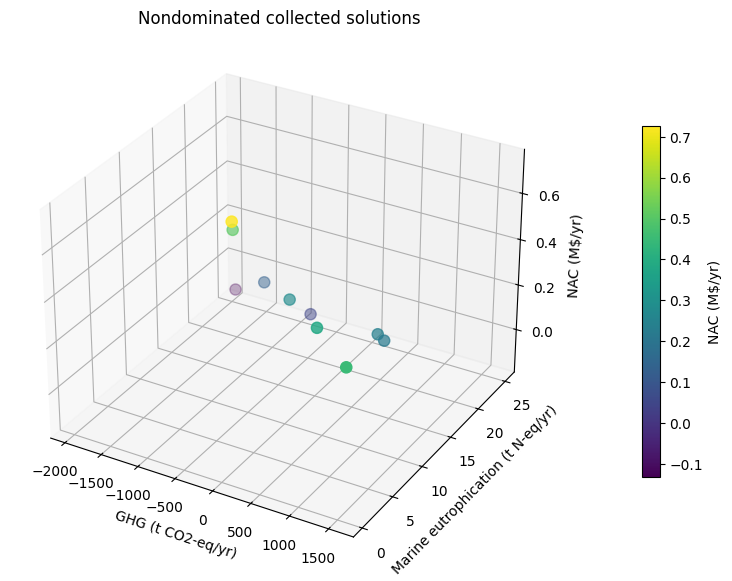

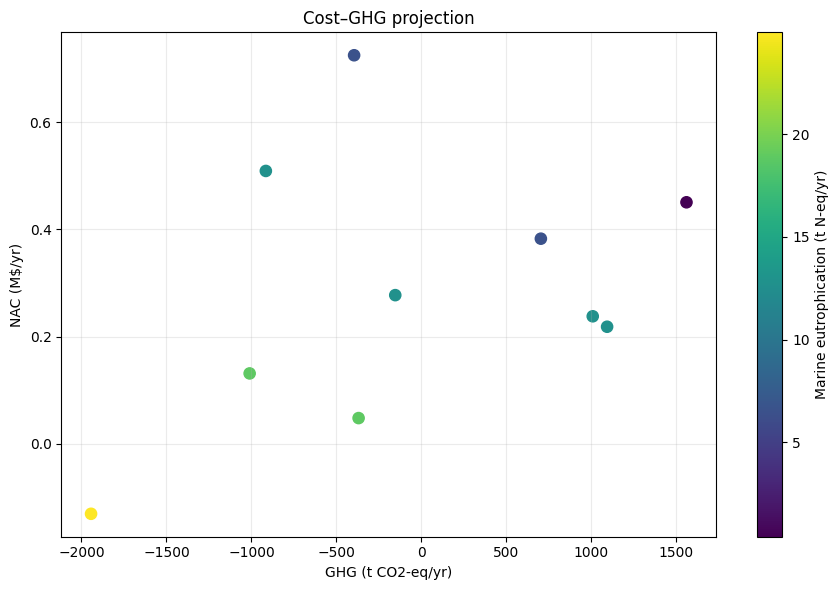

Nondominance is assessed against the collected solutions only.
The sampled points do not establish the complete Pareto frontier.


In [58]:
# CELL 52 — FILTER AND PLOT THE COLLECTED SOLUTIONS

# =====================================================
# COMBINE ANCHORS AND EPSILON-GRID RESULTS
# =====================================================

objective_columns = ["NAC_MUSD_yr", "GHG_tCO2e_yr", "EP_tN_eq_yr"]

anchor_candidates = anchor_table.copy()
anchor_candidates["Source"] = "Anchor"
anchor_candidates["Point_ID"] = "A_" + anchor_candidates["Objective_minimized"].astype(str)

grid_candidates = pareto_table.copy()
grid_candidates["Source"] = "Epsilon grid"
grid_candidates["Point_ID"] = "E_" + grid_candidates["Run"].astype(str)

candidate_table = pd.concat([anchor_candidates, grid_candidates], ignore_index=True)
candidate_table = candidate_table.loc[np.isfinite(candidate_table[objective_columns].to_numpy(dtype=float)).all(axis=1)].copy()

if candidate_table.empty:
    raise RuntimeError("No finite feasible results are available to filter.")

# =====================================================
# REMOVE NUMERICALLY DUPLICATE OBJECTIVE VECTORS
# =====================================================

candidate_table = candidate_table.sort_values("Globally_certified", ascending=False, kind="stable").reset_index(drop=True)
objective_values = candidate_table[objective_columns].to_numpy(dtype=float)
comparison_scales = np.maximum(1.0, np.max(np.abs(objective_values), axis=0))
normalized_values = objective_values / comparison_scales
comparison_tolerance = 1e-7
unique_indices = []

for row_index in range(len(candidate_table)):
    is_duplicate = any(np.all(np.abs(normalized_values[row_index] - normalized_values[kept_index]) <= comparison_tolerance) for kept_index in unique_indices)
    if not is_duplicate:
        unique_indices.append(row_index)

unique_table = candidate_table.iloc[unique_indices].reset_index(drop=True)
unique_values = unique_table[objective_columns].to_numpy(dtype=float) / comparison_scales

# =====================================================
# REMOVE POINTS DOMINATED BY OTHER COLLECTED POINTS
# ALL THREE OBJECTIVES ARE MINIMIZED
# =====================================================

nondominated_mask = np.ones(len(unique_table), dtype=bool)

for row_index in range(len(unique_table)):
    no_worse = np.all(unique_values <= unique_values[row_index] + comparison_tolerance, axis=1)
    strictly_better = np.any(unique_values < unique_values[row_index] - comparison_tolerance, axis=1)
    nondominated_mask[row_index] = not np.any(no_worse & strictly_better)

frontier_table = unique_table.loc[nondominated_mask].sort_values("NAC_MUSD_yr").reset_index(drop=True)

print(f"Collected solutions: {len(candidate_table)}")
print(f"Unique objective vectors: {len(unique_table)}")
print(f"Nondominated collected solutions: {len(frontier_table)}")

display(frontier_table[["Point_ID", "Source", "NAC_MUSD_yr", "GHG_tCO2e_yr", "EP_tN_eq_yr", "Globally_certified"]])

# =====================================================
# THREE-OBJECTIVE SCATTER PLOT
# =====================================================

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
points = ax.scatter(frontier_table["GHG_tCO2e_yr"], frontier_table["EP_tN_eq_yr"], frontier_table["NAC_MUSD_yr"], c=frontier_table["NAC_MUSD_yr"], cmap="viridis", s=65)
ax.set_xlabel("GHG (t CO2-eq/yr)")
ax.set_ylabel("Marine eutrophication (t N-eq/yr)")
ax.set_zlabel("NAC (M$/yr)")
ax.set_title("Nondominated collected solutions")
fig.colorbar(points, ax=ax, label="NAC (M$/yr)", shrink=0.65, pad=0.12)
plt.show()

# =====================================================
# TWO-OBJECTIVE PROJECTION
# COLOUR SHOWS THE THIRD OBJECTIVE
# =====================================================

fig, ax = plt.subplots(figsize=(9, 6))
points = ax.scatter(frontier_table["GHG_tCO2e_yr"], frontier_table["NAC_MUSD_yr"], c=frontier_table["EP_tN_eq_yr"], cmap="viridis", s=65)
ax.set_xlabel("GHG (t CO2-eq/yr)")
ax.set_ylabel("NAC (M$/yr)")
ax.set_title("Cost–GHG projection")
ax.grid(alpha=0.25)
fig.colorbar(points, ax=ax, label="Marine eutrophication (t N-eq/yr)")
plt.tight_layout()
plt.show()

print("Nondominance is assessed against the collected solutions only.")
print("The sampled points do not establish the complete Pareto frontier.")

In [59]:
# CELL 53 — TECHNOLOGY CONFIGURATIONS OF RETAINED SOLUTIONS

# =====================================================
# FORMAT SAVED ROUTE RECORDS
# =====================================================

def format_fractions(records):
    domain_column = records.columns[0]
    active = records.loc[records["level"] > 1e-6]
    return " / ".join(f"{row[domain_column]} {100.0 * row['level']:.2f}%" for _, row in active.iterrows()) if not active.empty else "Inactive"

def saved_stream_mass(records, stream, components):
    return float(records.loc[(records["j"] == str(stream)) & records["k"].isin(components), "level"].sum())

configuration_rows = []

# =====================================================
# READ EACH POINT'S SAVED SOLUTION
# =====================================================

for _, point in frontier_table.iterrows():
    point_id = point["Point_ID"]
    if point["Source"] == "Anchor":
        saved = anchor_solutions[point["Objective_minimized"]]
    else:
        saved = pareto_solutions[int(point["Run"])]
    selections = saved["Selections"].set_index("i")["level"]
    mechanical = " / ".join(technology for technology in ["SHR", "MCR"] if selections.get(technology, 0.0) > 0.5)
    biological = " / ".join(technology for technology in ["AER", "ENZ"] if selections.get(technology, 0.0) > 0.5)
    htl_active = saved_stream_mass(saved["Streams"], "19", ["WATER", "CBH", "PRT", "FAT", "OTH", "ASH", "FC", "ENZYME"]) > 1e-6
    upgrading_active = saved_stream_mass(saved["Streams"], "48", ["CH4", "CO2"]) > 1e-6
    stb_active = saved_stream_mass(saved["Streams"], "57", ["ELECTRICITY"]) > 1e-6
    configuration_rows.append({"Point_ID": point_id, "Mechanical": mechanical or "Bypass", "Biological": biological or "Bypass", "Conversion": format_fractions(saved["Conversion"]), "HTL_recovery": format_fractions(saved["Recovery"]) if htl_active else "Inactive", "Biogas_upgrading": format_fractions(saved["Upgrading"]) if upgrading_active else "Inactive", "STB": "Active" if stb_active else "Inactive", "NAC_MUSD_yr": point["NAC_MUSD_yr"], "GHG_tCO2e_yr": point["GHG_tCO2e_yr"], "EP_tN_eq_yr": point["EP_tN_eq_yr"], "Globally_certified": point["Globally_certified"]})

configuration_table = pd.DataFrame(configuration_rows)
display(configuration_table)

,Point_ID,Mechanical,Biological,Conversion,HTL_recovery,Biogas_upgrading,STB,NAC_MUSD_yr,GHG_tCO2e_yr,EP_tN_eq_yr,Globally_certified
0,A_NAC,Bypass,Bypass,Inactive,Inactive,Inactive,Inactive,-0.130954,-1943.449731,24.968585,True
1,E_2,SHR,AER,HTL 51.45% / WWT 48.55%,CEN 100.00%,Inactive,Inactive,0.047766,-369.768822,18.827387,True
2,E_17,SHR,Bypass,HTL 76.76% / CMP 23.24% / WWT 0.00%,CEN 100.00% / FLT 0.00%,Inactive,Inactive,0.131169,-1010.617805,18.827387,True
3,E_3,SHR,Bypass,CMP 7.95% / WWT 92.05%,Inactive,Inactive,Inactive,0.218339,1091.923307,12.681583,True
4,E_8,SHR,Bypass,HTL 3.49% / CMP 10.70% / WWT 85.81%,CEN 100.00%,Inactive,Inactive,0.237858,1007.404023,12.681583,True
5,E_13,SHR,Bypass,HTL 51.49% / CMP 48.51%,CEN 100.00%,Inactive,Inactive,0.277341,-154.160209,12.681583,True
6,E_4,SHR,Bypass,HTL 26.22% / CMP 73.78%,CEN 100.00%,Inactive,Inactive,0.382785,702.318421,6.535780,True
7,E_5,SHR,Bypass,HTL 0.96% / CMP 99.04%,CEN 100.00%,Inactive,Inactive,0.450727,1558.797050,0.389977,True
8,E_18,SHR,AER,HTL 32.05% / AND 65.74% / WWT 2.21%,CEN 100.00%,ABS 100.00%,Inactive,0.509258,-915.327757,12.681583,True
9,E_14,SHR,Bypass,AND 88.98% / CMP 11.02%,Inactive,ABS 100.00%,Inactive,0.725287,-396.197293,6.535780,True


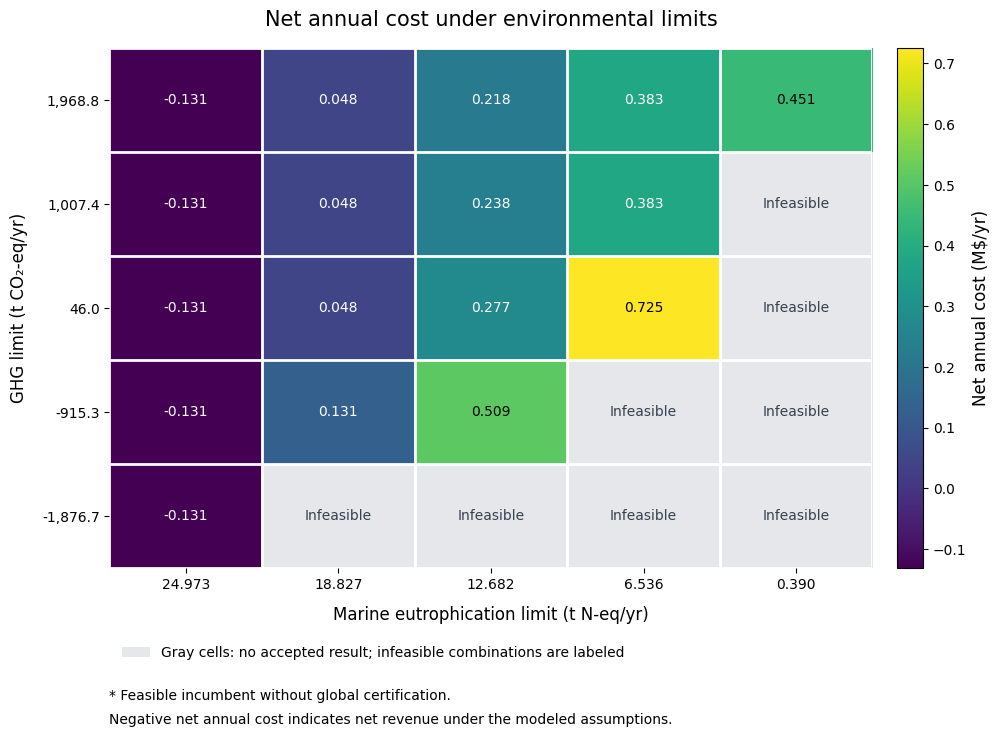

In [60]:
# CELL 54 — HEATMAP OF COST UNDER ENVIRONMENTAL LIMITS

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import Normalize

# =====================================================
# BUILD THE GRID FROM SAVED RESULTS
# =====================================================

if pareto_table.empty:
    raise RuntimeError("No accepted grid results are available. Run Cell 51 first.")

ghg_axis = np.sort(np.unique(ghg_grid))[::-1]
ep_axis = np.sort(np.unique(ep_grid))[::-1]

cost_grid = np.full((len(ghg_axis), len(ep_axis)), np.nan)
certified_grid = np.zeros(cost_grid.shape, dtype=bool)
status_grid = np.full(cost_grid.shape, "Not evaluated", dtype=object)

for _, row in pareto_log_table.iterrows():
    ghg_index = int(np.argmin(np.abs(ghg_axis - float(row["GHG_limit"]))))
    ep_index = int(np.argmin(np.abs(ep_axis - float(row["EP_limit"]))))
    status_grid[ghg_index, ep_index] = str(row["Model_status"])

for _, row in pareto_table.iterrows():
    ghg_index = int(np.argmin(np.abs(ghg_axis - float(row["GHG_limit"]))))
    ep_index = int(np.argmin(np.abs(ep_axis - float(row["EP_limit"]))))
    cost_grid[ghg_index, ep_index] = float(row["NAC_MUSD_yr"])
    certified_grid[ghg_index, ep_index] = bool(row["Globally_certified"])

# =====================================================
# COLOUR SCALE
# =====================================================

masked_costs = np.ma.masked_invalid(cost_grid)
colour_map = plt.get_cmap("viridis").copy()
colour_map.set_bad("#E5E7EB")

cost_min = float(np.nanmin(cost_grid))
cost_max = float(np.nanmax(cost_grid))
colour_scale = Normalize(vmin=cost_min, vmax=cost_max if cost_max > cost_min else cost_min + 1e-6)

# =====================================================
# DRAW THE HEATMAP
# =====================================================

fig, ax = plt.subplots(figsize=(11, 8))
fig.subplots_adjust(left=0.13, right=0.88, top=0.90, bottom=0.25)

heatmap = ax.imshow(masked_costs, cmap=colour_map, norm=colour_scale, aspect="auto", interpolation="nearest")

ax.set_xticks(np.arange(len(ep_axis)))
ax.set_yticks(np.arange(len(ghg_axis)))
ax.set_xticklabels([f"{value:,.3f}" for value in ep_axis], fontsize=10)
ax.set_yticklabels([f"{value:,.1f}" for value in ghg_axis], fontsize=10)

ax.set_xlabel("Marine eutrophication limit (t N-eq/yr)", fontsize=12, labelpad=10)
ax.set_ylabel("GHG limit (t CO₂-eq/yr)", fontsize=12, labelpad=10)
ax.set_title("Net annual cost under environmental limits", fontsize=15, pad=16)

# =====================================================
# LABEL EACH CELL
# =====================================================

for ghg_index in range(len(ghg_axis)):
    for ep_index in range(len(ep_axis)):

        value = cost_grid[ghg_index, ep_index]

        if np.isfinite(value):
            marker = "" if certified_grid[ghg_index, ep_index] else "*"
            label = f"{value:.3f}{marker}"
            rgba = colour_map(colour_scale(value))
            brightness = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            text_colour = "black" if brightness > 0.55 else "white"
        else:
            status = status_grid[ghg_index, ep_index]
            label = "Infeasible" if "Infeasible" in status else "No accepted\nresult"
            text_colour = "#374151"

        ax.text(ep_index, ghg_index, label, ha="center", va="center", color=text_colour, fontsize=10)

# =====================================================
# CELL BORDERS AND COLOUR BAR
# =====================================================

ax.set_xticks(np.arange(-0.5, len(ep_axis), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(ghg_axis), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

for spine in ax.spines.values():
    spine.set_visible(False)

colour_bar = fig.colorbar(heatmap, ax=ax, pad=0.03, fraction=0.045)
colour_bar.set_label("Net annual cost (M$/yr)", fontsize=12)
colour_bar.ax.tick_params(labelsize=10)

# =====================================================
# LEGEND AND FOOTNOTES
# =====================================================

legend_handles = [Patch(facecolor="#E5E7EB", label="Gray cells: no accepted result; infeasible combinations are labeled")]
fig.legend(handles=legend_handles, loc="lower left", bbox_to_anchor=(0.13, 0.12), frameon=False, fontsize=10)

fig.text(0.13, 0.085, "* Feasible incumbent without global certification.", ha="left", fontsize=10)
fig.text(0.13, 0.055, "Negative net annual cost indicates net revenue under the modeled assumptions.", ha="left", fontsize=10)

plt.show()

In [61]:
# CELL 55 — CONVERSION MIX ACROSS COLLECTED TRADE-OFF POINTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# ORDER POINTS BY DECREASING MARINE EUTROPHICATION
# =====================================================

if frontier_table.empty:
    raise RuntimeError("Run Cell 52 before creating this chart.")

plot_points = frontier_table.sort_values(["EP_tN_eq_yr", "GHG_tCO2e_yr"], ascending=[False, True]).reset_index(drop=True)

technologies = ["HTL", "AND", "CMP", "WWT", "SLF", "INC"]
technology_colours = {"HTL": "#0072B2", "AND": "#009E73", "CMP": "#E69F00", "WWT": "#CC79A7", "SLF": "#999999", "INC": "#D55E00"}

conversion_rows = []

# =====================================================
# READ VALIDATED CONVERSION SNAPSHOTS
# =====================================================

for _, point in plot_points.iterrows():

    if point["Source"] == "Anchor":
        saved = anchor_solutions[point["Objective_minimized"]]
    else:
        saved = pareto_solutions[int(point["Run"])]

    fractions = saved["Conversion"].set_index("iConv")["level"]
    values = np.array([float(fractions.get(technology, 0.0)) for technology in technologies])

    if not np.isfinite(values).all() or np.any(values < -1e-5) or np.any(values > 1.0 + 1e-5) or abs(values.sum() - 1.0) > 1e-5:
        raise RuntimeError(f"{point['Point_ID']}: invalid conversion fractions.")

    values = np.clip(values, 0.0, 1.0)
    conversion_rows.append({technology: 100.0 * value for technology, value in zip(technologies, values)})

conversion_mix = pd.DataFrame(conversion_rows, index=plot_points["Point_ID"].tolist())

# =====================================================
# DRAW STACKED BARS
# =====================================================

fig, ax = plt.subplots(figsize=(12, 8))
fig.subplots_adjust(left=0.09, right=0.98, top=0.90, bottom=0.36)

positions = np.arange(len(plot_points))
bottom = np.zeros(len(plot_points))

for technology in technologies:

    percentages = conversion_mix[technology].to_numpy(dtype=float)

    if not np.any(percentages > 1e-6):
        continue

    ax.bar(positions, percentages, bottom=bottom, width=0.72, color=technology_colours[technology], label=technology, edgecolor="white", linewidth=0.5)

    for position, percentage, base in zip(positions, percentages, bottom):
        if percentage >= 5.0:
            text_colour = "black" if technology in ["CMP", "SLF"] else "white"
            ax.text(position, base + percentage / 2.0, f"{percentage:.1f}%", ha="center", va="center", fontsize=9, color=text_colour)

    bottom += percentages

# =====================================================
# AXES AND LABELS
# =====================================================

tick_labels = []

for _, point in plot_points.iterrows():
    marker = "" if bool(point["Globally_certified"]) else "*"
    tick_labels.append(f"{point['Point_ID']}{marker}\n{point['EP_tN_eq_yr']:.3f}")

ax.set_xticks(positions)
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylim(0.0, 100.0)
ax.set_yticks(np.arange(0, 101, 20))

ax.set_ylabel("Conversion allocation (%)", fontsize=12)
ax.set_xlabel("Collected point ID and marine EP (t N-eq/yr)\nOrdered from higher to lower EP →", fontsize=11, labelpad=12)
ax.set_title("Conversion mix across collected trade-off points", fontsize=15, pad=18)

ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =====================================================
# LEGEND BELOW THE CHART
# =====================================================

legend_handles, legend_labels = ax.get_legend_handles_labels()
fig.legend(handles=legend_handles, labels=legend_labels, title="Conversion technology", loc="upper center", bbox_to_anchor=(0.53, 0.23), ncol=6, frameon=False, fontsize=10, title_fontsize=10)

# =====================================================
# FOOTNOTES
# =====================================================

fig.text(0.09, 0.12, "* Feasible incumbent without global certification.", fontsize=10)
fig.text(0.09, 0.08, "Shares below 5% remain in the bars but are not labeled. AND denotes anaerobic digestion.", fontsize=10)
fig.text(0.09, 0.04, "Points are ordered by EP; their GHG values are not necessarily decreasing.", fontsize=10)

plt.show()

# =====================================================
# DISPLAY CONVERSION PERCENTAGES
# =====================================================

display(conversion_mix.round(4).rename_axis("Point_ID"))

RuntimeError: A_NAC: invalid conversion fractions.